In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import sys
from scipy.sparse import linalg
from pathlib import Path
import itertools
import sympy as sp
import math  
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 

torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)
ZERO = torch.tensor([0.]).to(device)


In [2]:
def plot_condition_numbers(actual_neuron_arr, condition_number_arr, d, relu_k):
    # make sure we use only positive entries
    x = np.array(actual_neuron_arr)
    y = np.array(condition_number_arr)
    mask = (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    # fit line in log-log scale: log(y) = m*log(x) + b
    m, b = np.polyfit(np.log10(x), np.log10(y), 1)

    # best-fit curve
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = 10**(m * np.log10(x_fit) + b)

    # plot data and fit
    plt.figure(dpi=400)
    plt.plot(x, y, '.-', label=f"ReLU$^{relu_k}$")
    plt.plot(x_fit, y_fit, '--', label=f"fit (slope={m:.1f})")

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Number of neurons $n$")
    plt.ylabel("Condition number")
    plt.title(f"d = {d}, ReLU$^{relu_k}$, condition number of the mass matrix")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

def plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title): 
    optimal_rate = 1/2 + (2 * relu_k +1)/(2*d)
    ref = mean_err_l2_arr[0] *actual_neuron_arr[0]**optimal_rate * (actual_neuron_arr)**(-optimal_rate)
    plt.figure(dpi=400)
    plt.plot(actual_neuron_arr,ref,'-.',label = 'optimal slope: -{:.2f}'.format(optimal_rate))
    plt.plot(actual_neuron_arr, mean_err_l2_arr, '.-', label = 'ReLU$^{}$'.format(relu_k), linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show() 

## condition number 

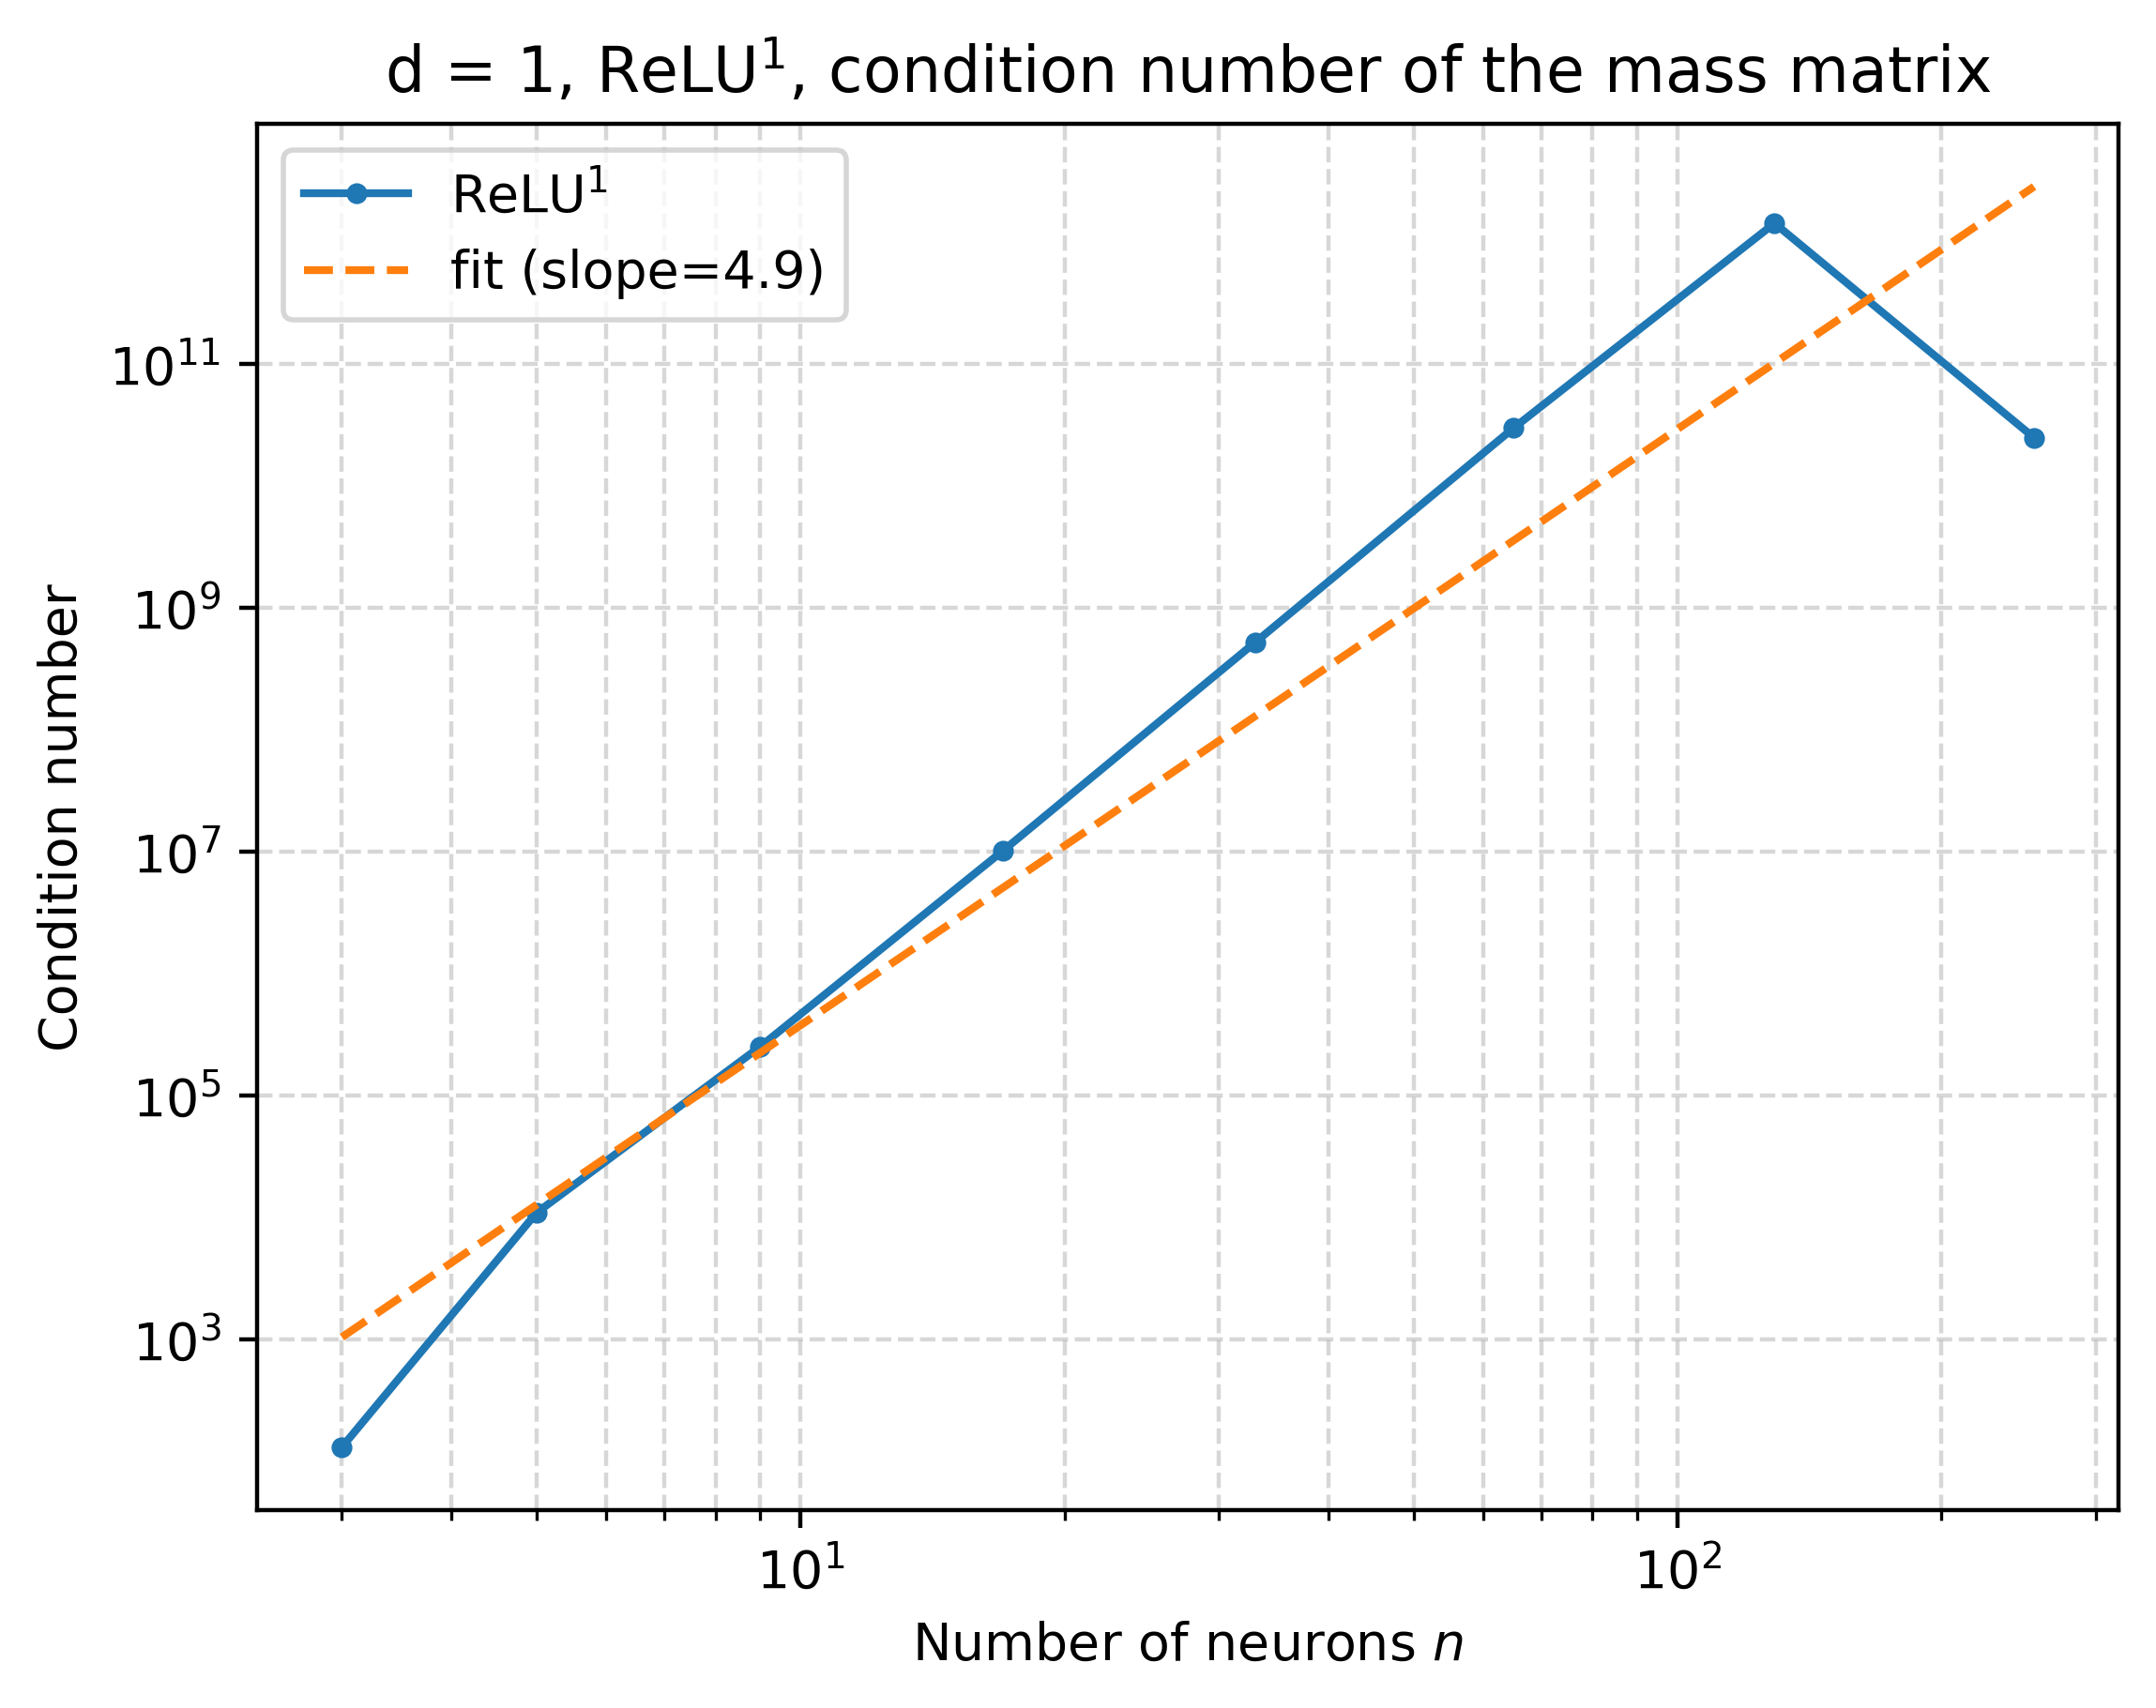

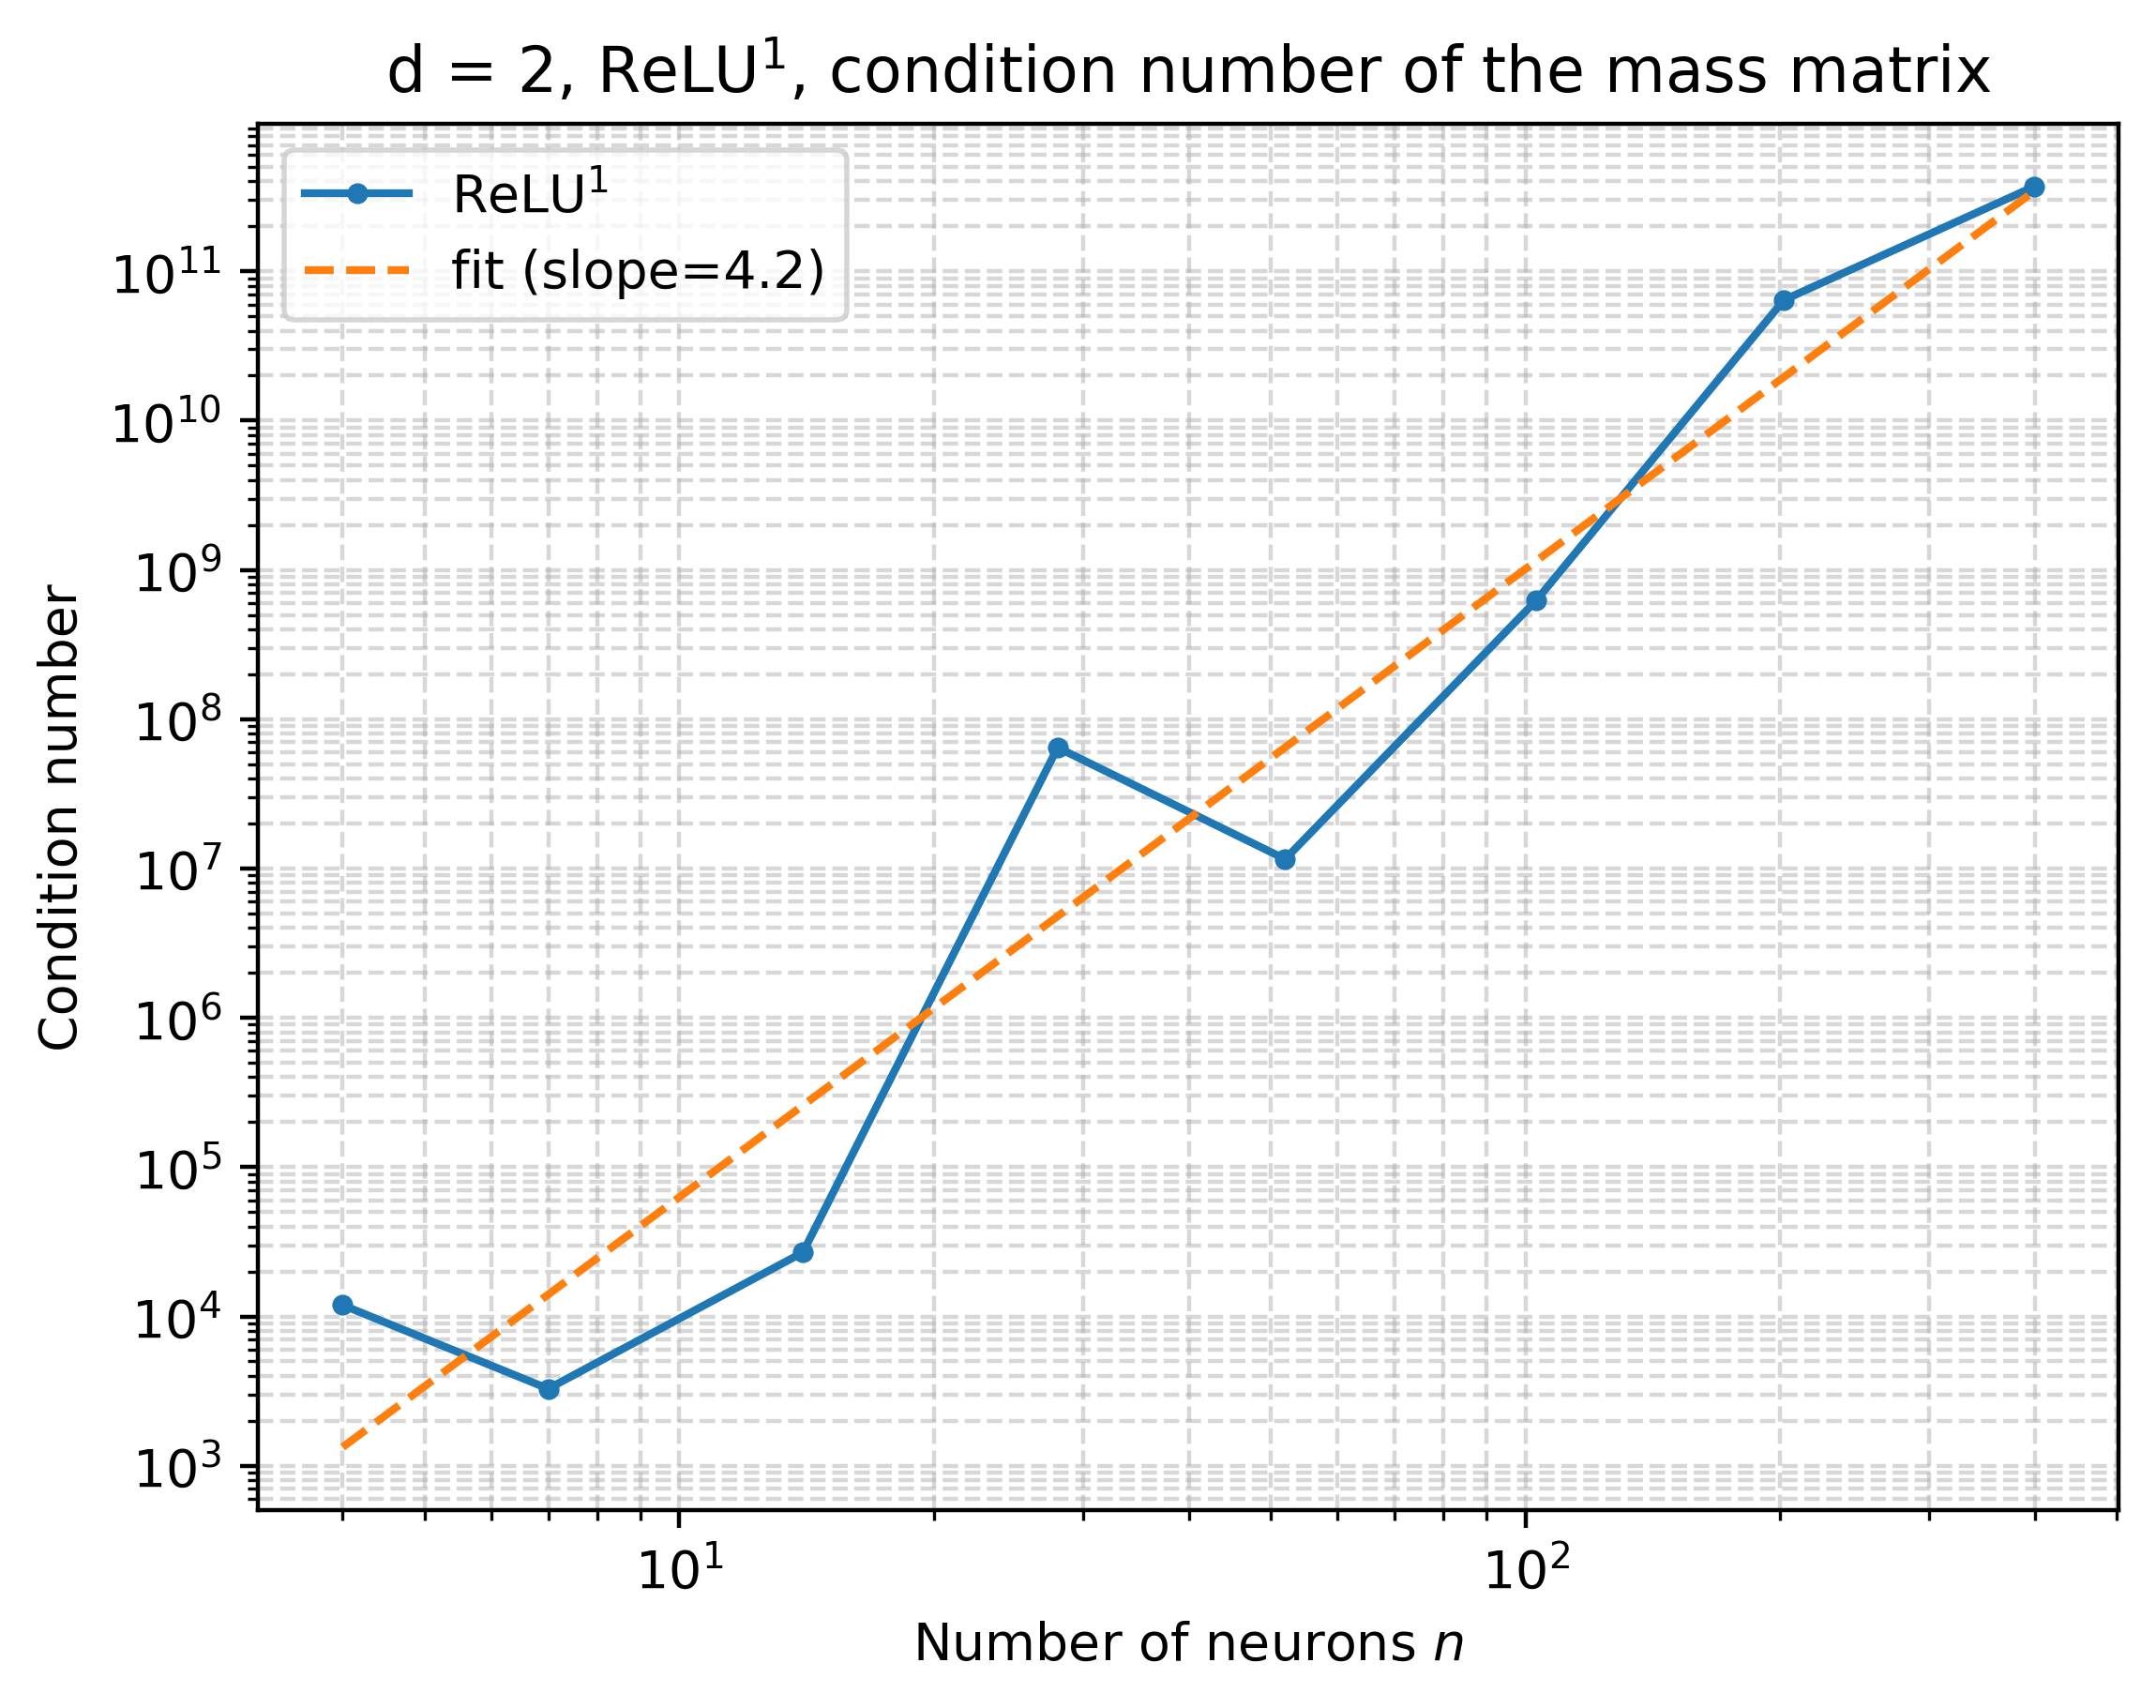

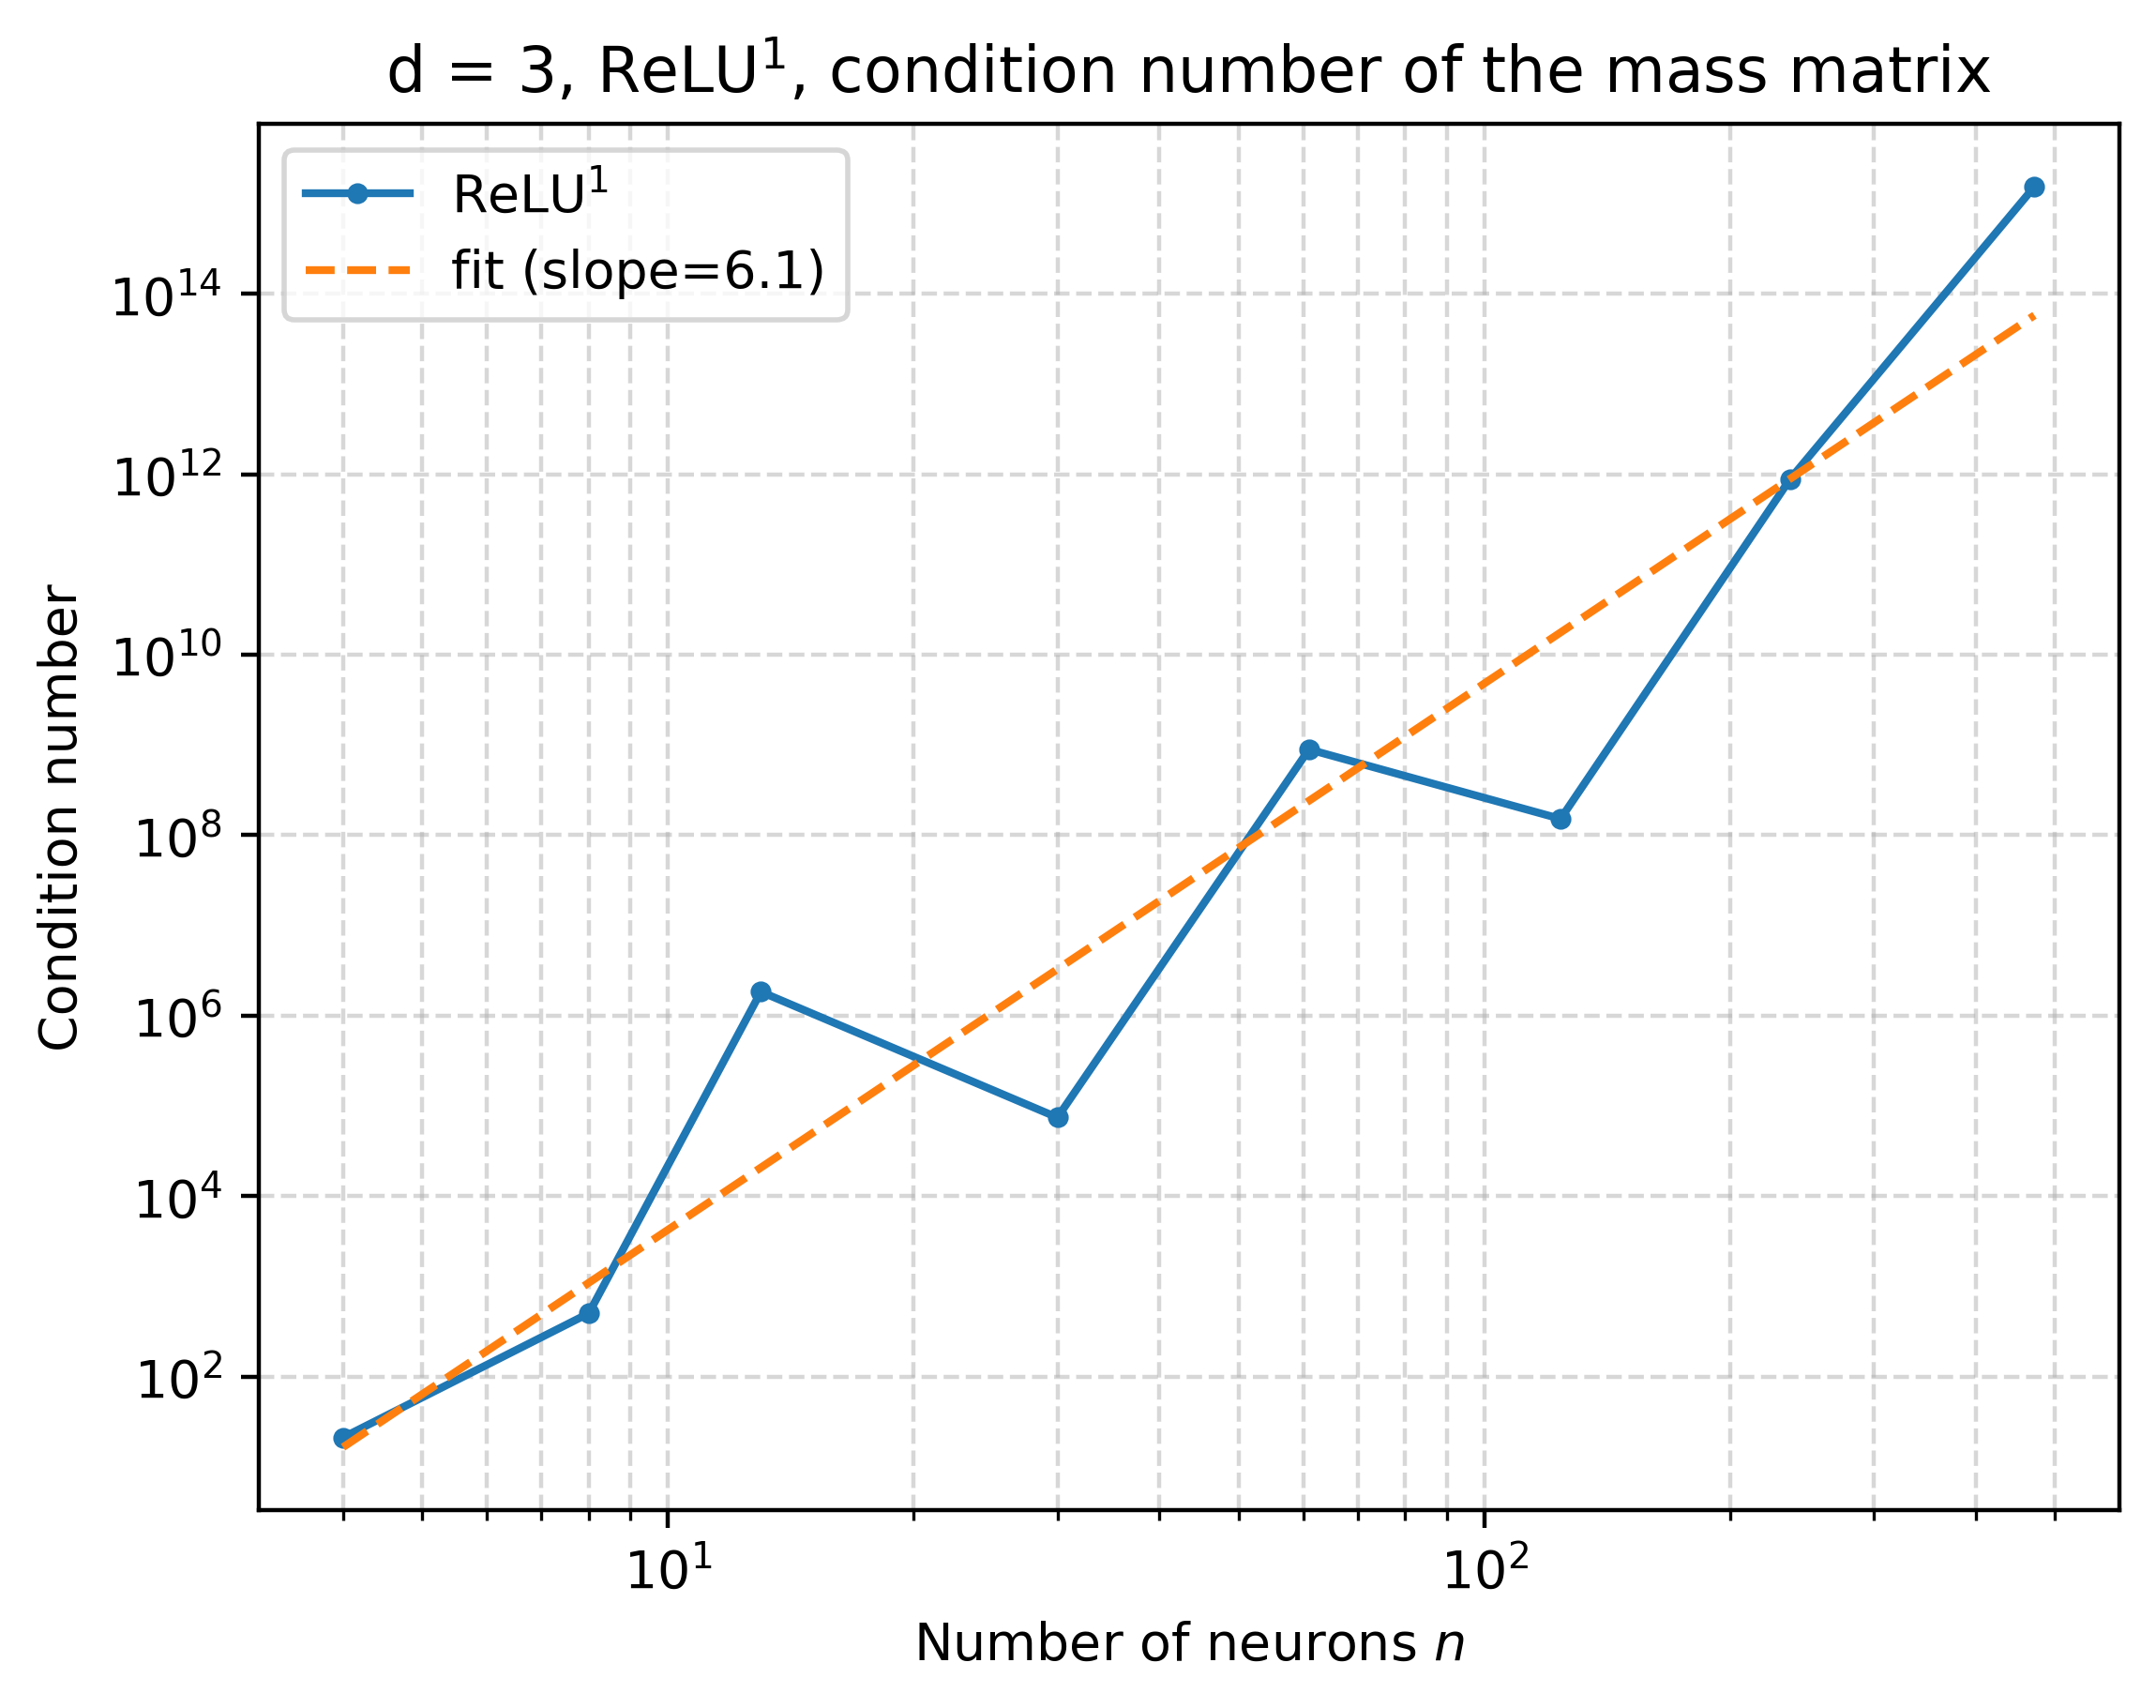

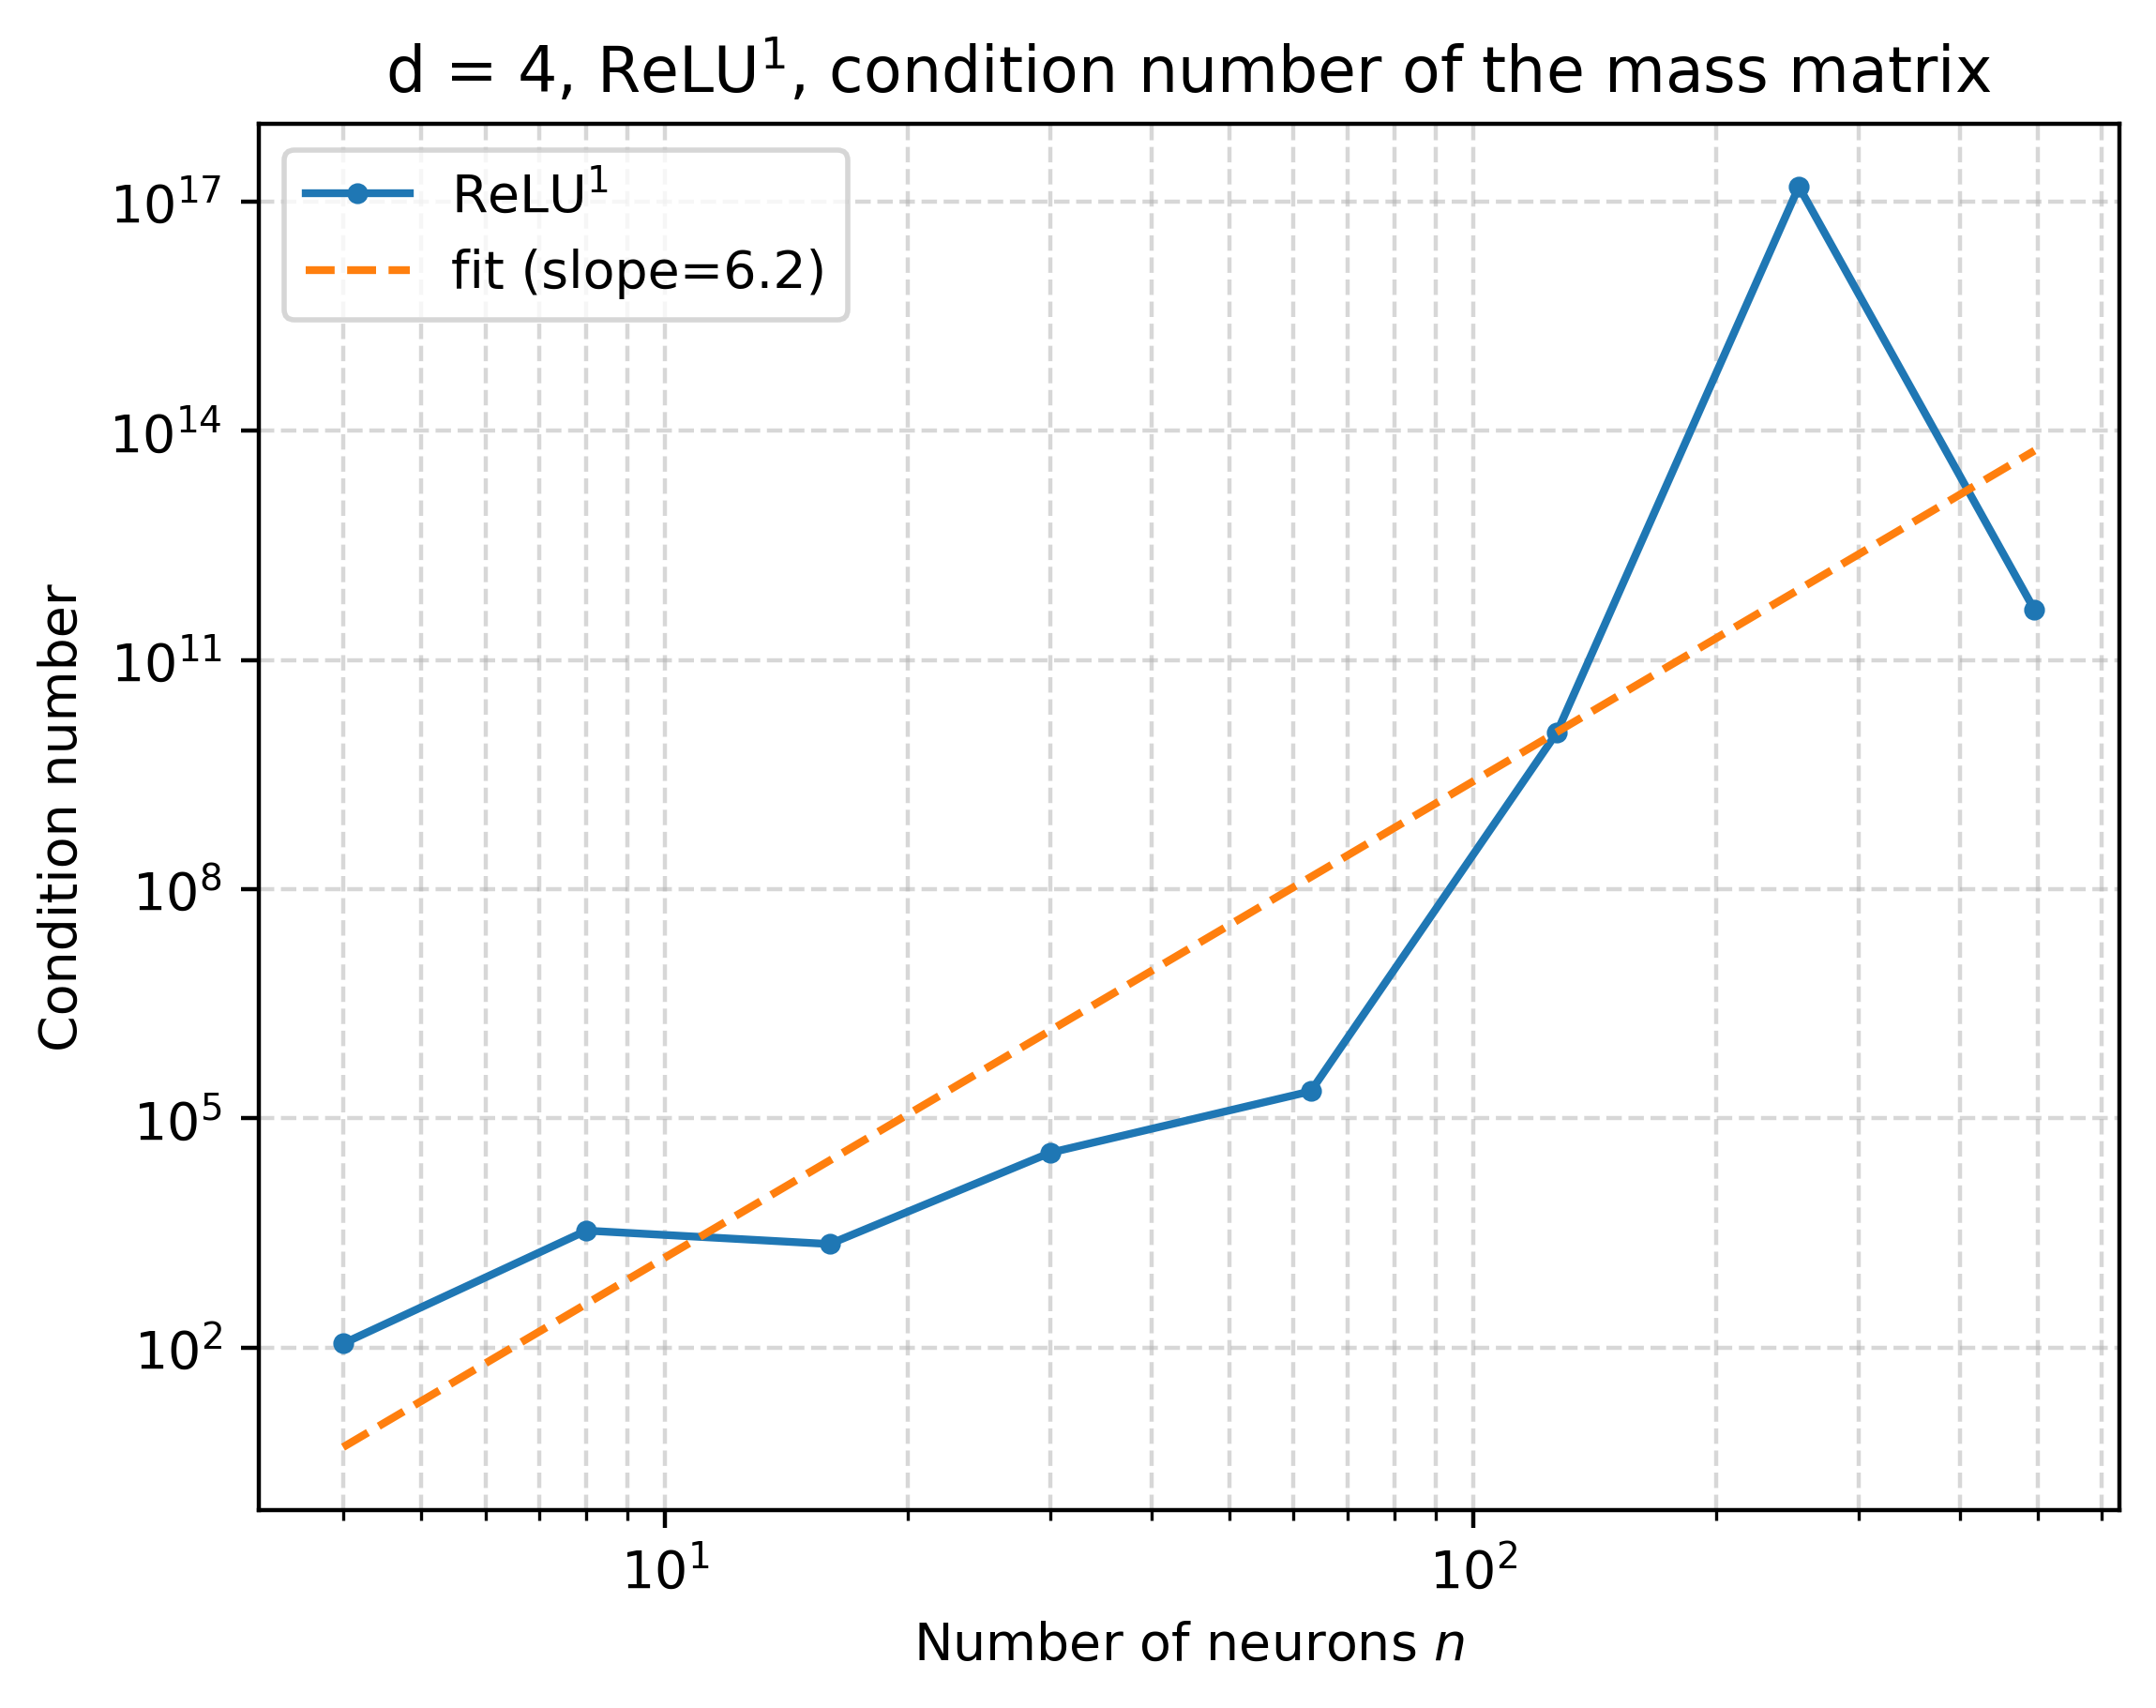

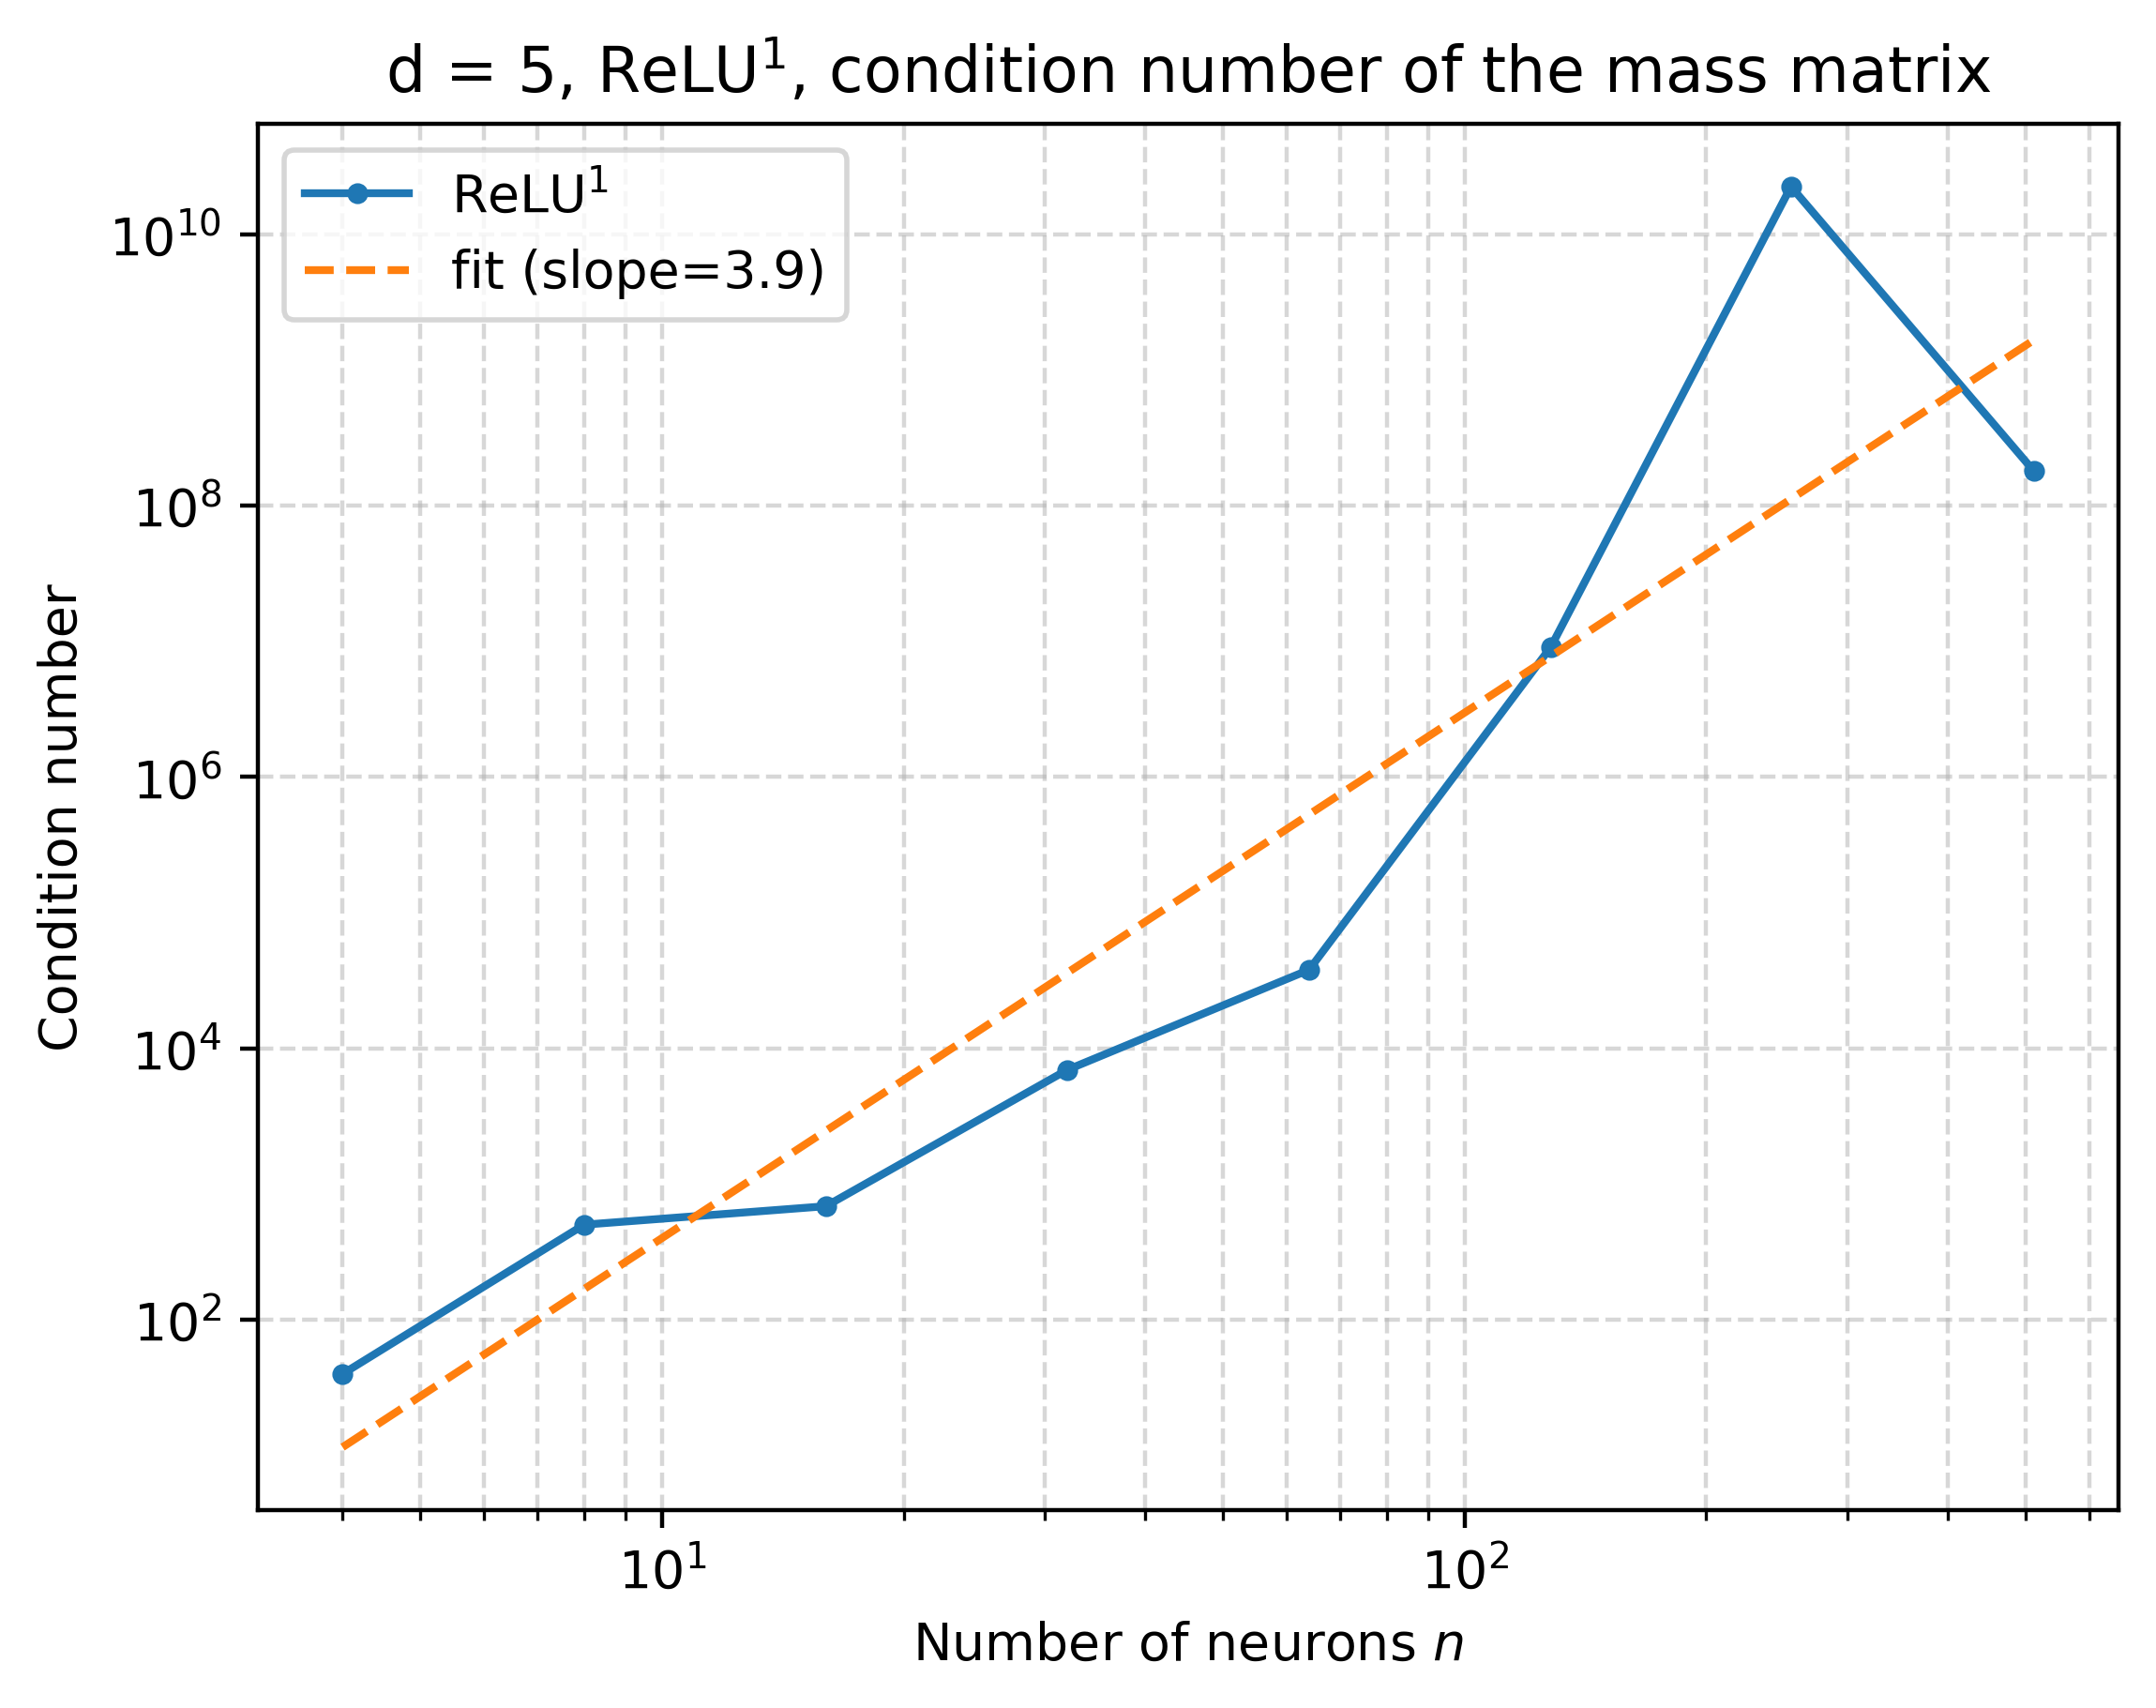

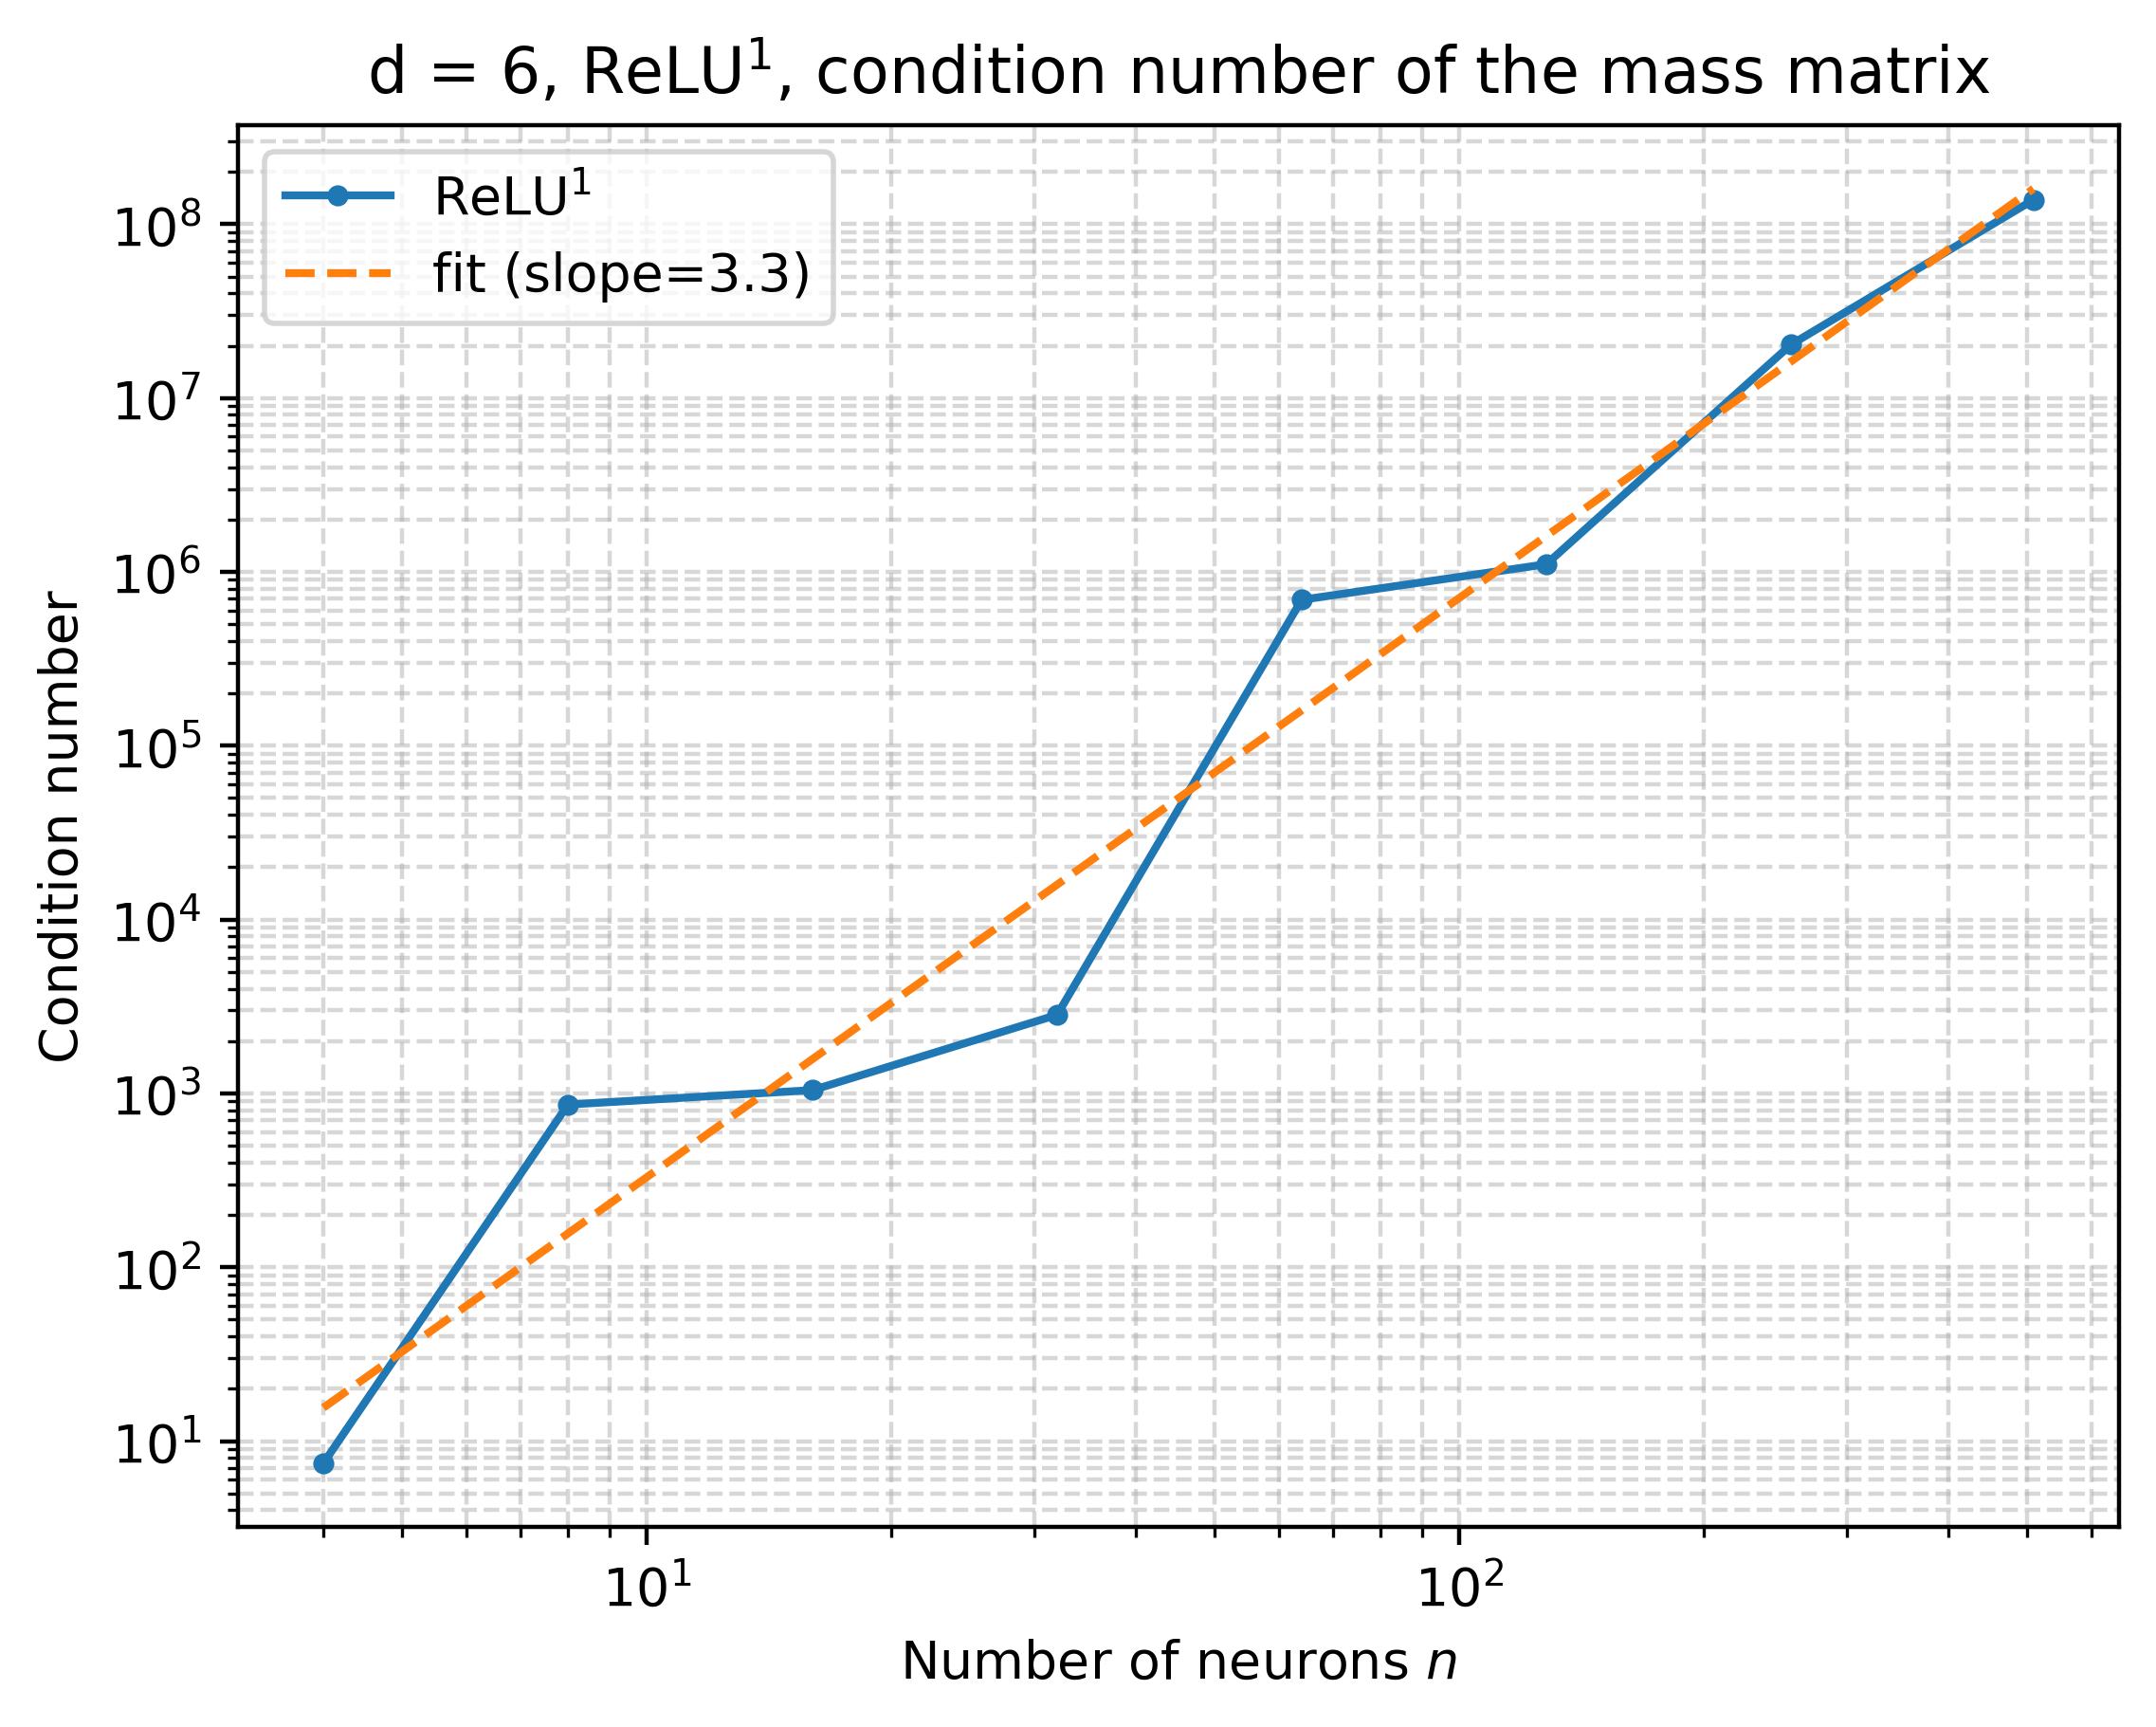

In [12]:

# load the saved data
for d in range(1,7): 
    relu_k = 1

    folder = './'
    data = np.load(f'{folder}L2minimization-condition-{d}d-relu{relu_k}.npz')
    
    # access arrays by their keys
    actual_neuron_arr = data['actual_neuron_arr']
    condition_number_arr = data['condition_number_arr']
    
    # (optional) close the file handle
    data.close()
    
    plot_condition_numbers(actual_neuron_arr, condition_number_arr, d, relu_k)


## L2 minimization  error plot 

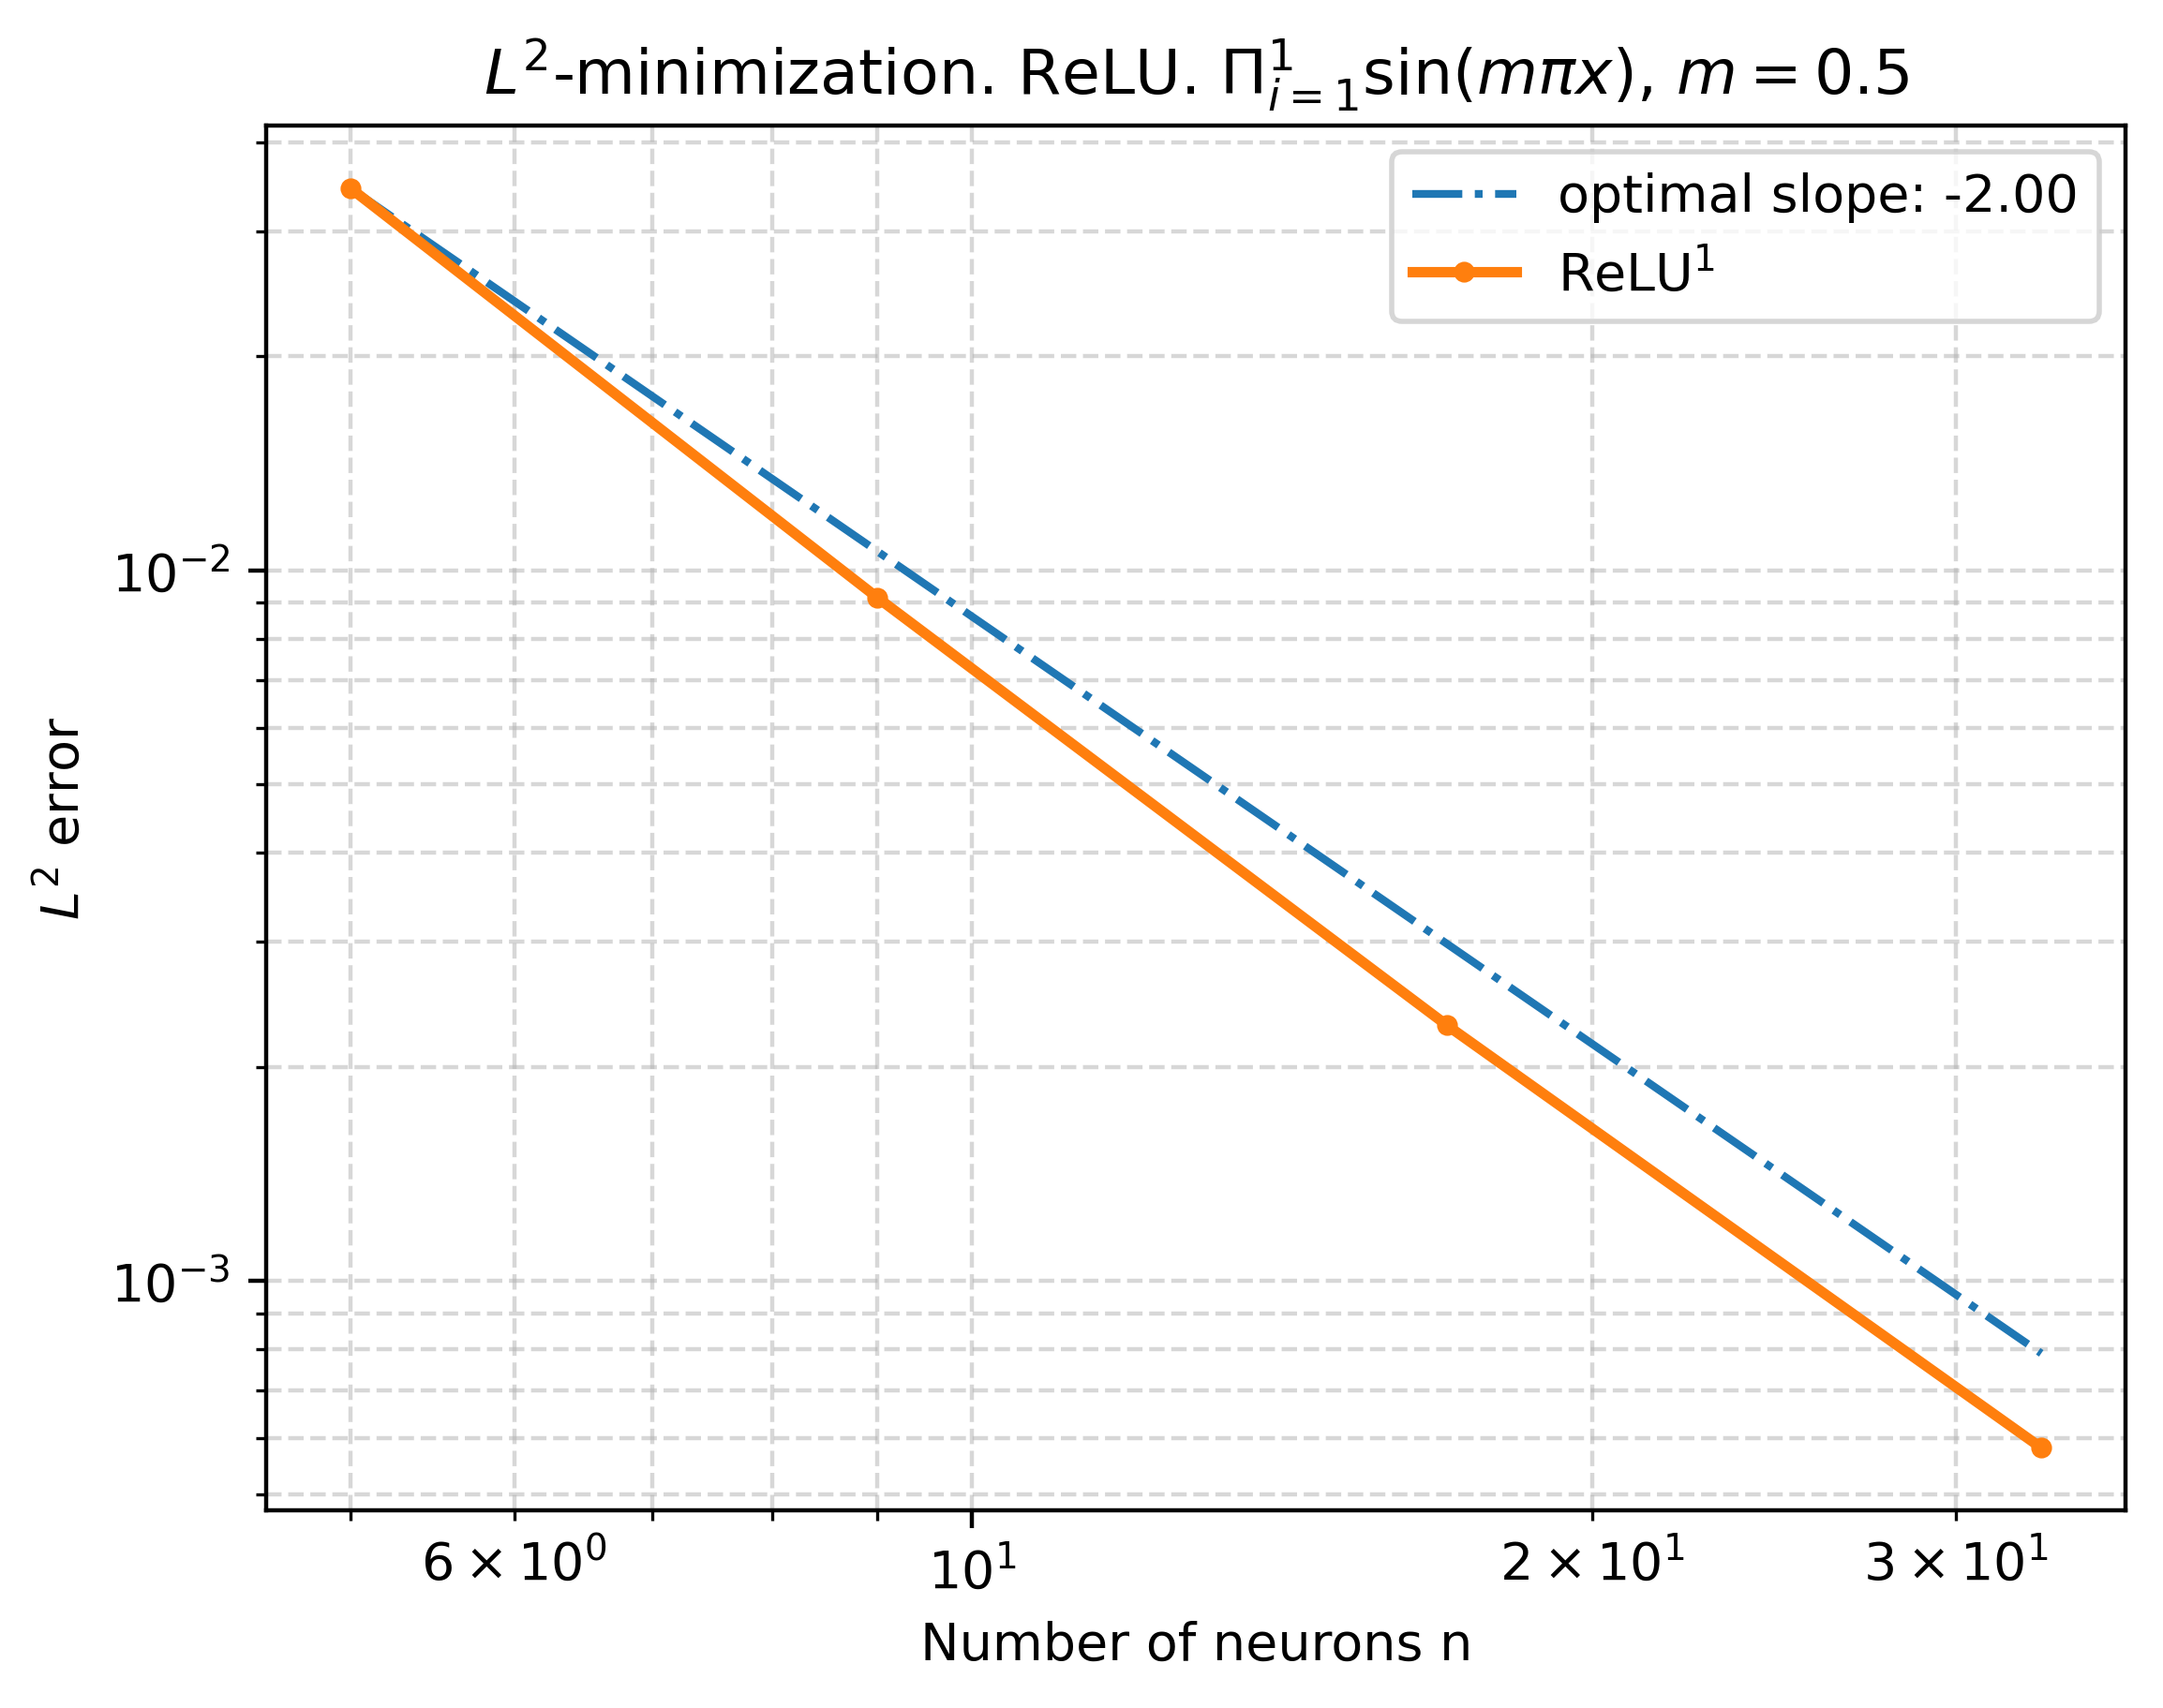

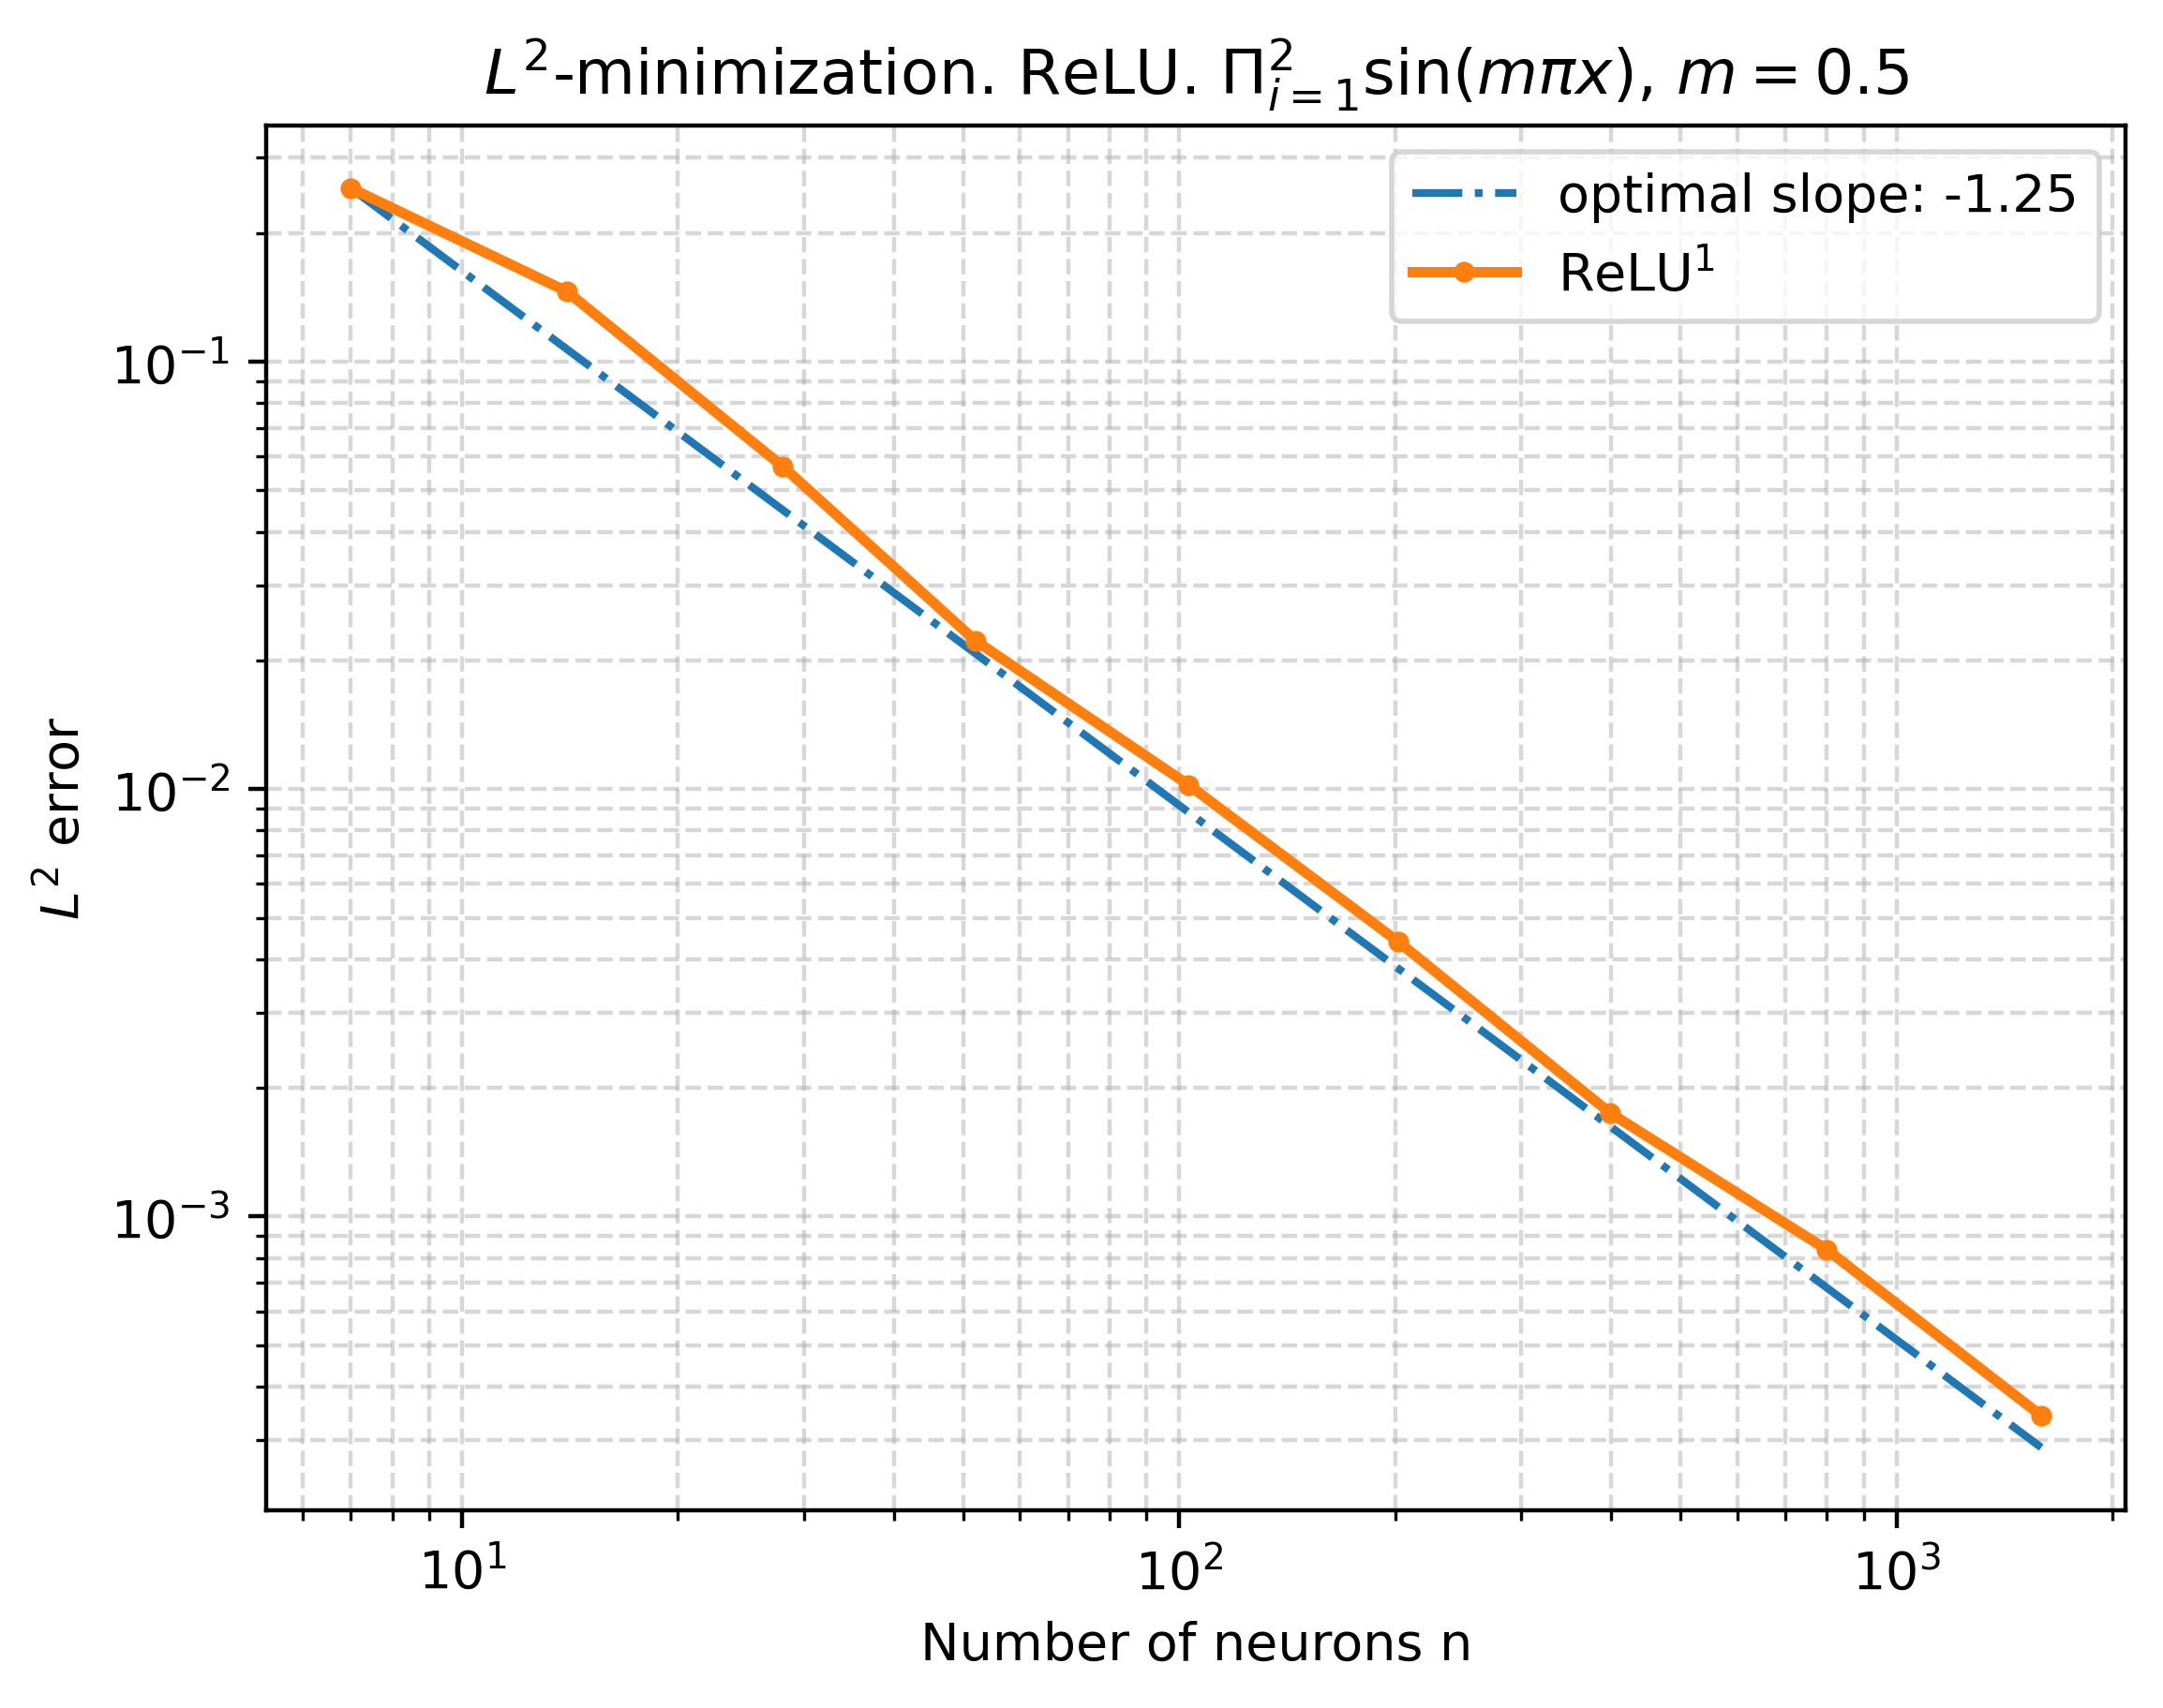

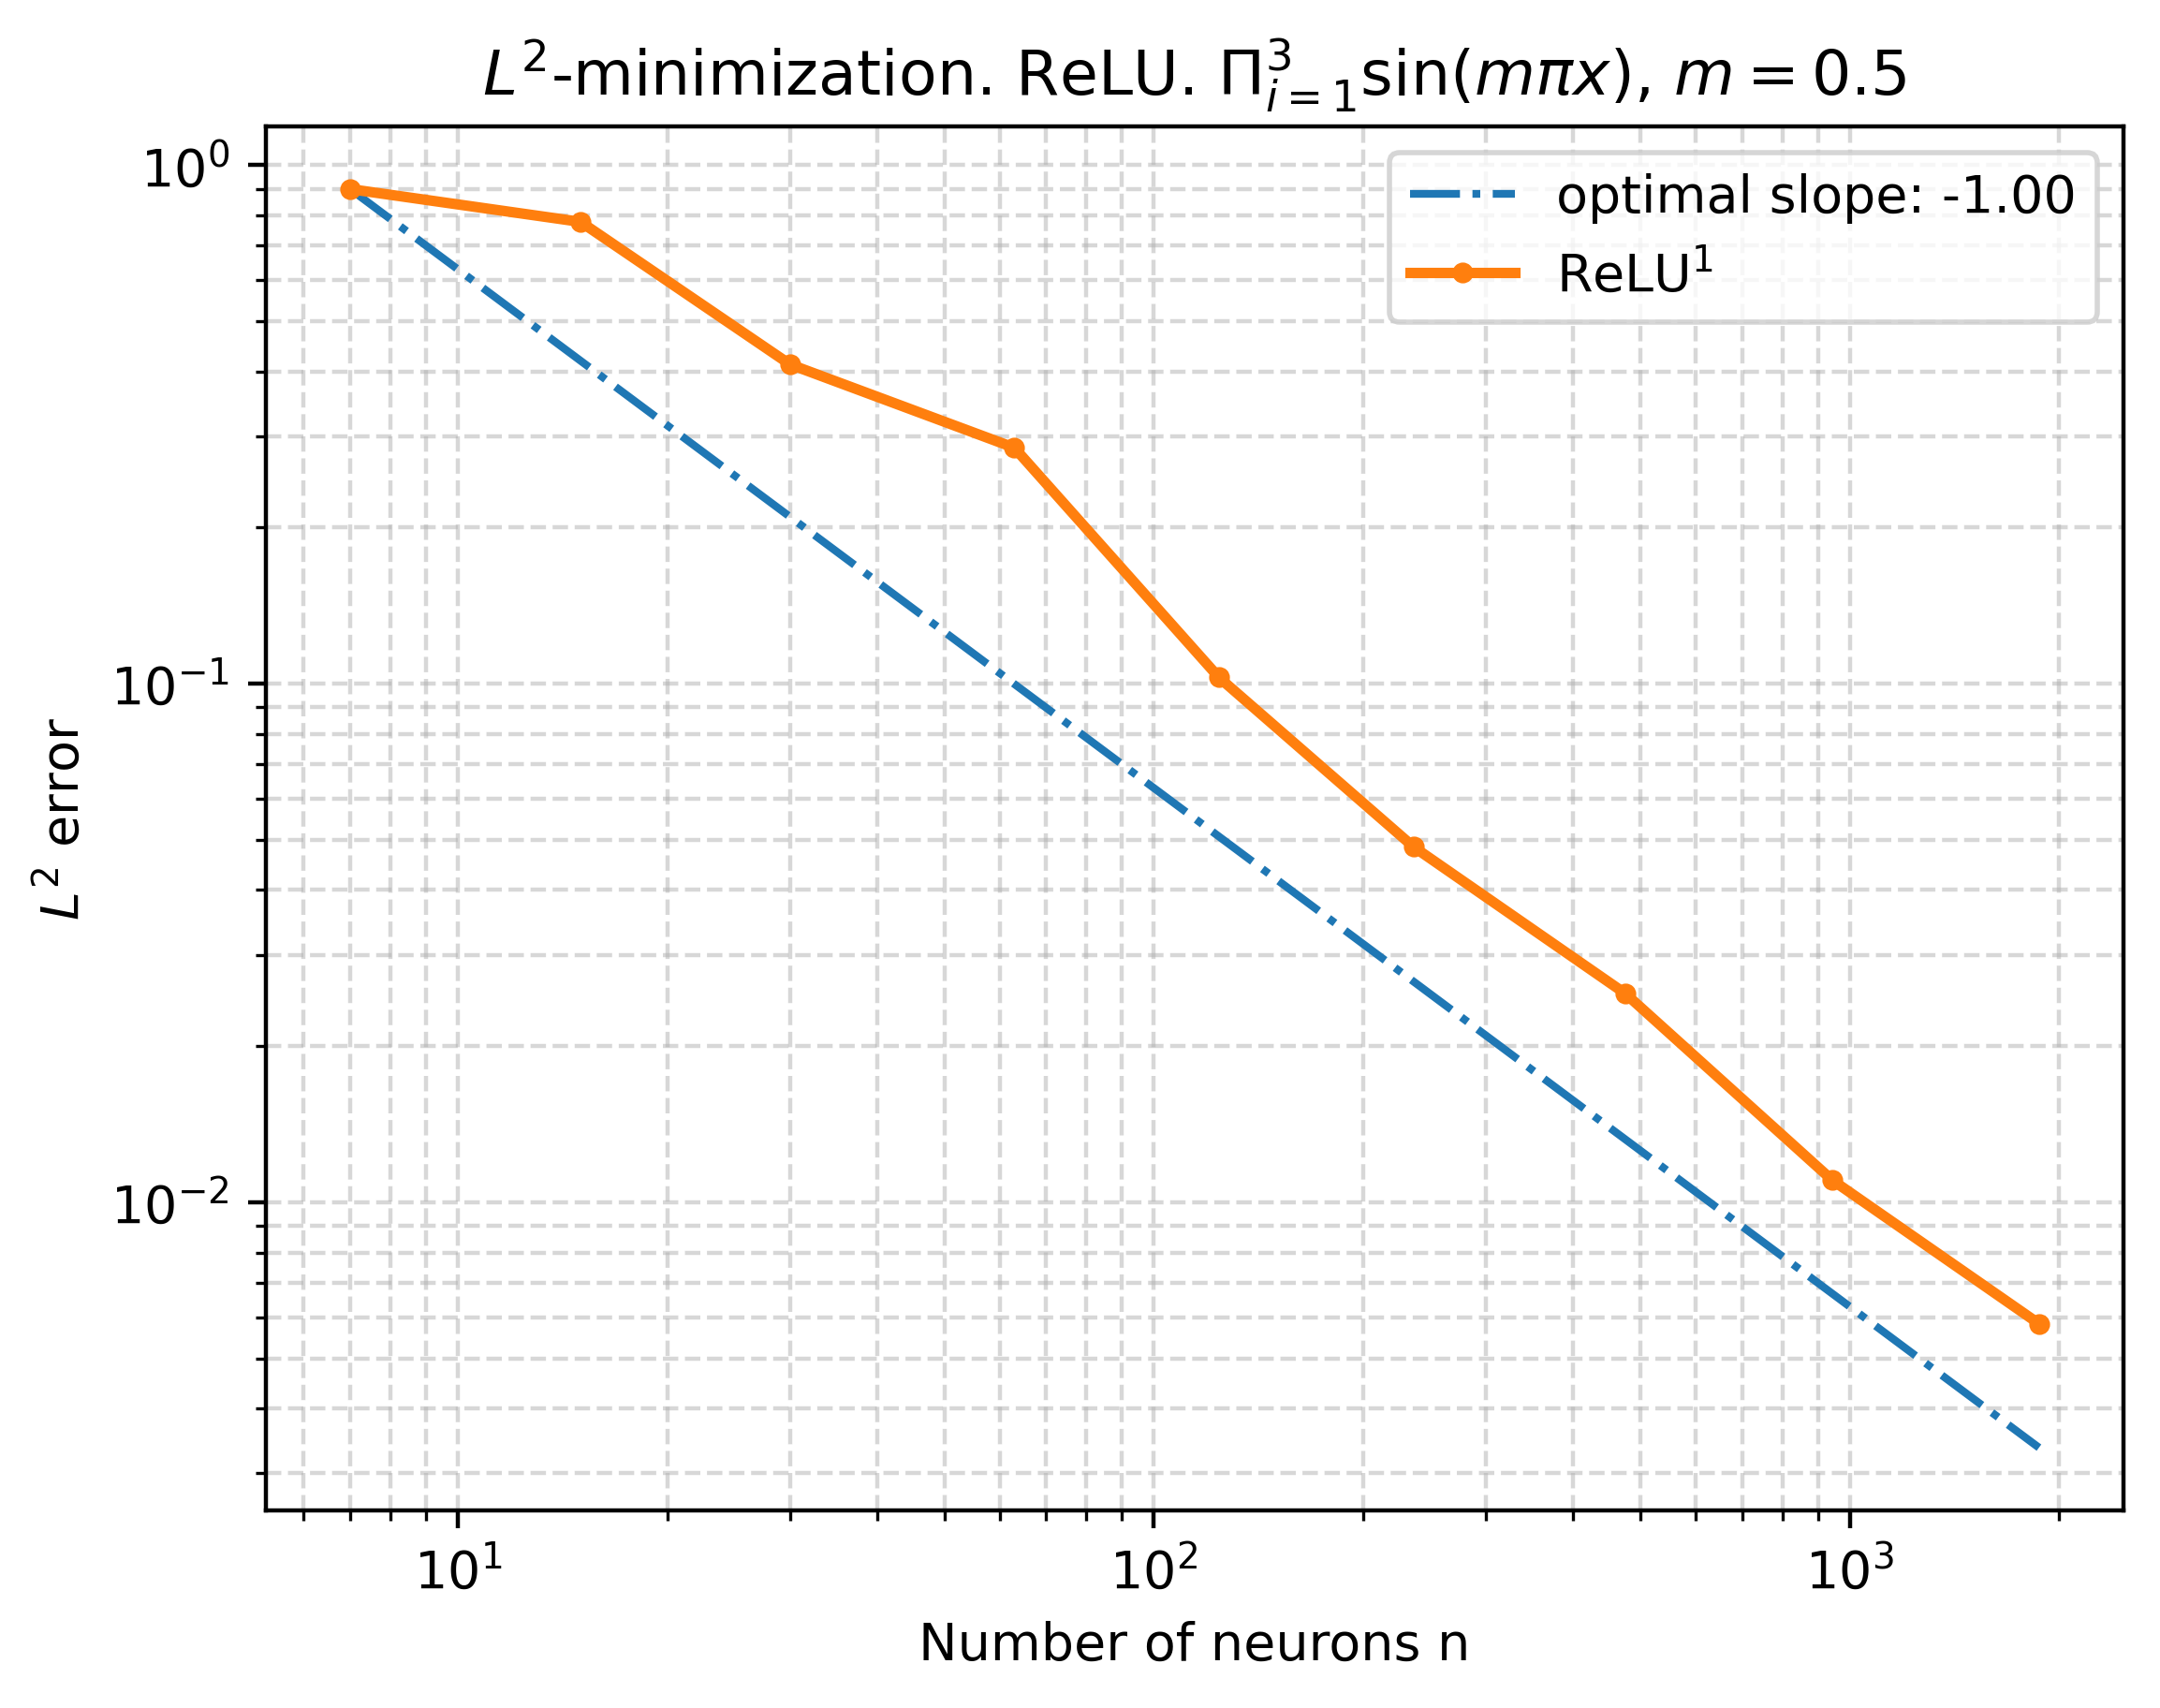

In [3]:
m = 1/2 
for d in range(1,4): 
    relu_k = 1

    folder = './'
    data = np.load(f'{folder}L2minimization-{d}d-relu{relu_k}.npz')

    # access arrays by their keys
    actual_neuron_arr = data['actual_neuron_arr']
    mean_err_l2_arr_2 = data['mean_err_l2_arr_2']

    if relu_k == 1:
        title =f"$L^2$-minimization. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    else:
        title = f"$L^2$-minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    
    plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)

In [4]:
def plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title, scale = 1): 
    optimal_rate = 1/2 + (2 * relu_k +1)/(2*d)
    ref = scale * mean_err_l2_arr[0] *actual_neuron_arr[0]**optimal_rate * (actual_neuron_arr)**(-optimal_rate)
    plt.figure(dpi=400)
    plt.plot(actual_neuron_arr,ref,'-.',label = 'optimal slope: -{:.2f}'.format(optimal_rate))
    plt.plot(actual_neuron_arr, mean_err_l2_arr, '.-', label = 'ReLU$^{}$'.format(relu_k), linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show() 

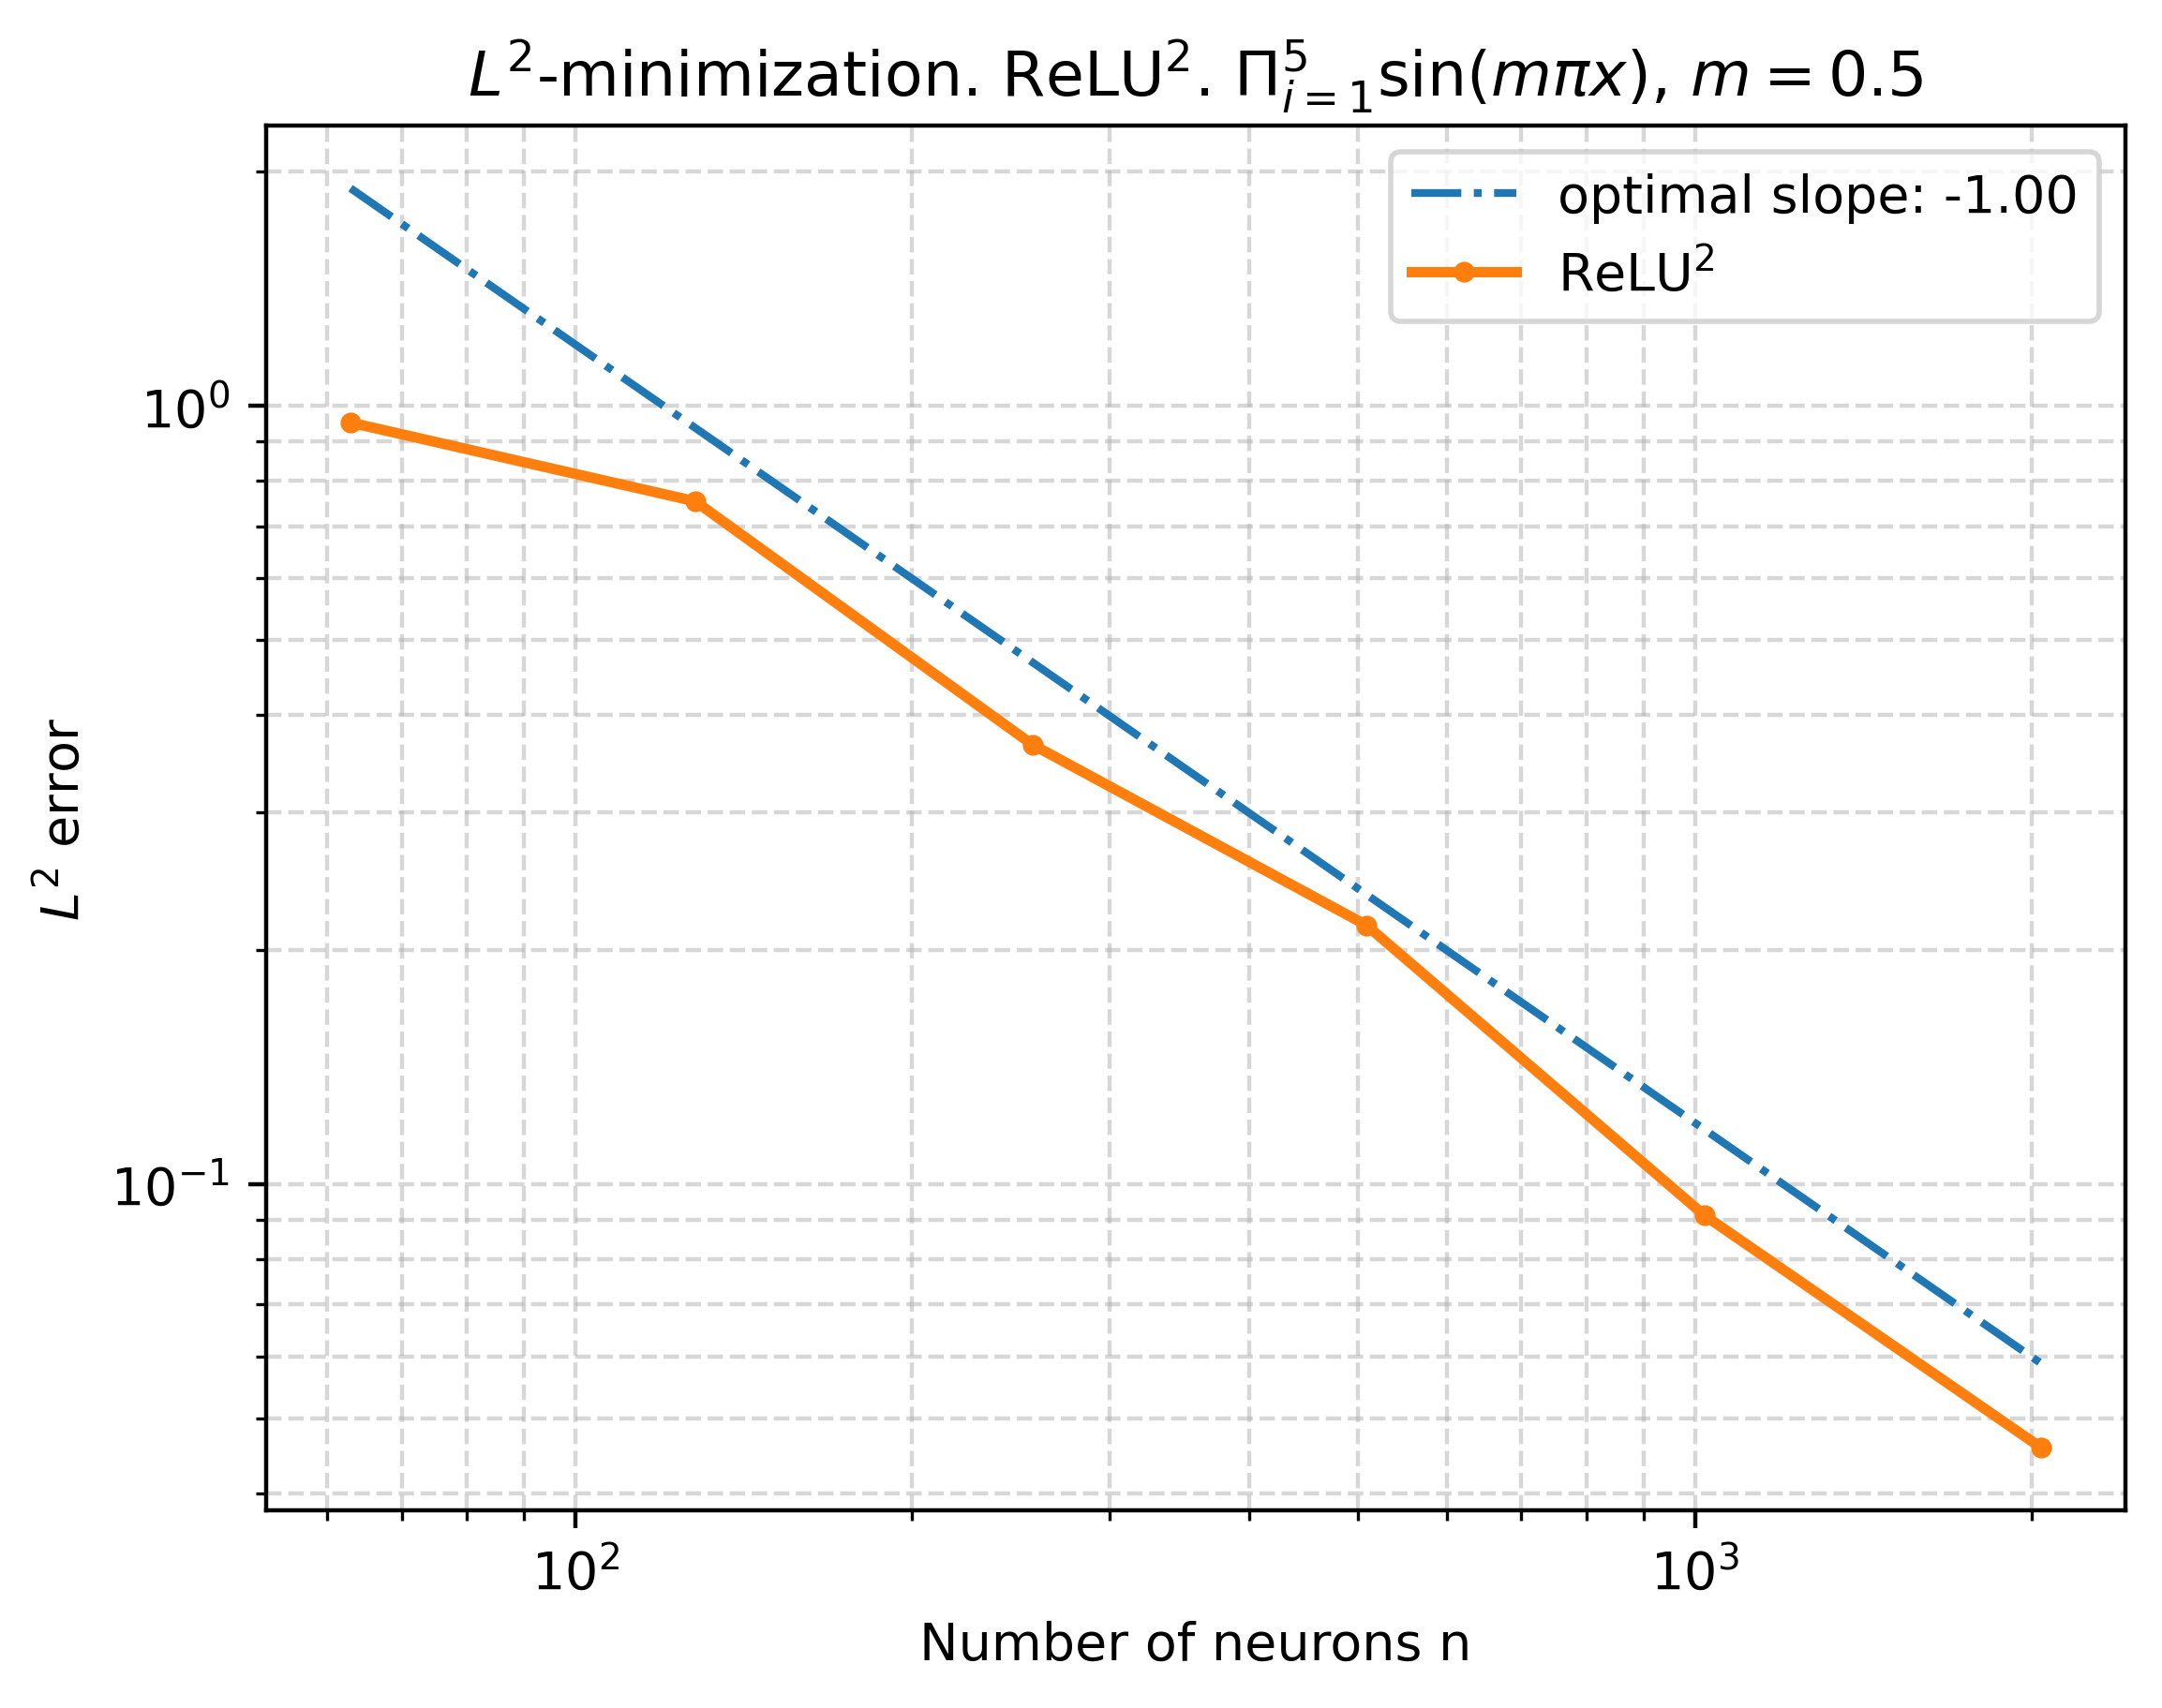

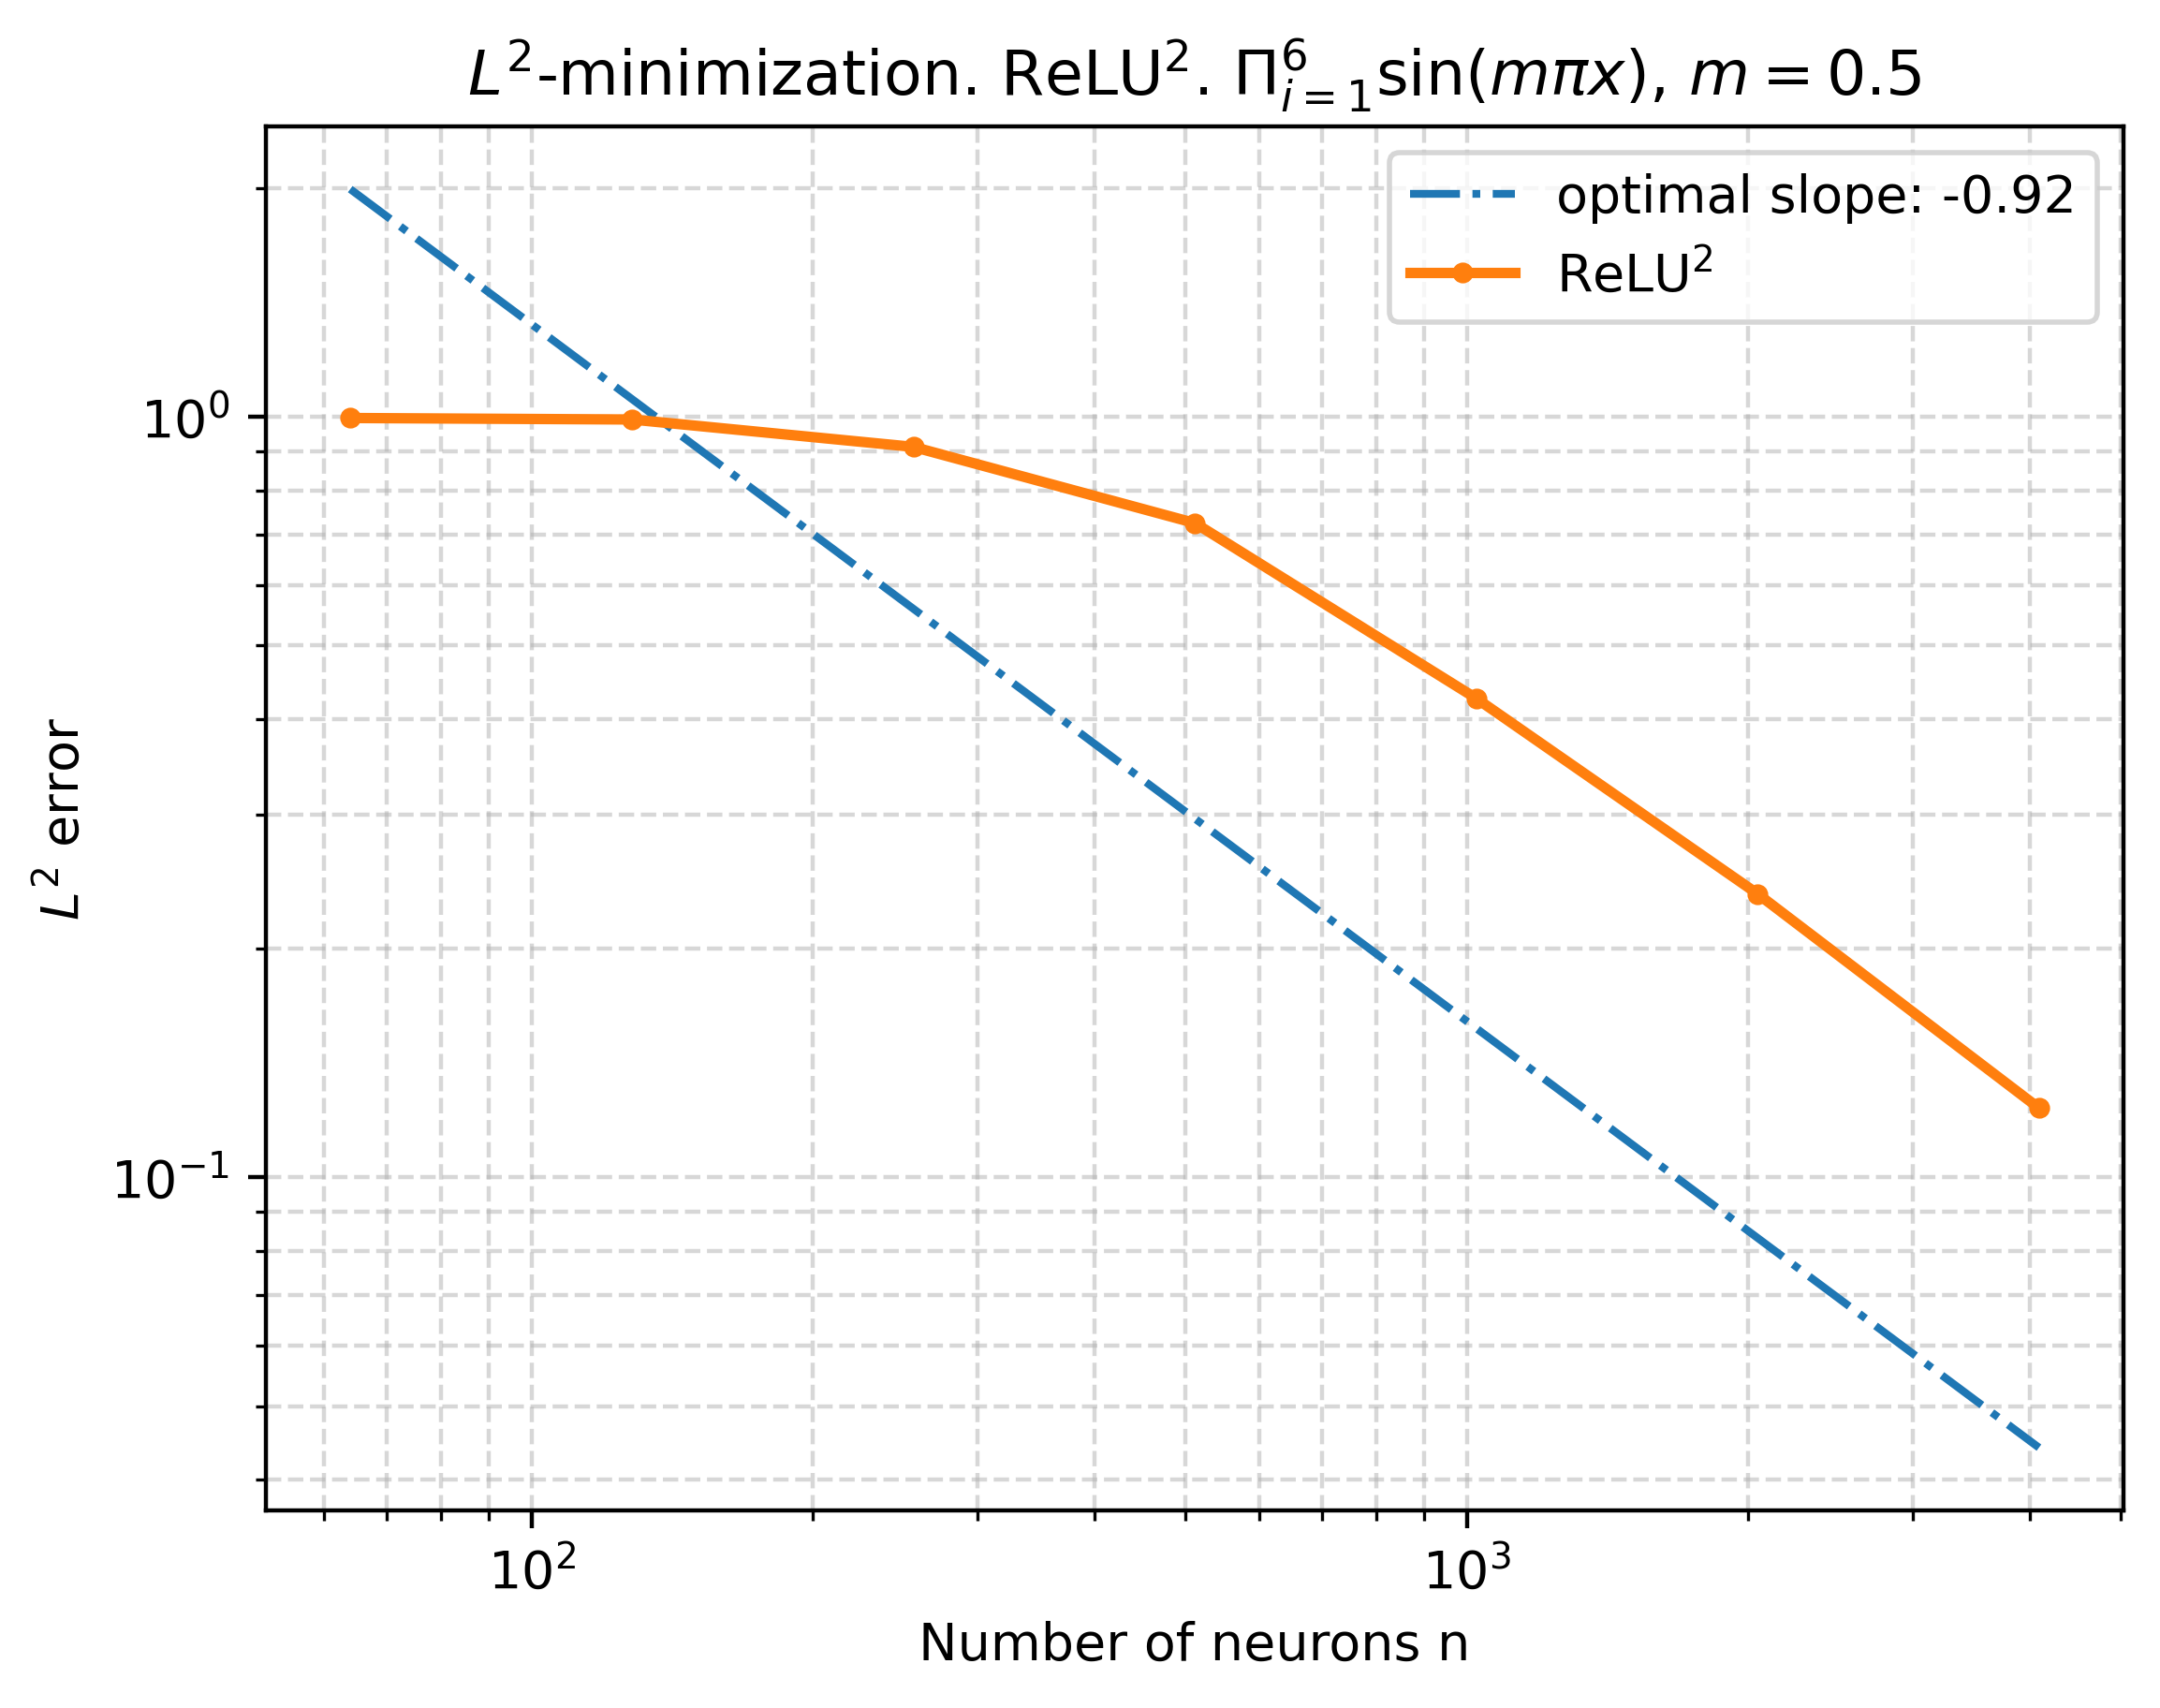

In [9]:
m = 1/2 
for d in range(5,7): 
    relu_k = 2

    folder = './'
    data = np.load(f'{folder}L2minimization-{d}d-relu{relu_k}.npz')

    # access arrays by their keys
    actual_neuron_arr = data['actual_neuron_arr']
    mean_err_l2_arr_2 = data['mean_err_l2_arr_2']

    if relu_k == 1:
        title =f"$L^2$-minimization. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    else:
        title = f"$L^2$-minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    
    plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title,scale=2)

## Collocation method (discrete l^2 regression)


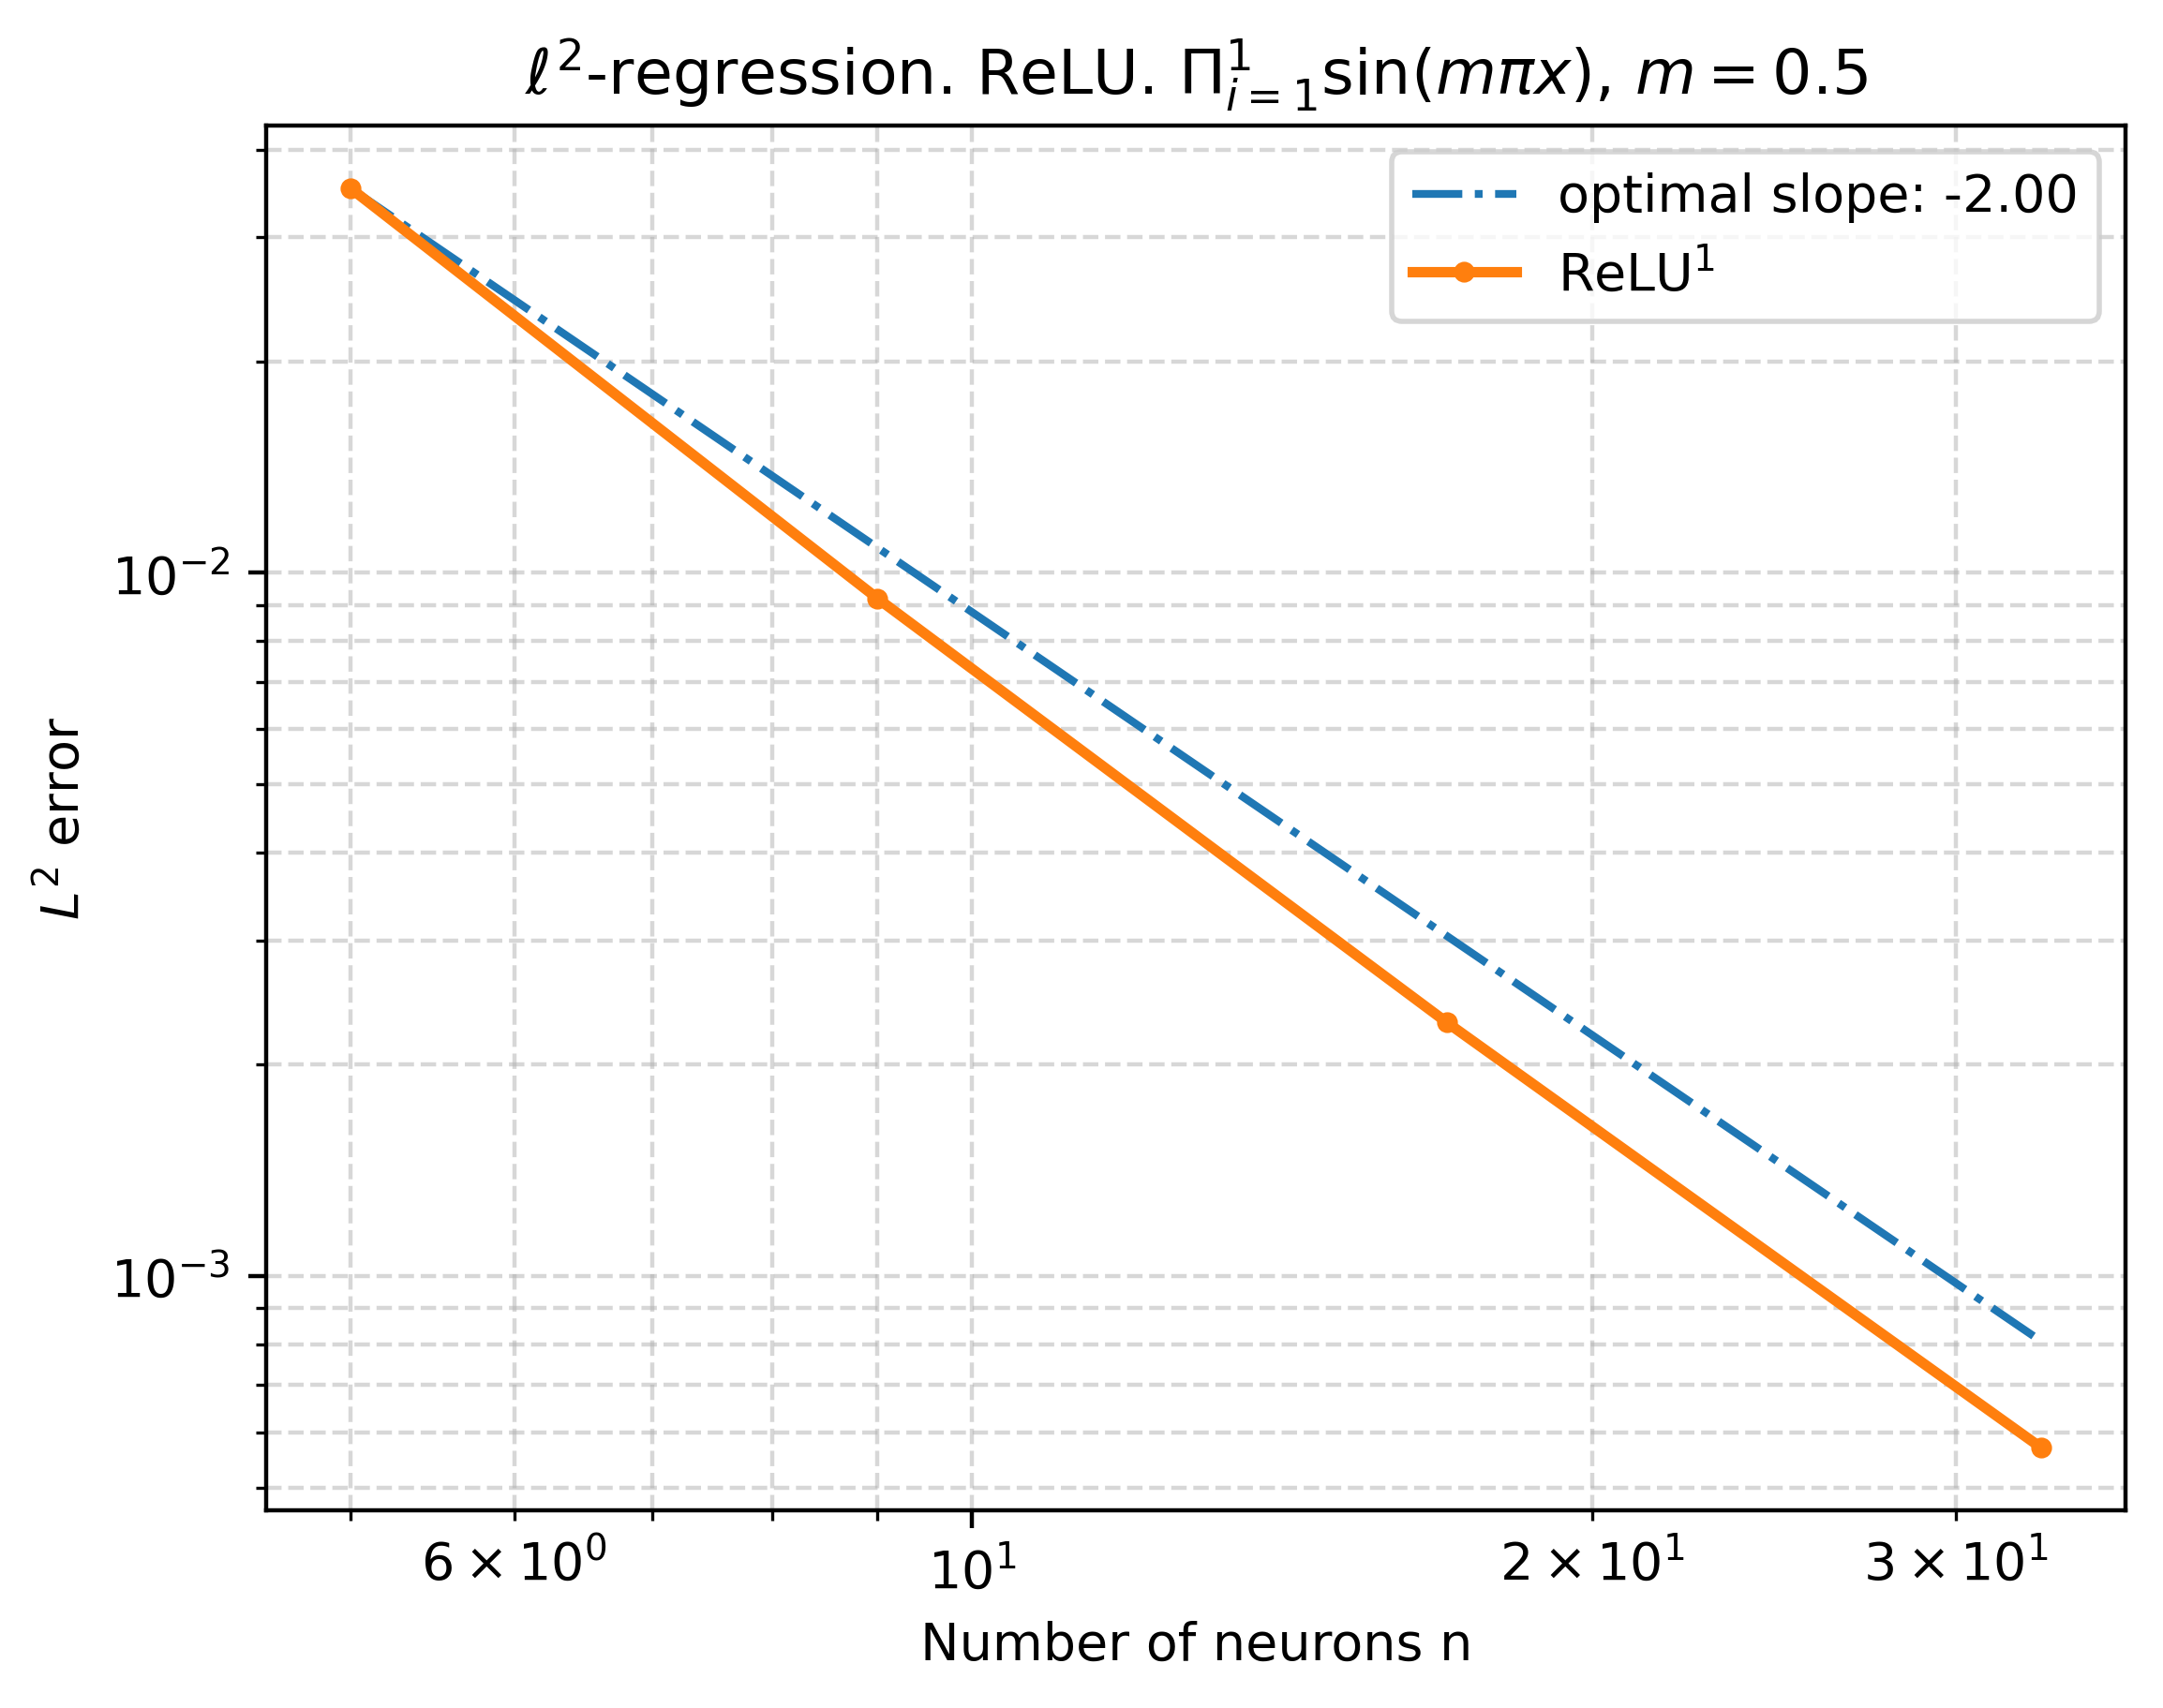

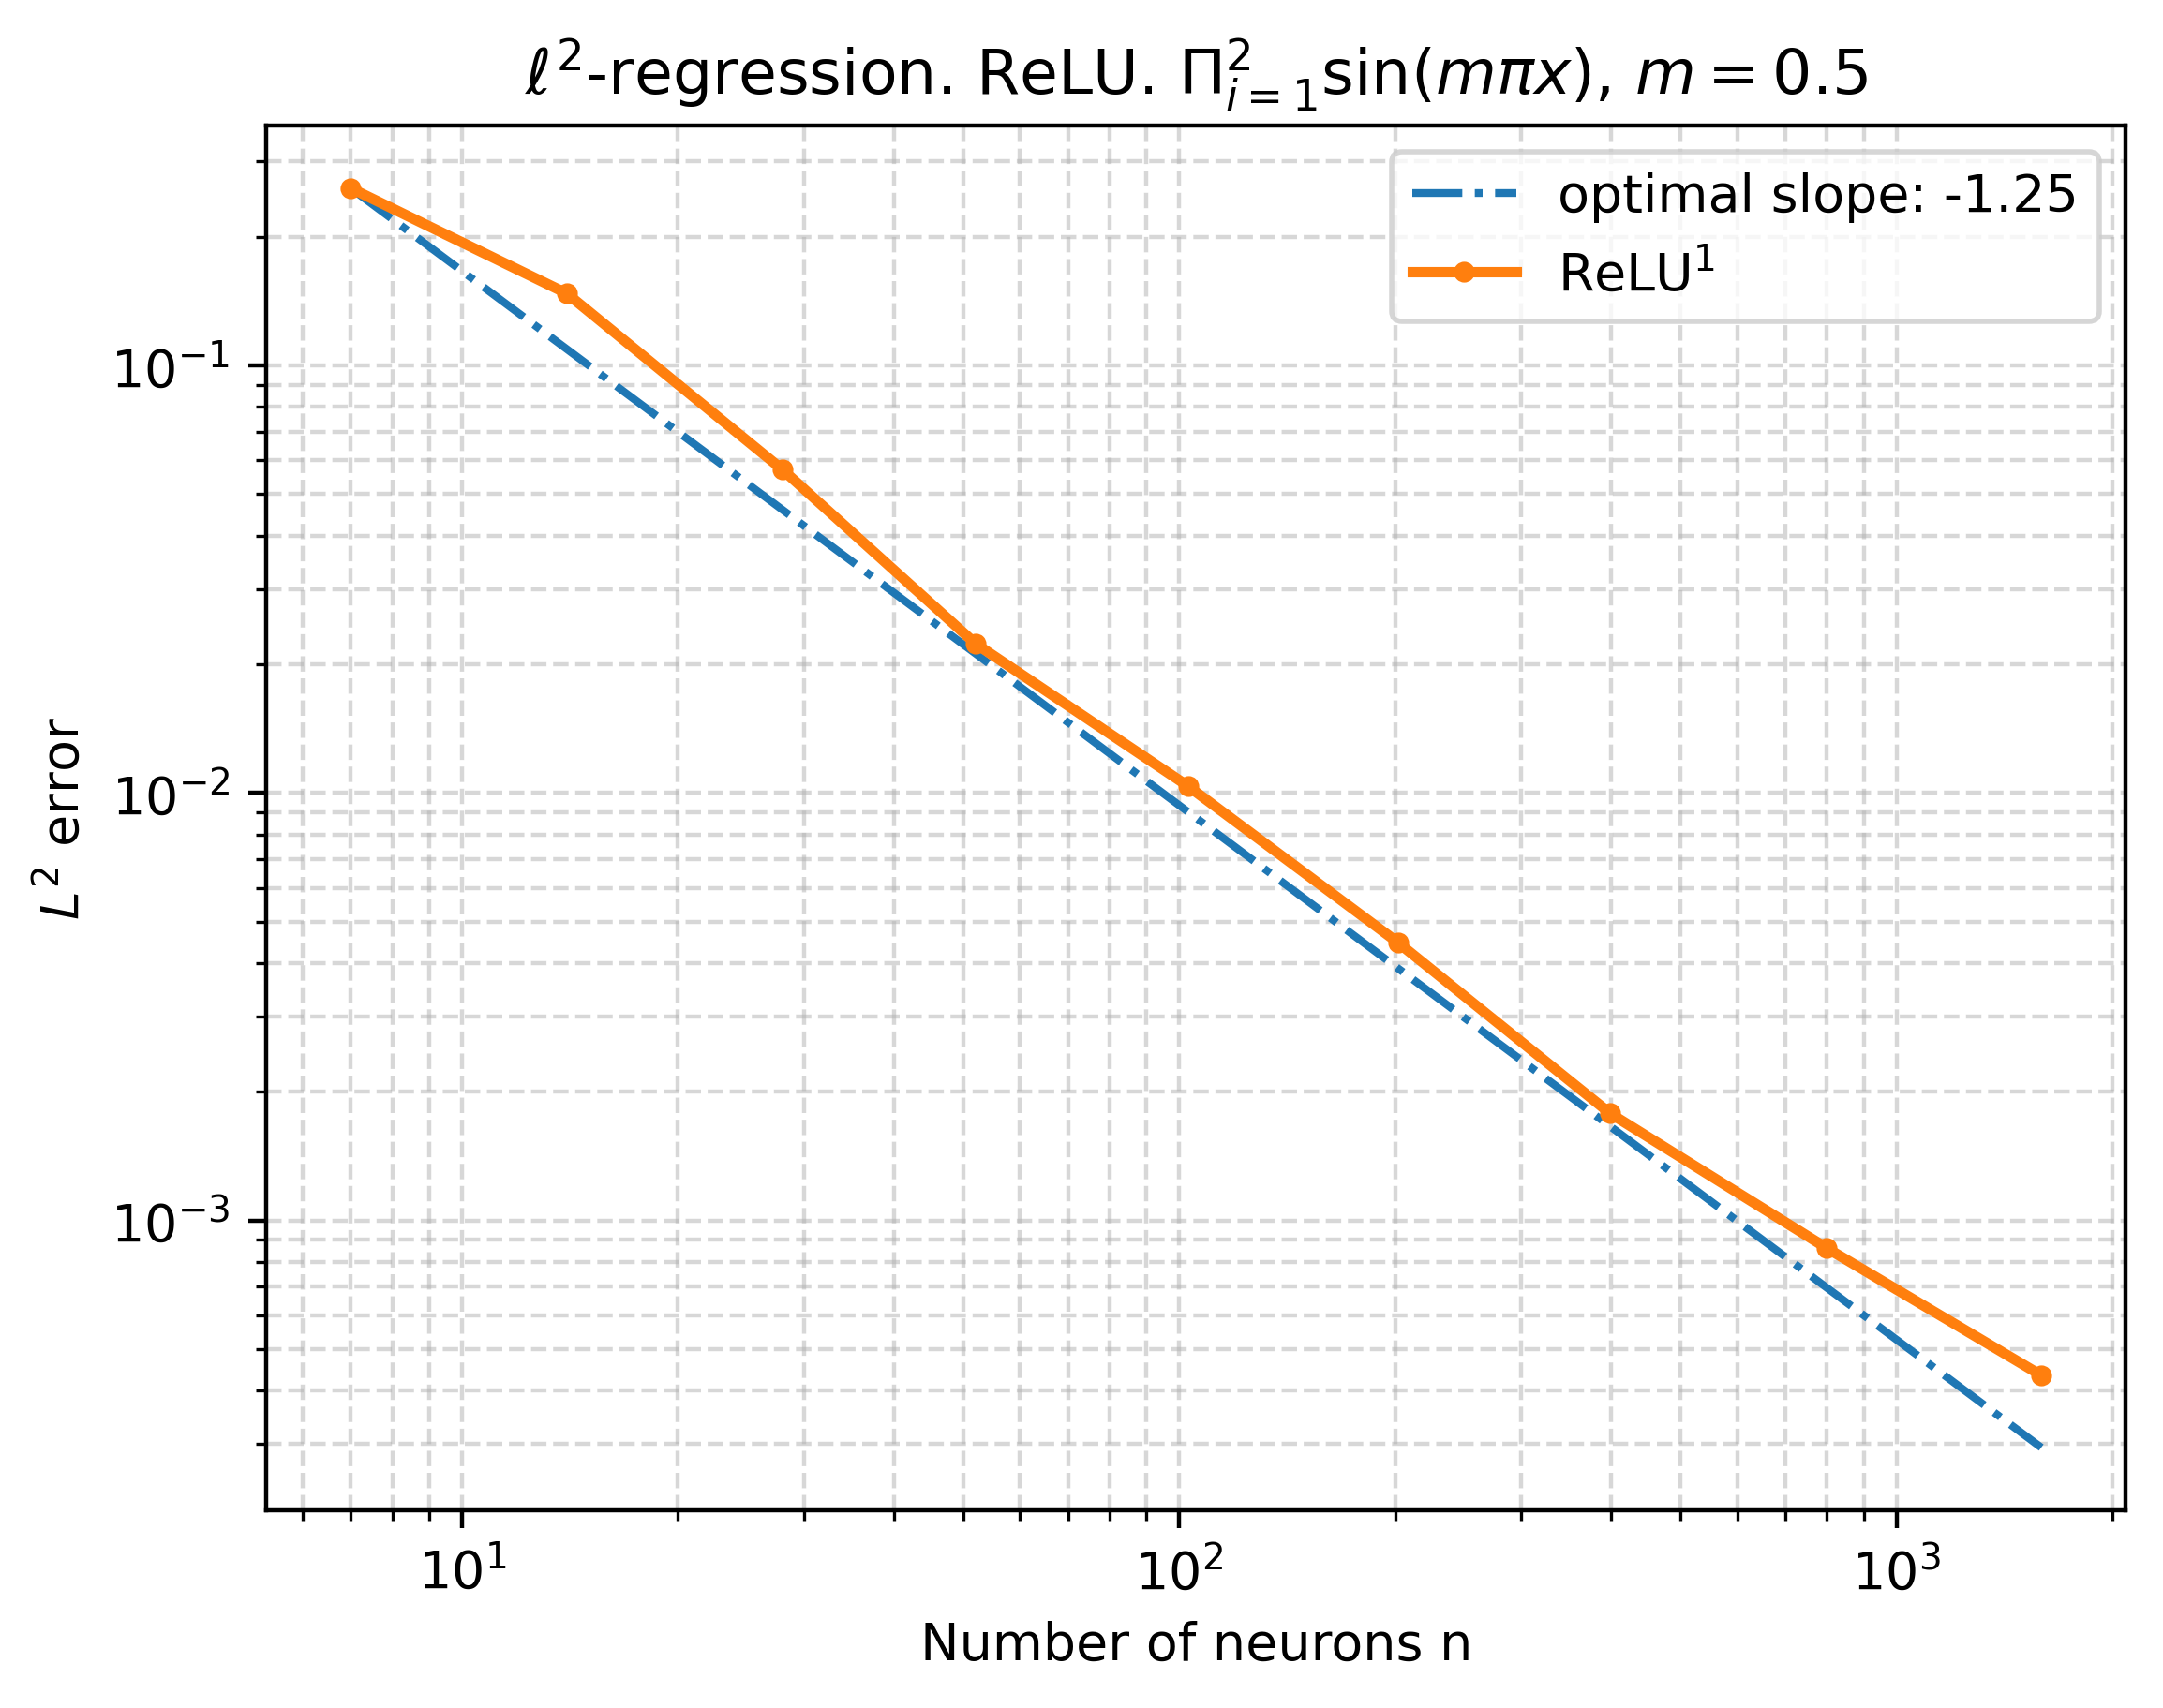

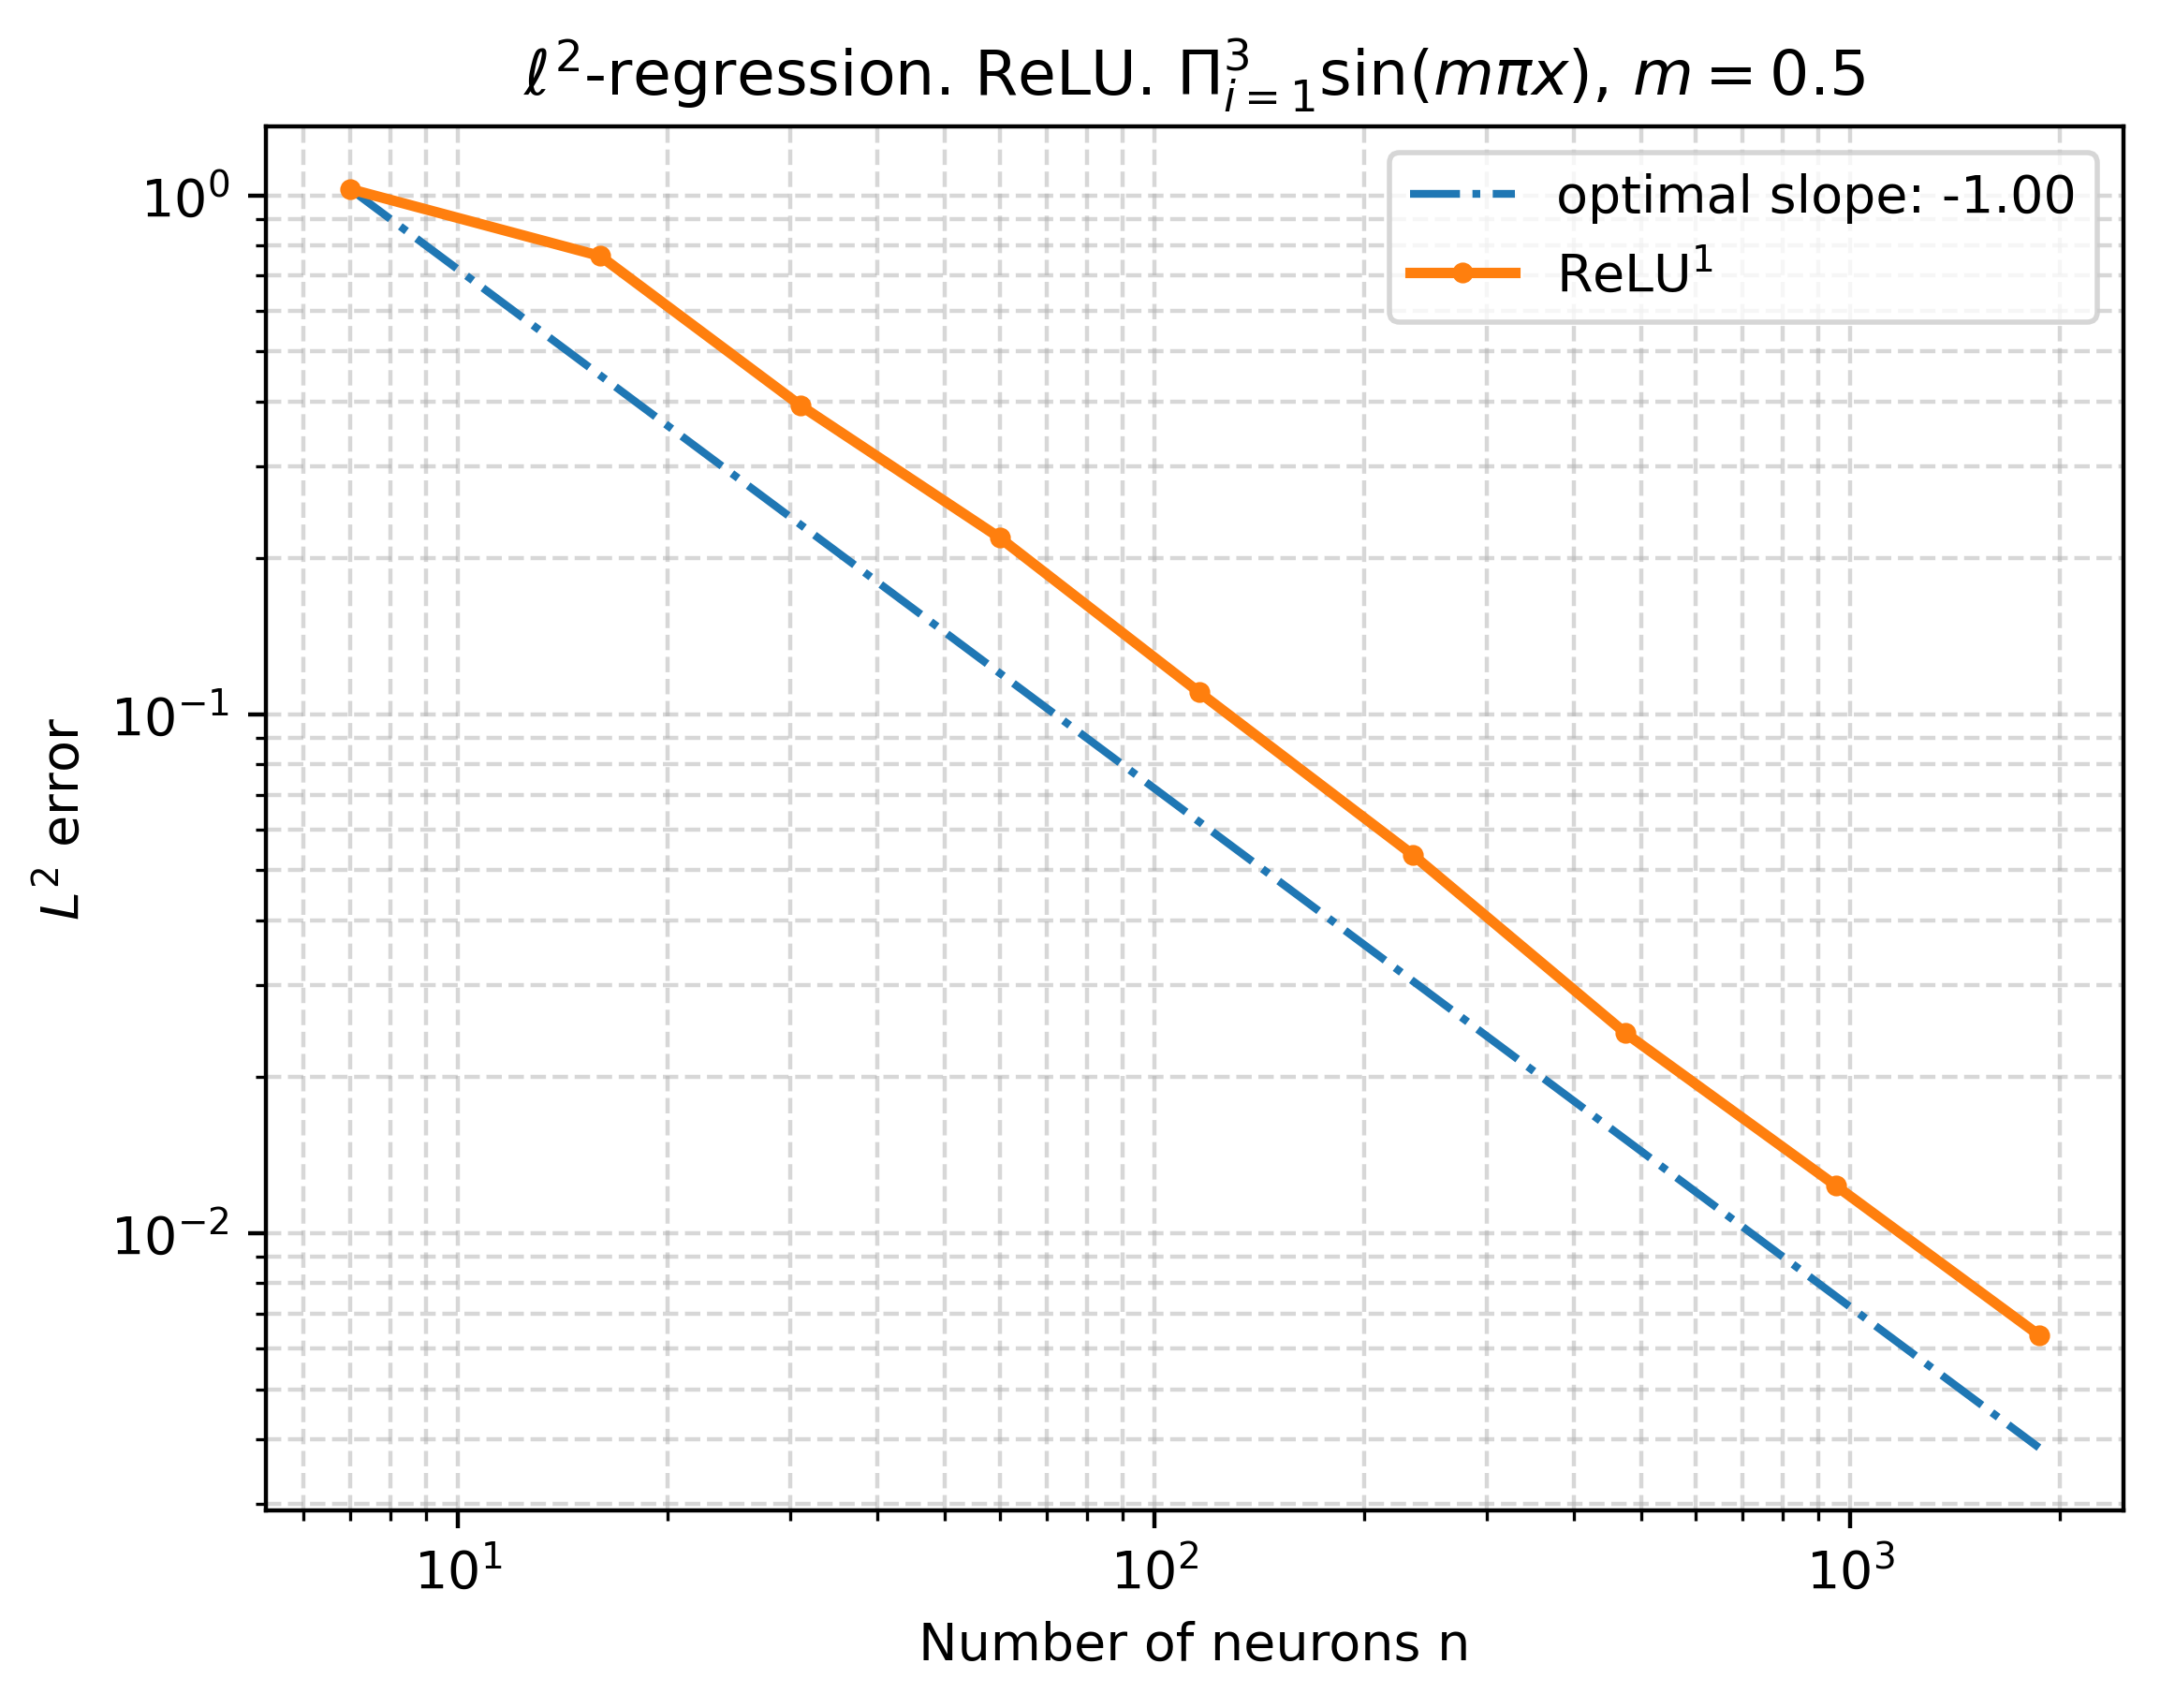

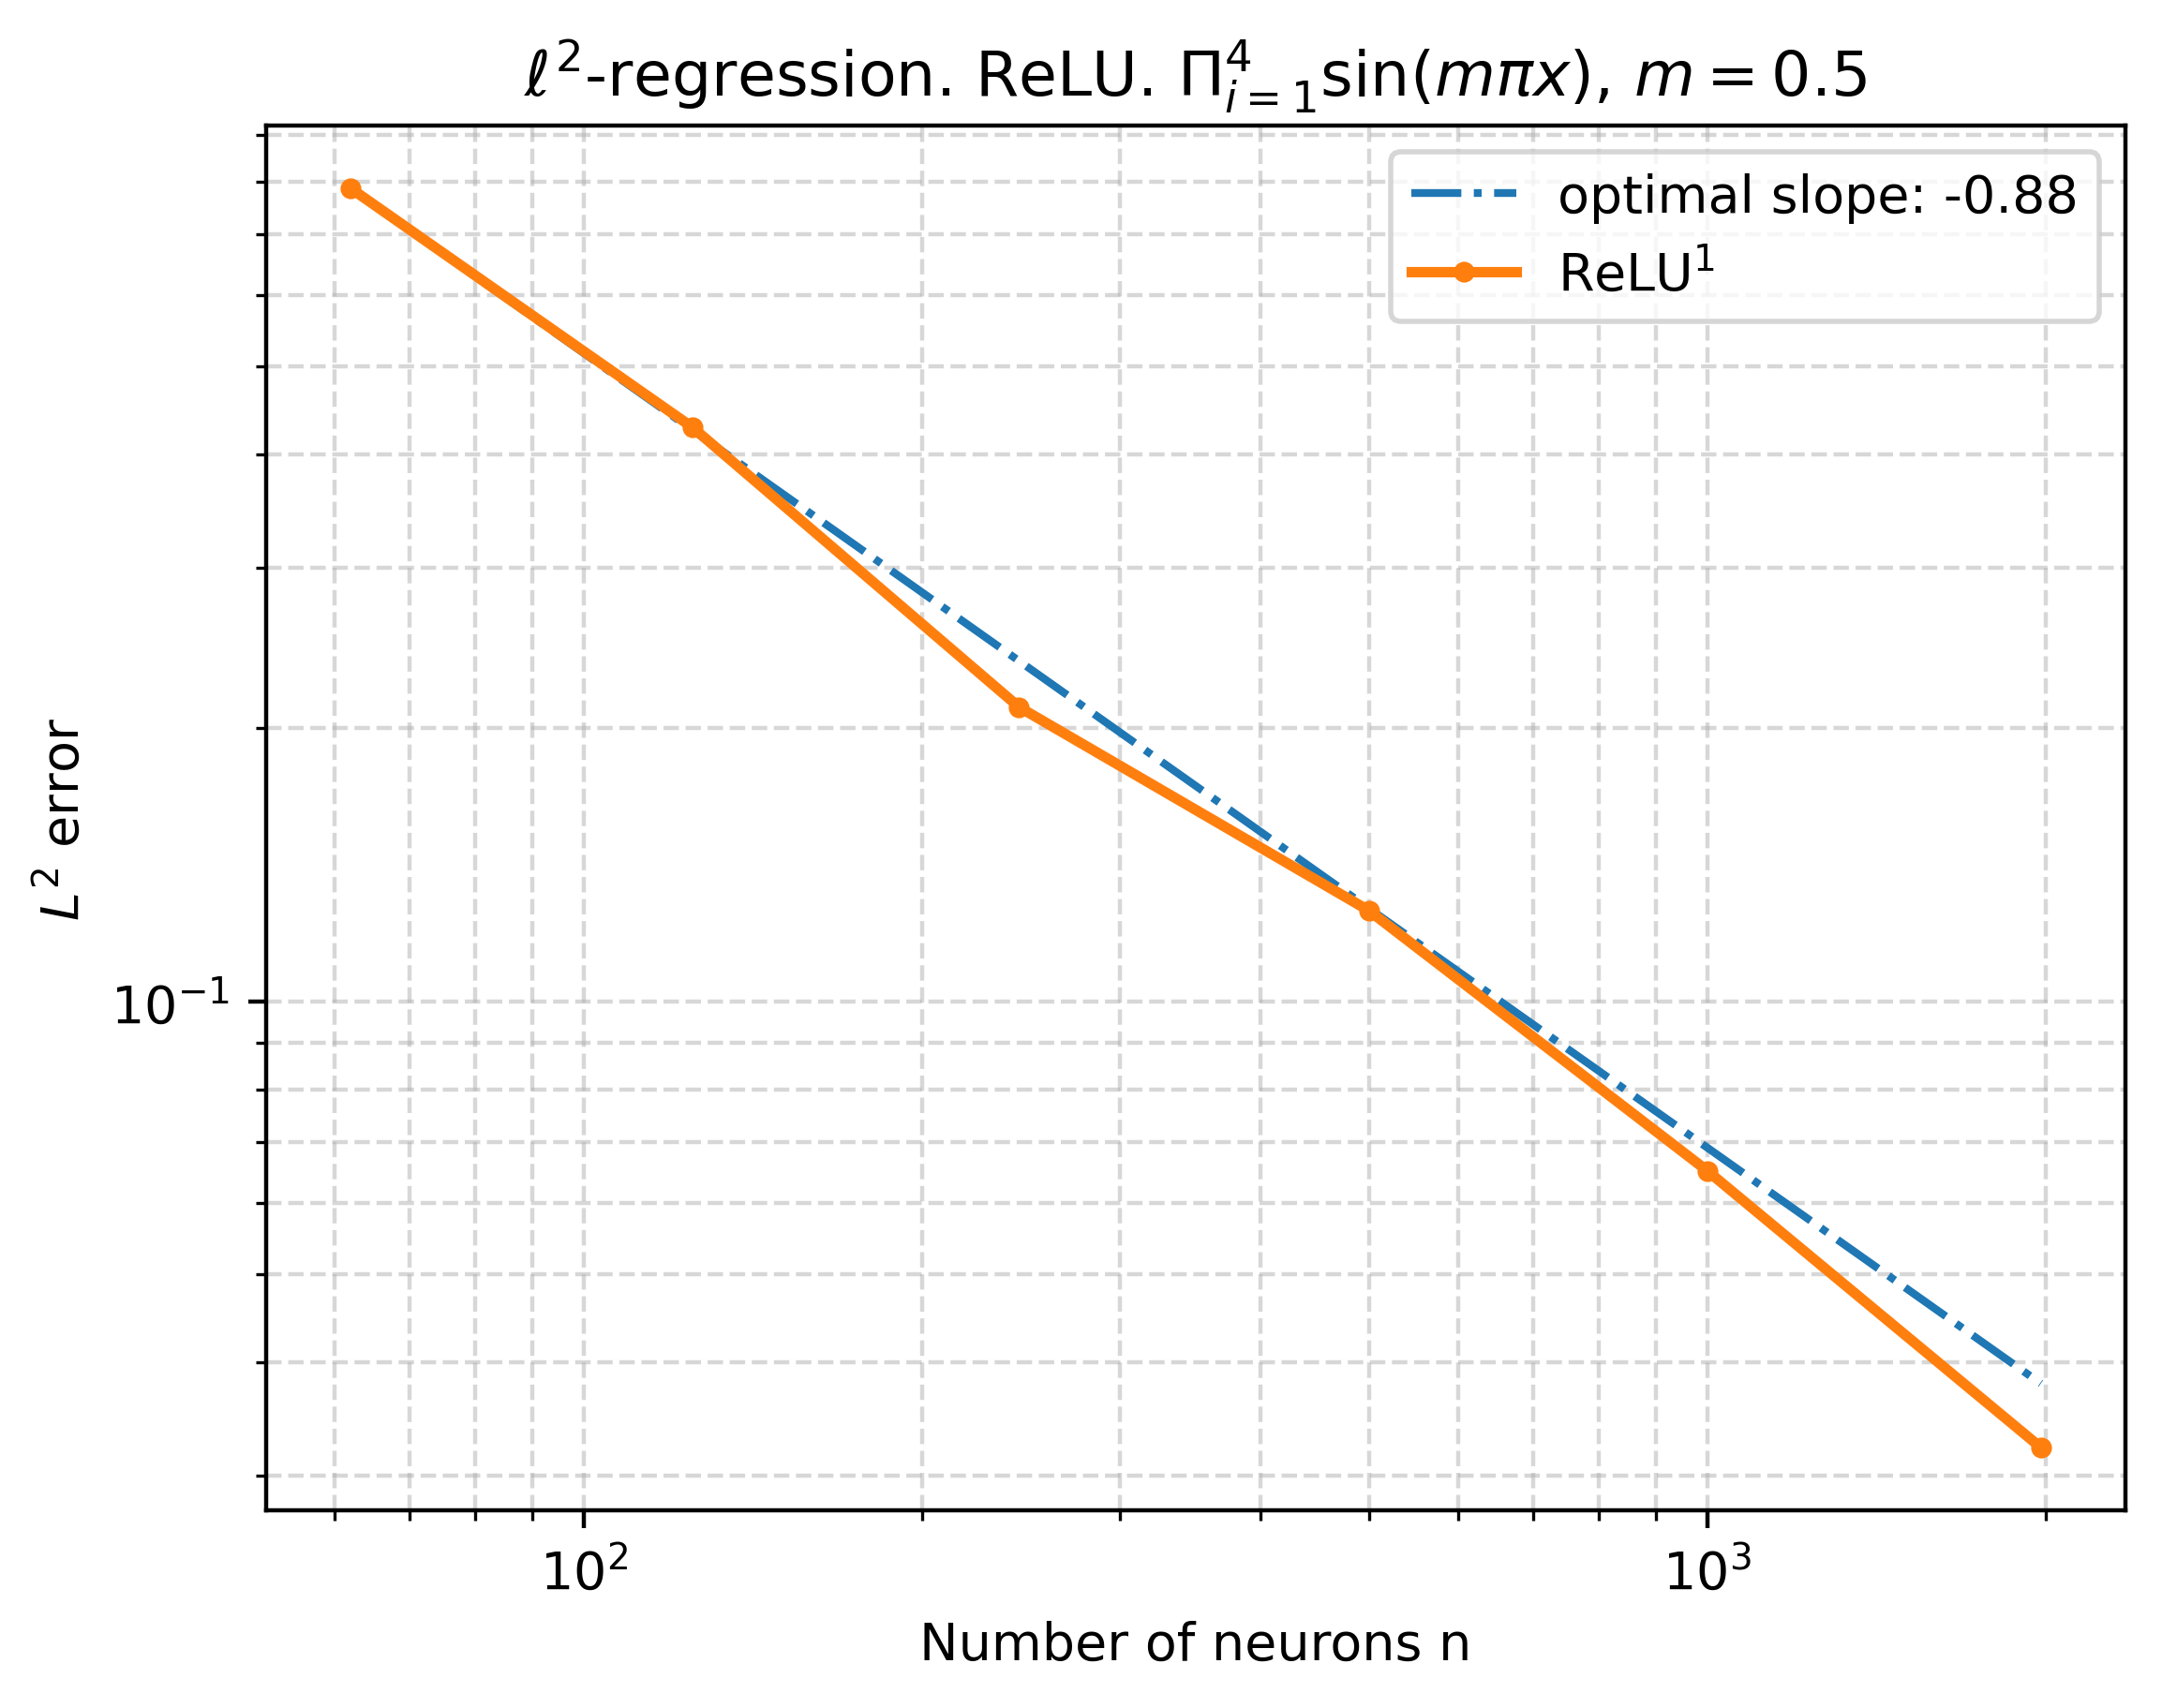

In [10]:
m = 1/2 
for d in range(1,5): 
    relu_k = 1
    
    folder = './'
    data = np.load(f'{folder}collocation-l2regression-{d}d-relu{relu_k}.npz')

    # access arrays by their keys
    actual_neuron_arr = data['actual_neuron_arr']
    mean_err_l2_arr_2 = data['mean_err_l2_arr_2']

    if relu_k == 1:
        title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    else:
        title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    
    plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)

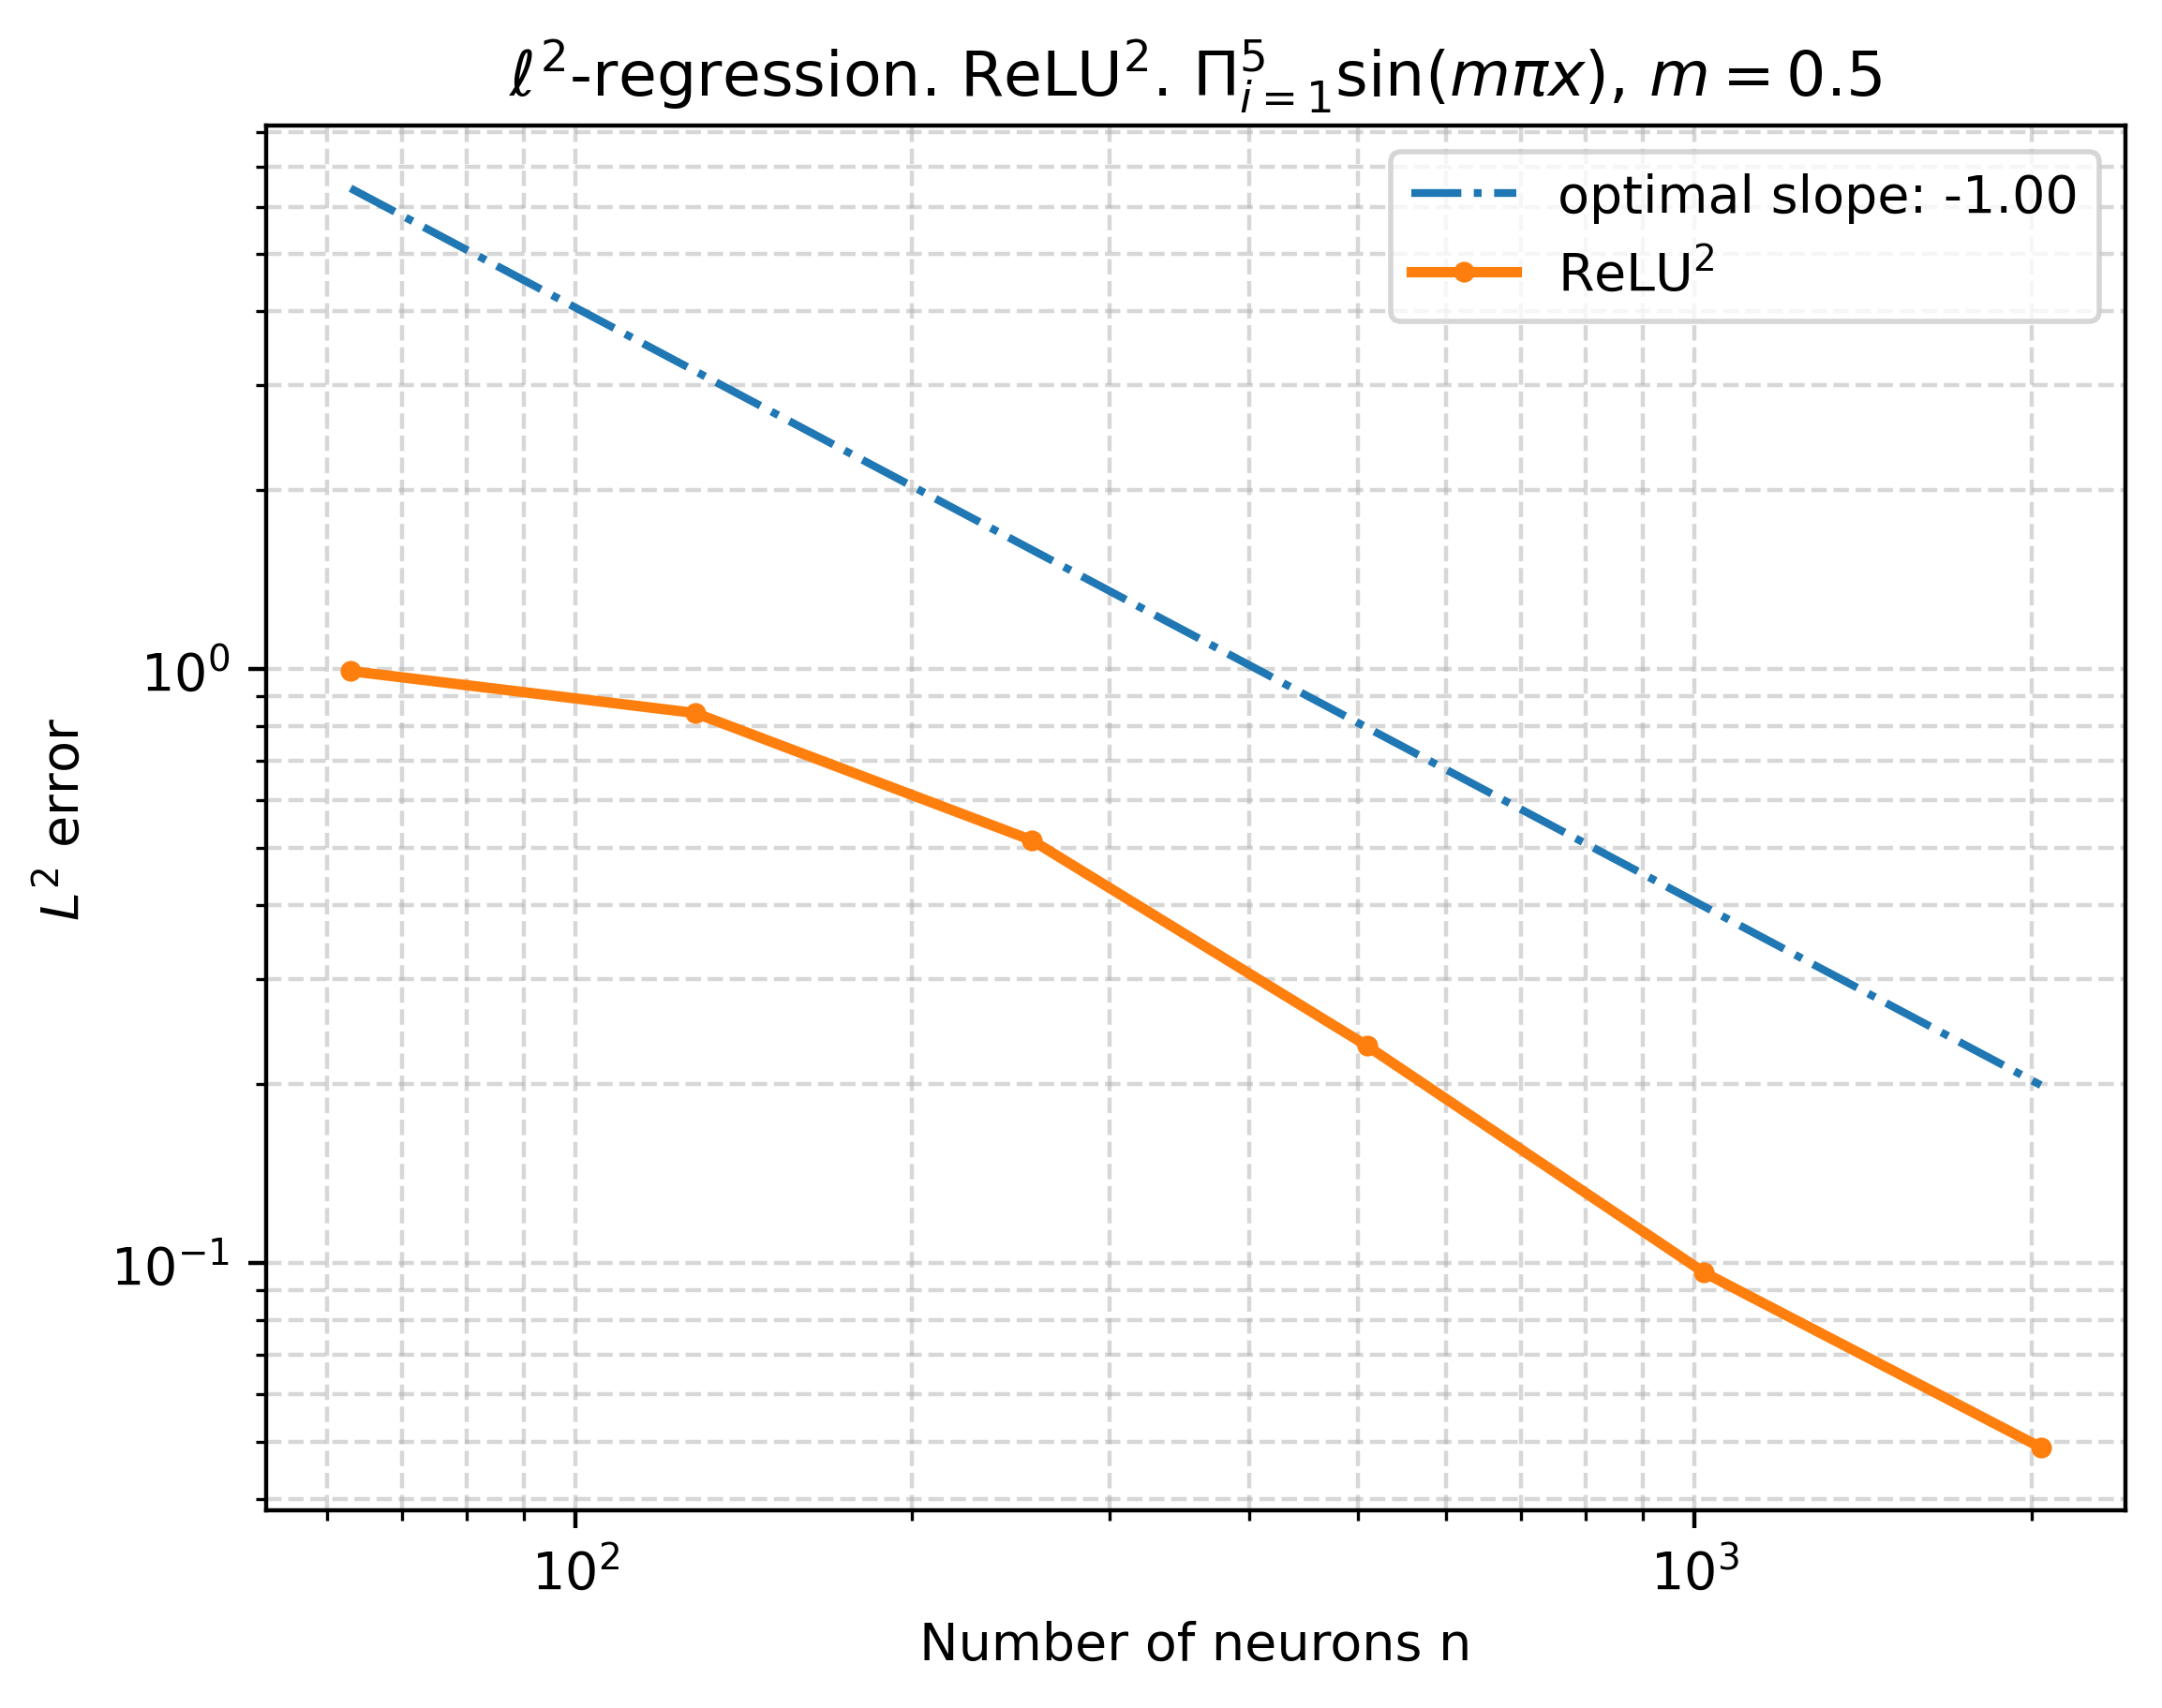

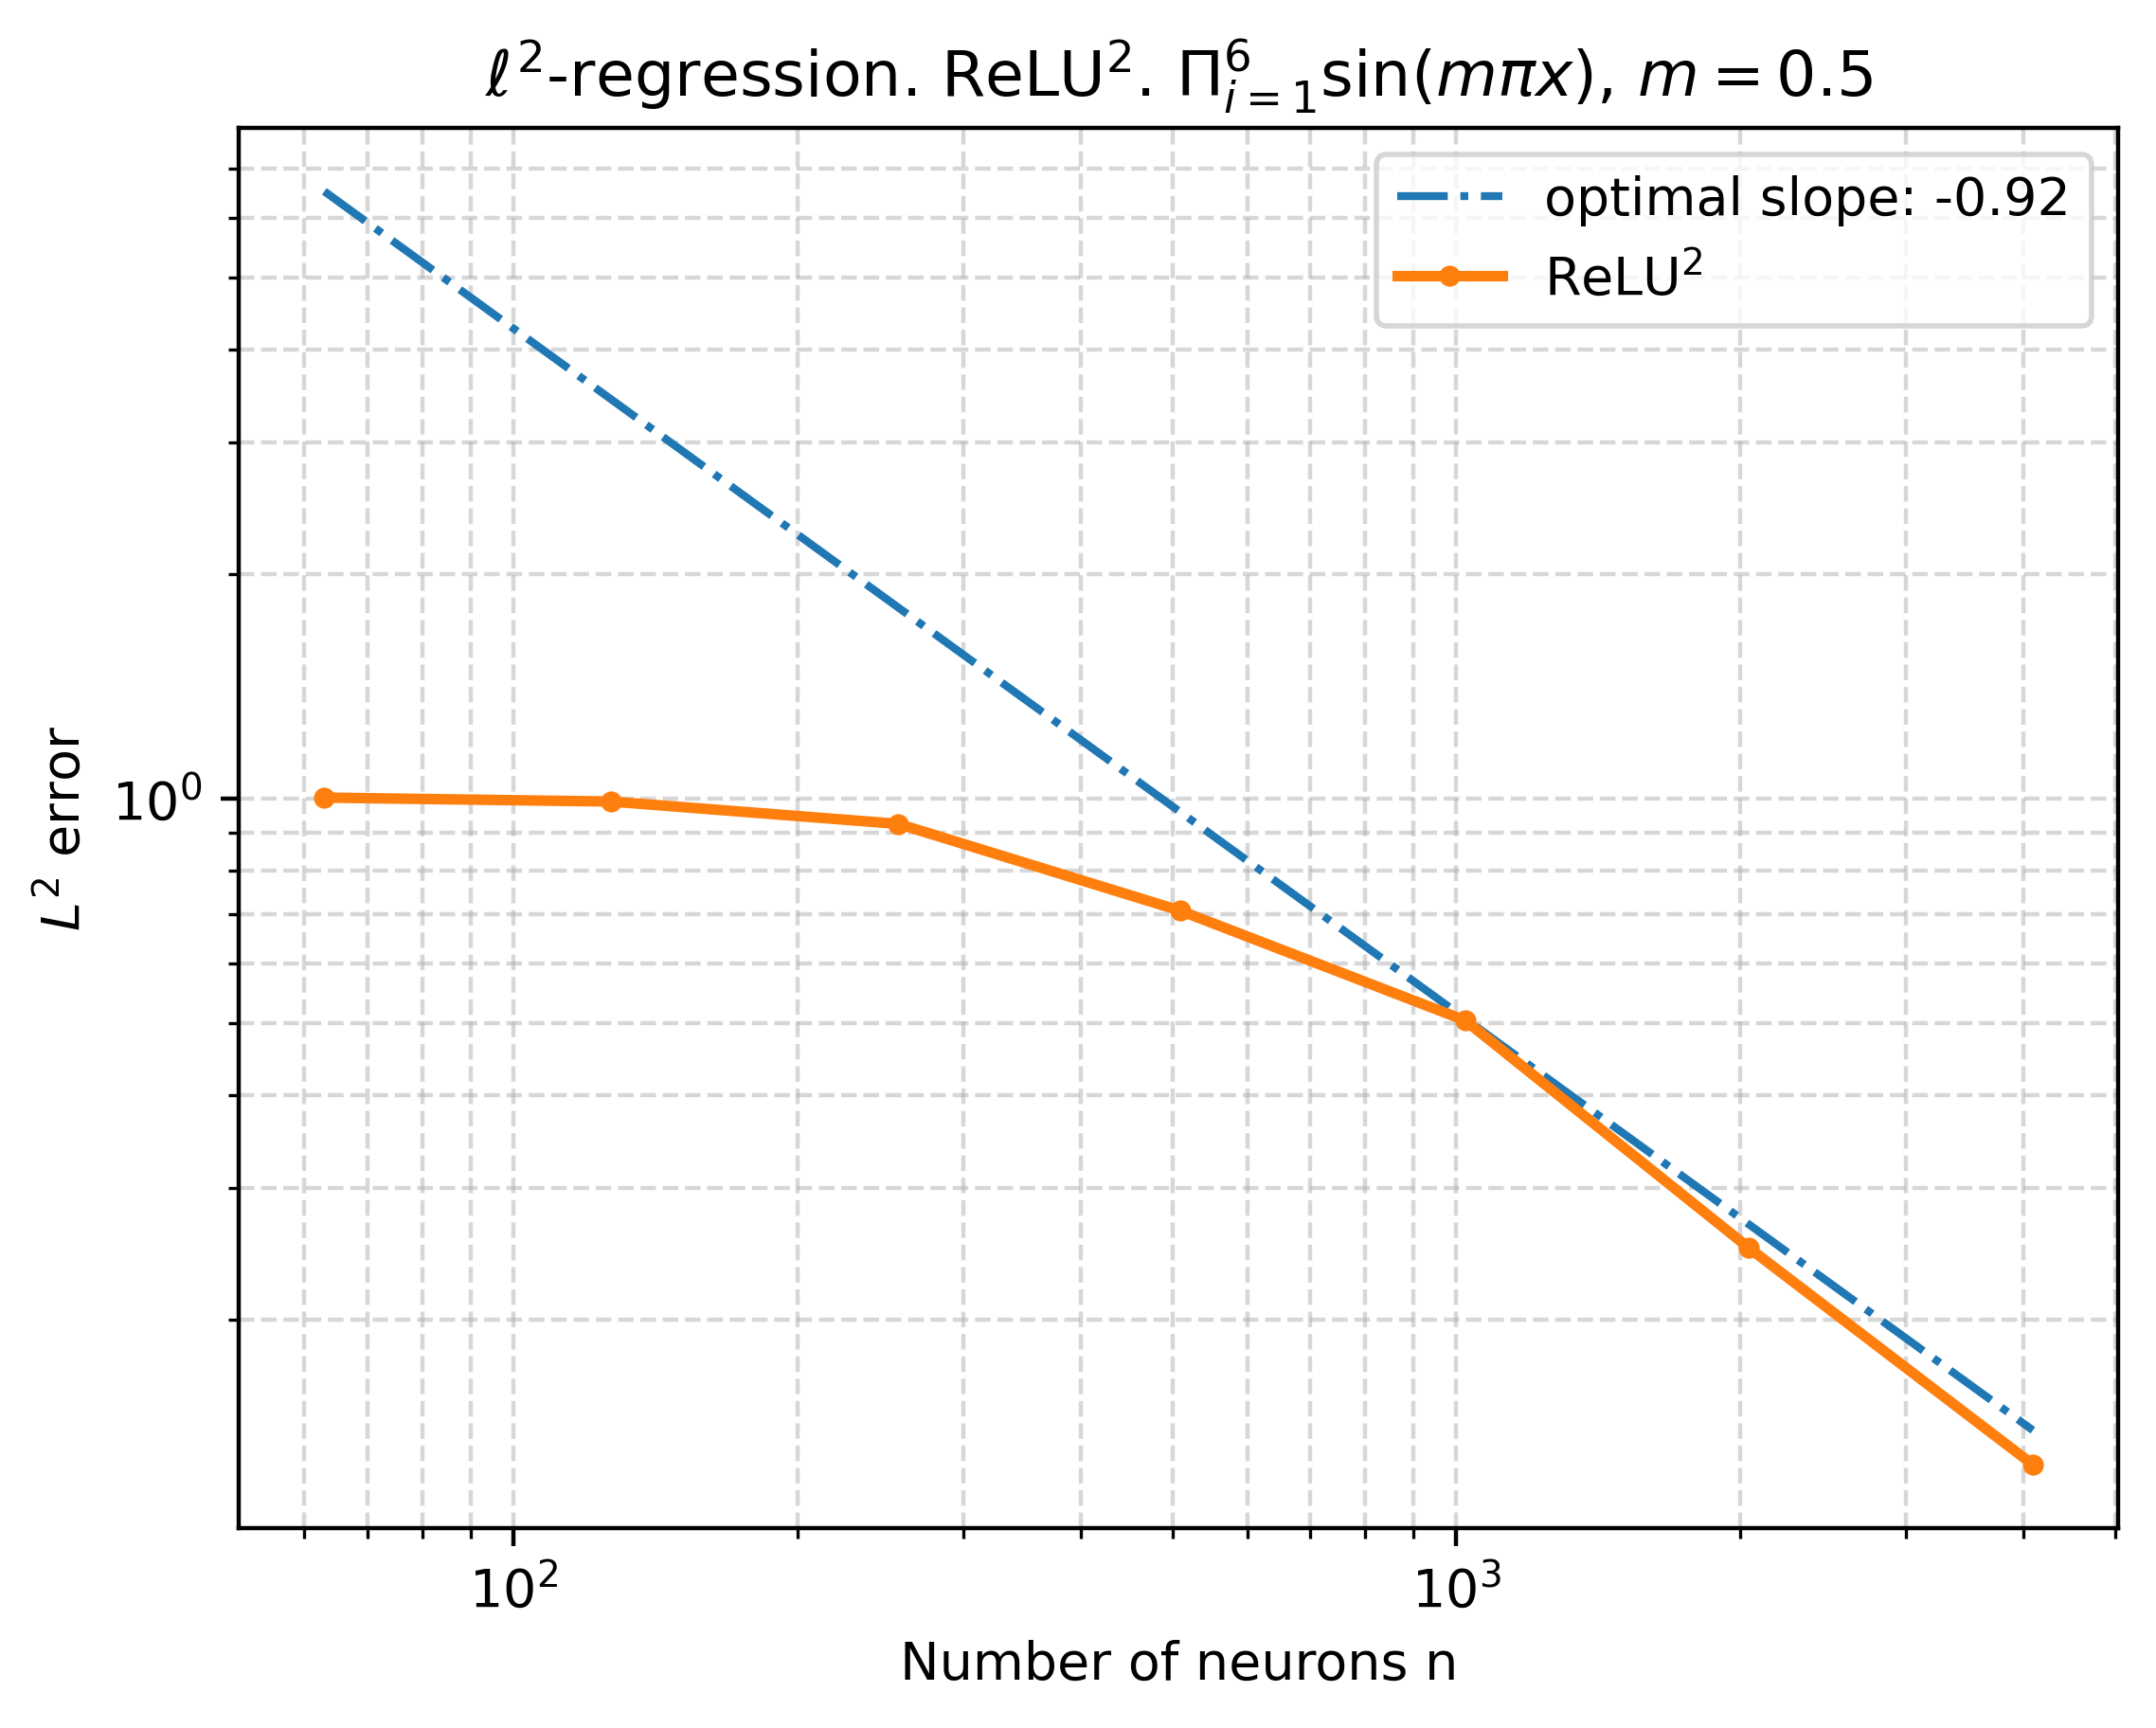

In [15]:
m = 1/2 
for d in range(5,7): 
    relu_k = 2 
    
    folder = './'
    data = np.load(f'{folder}collocation-l2regression-{d}d-relu{relu_k}.npz')

    # access arrays by their keys
    actual_neuron_arr = data['actual_neuron_arr']
    mean_err_l2_arr_2 = data['mean_err_l2_arr_2']

    if relu_k == 1:
        title =f"$\ell^2$-regression. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    else:
        title = f"$\ell^2$-regression. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    
    plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title,scale=6.5)

In [ ]:
## plot together

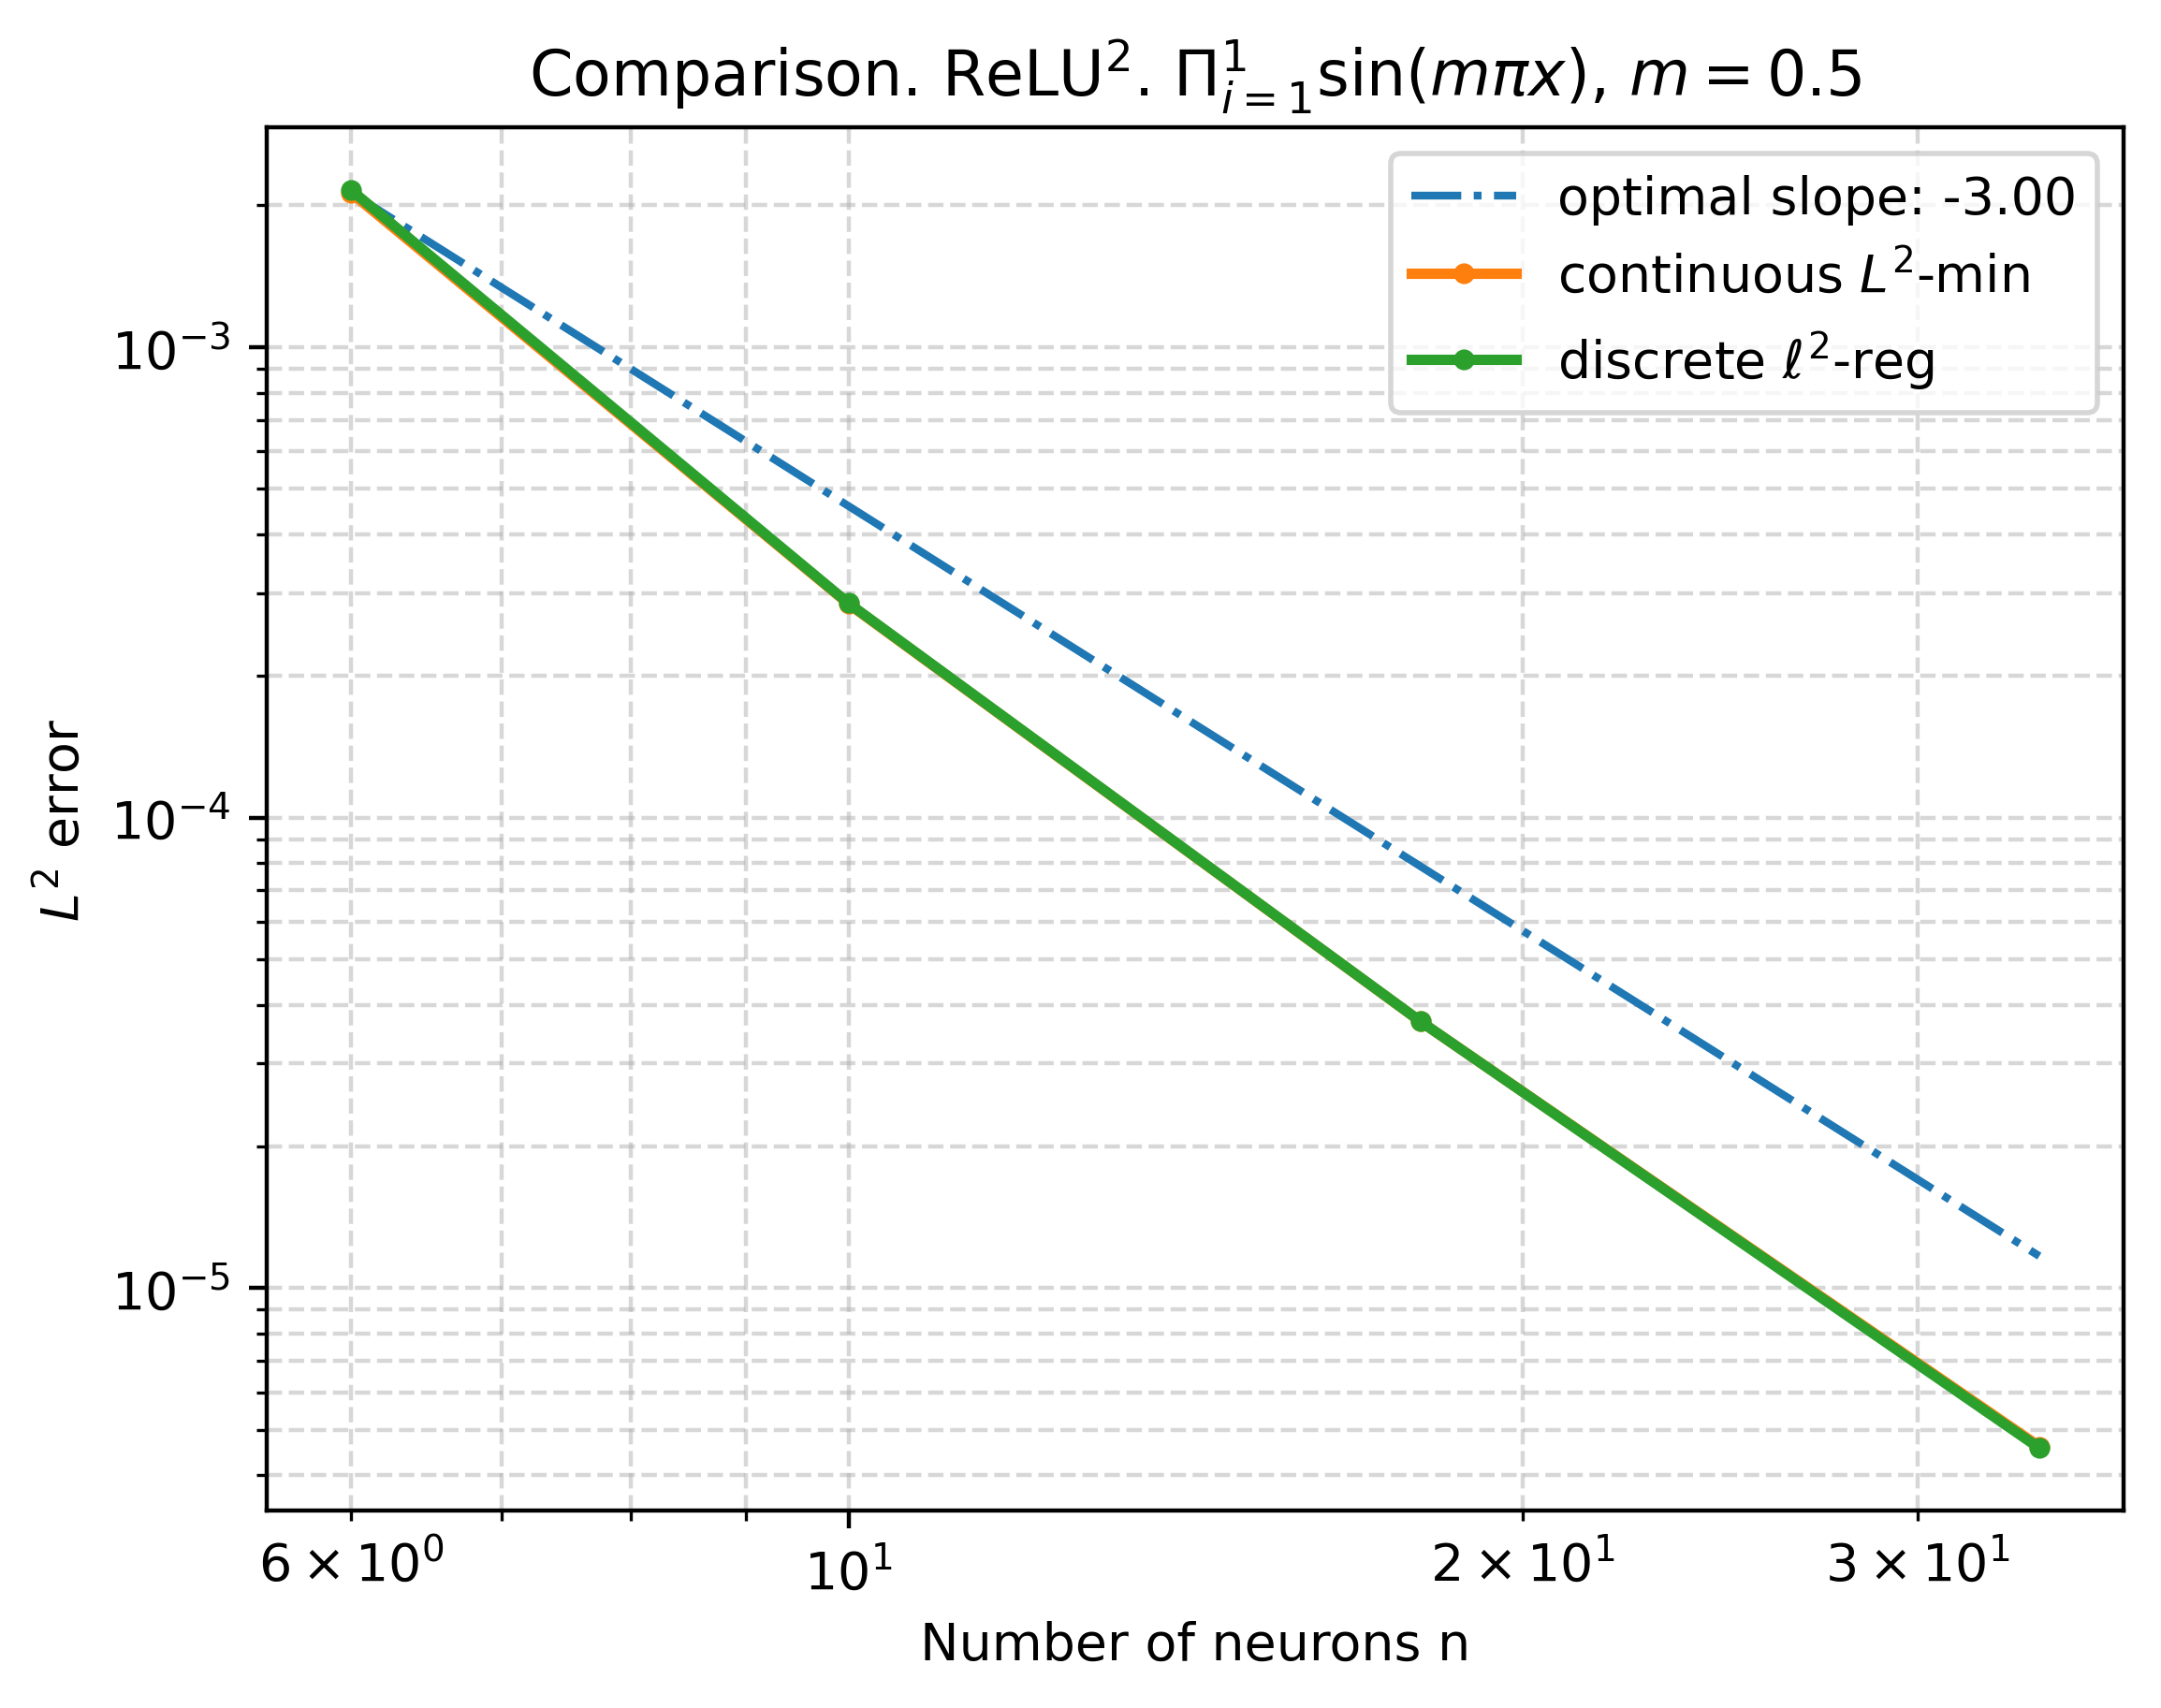

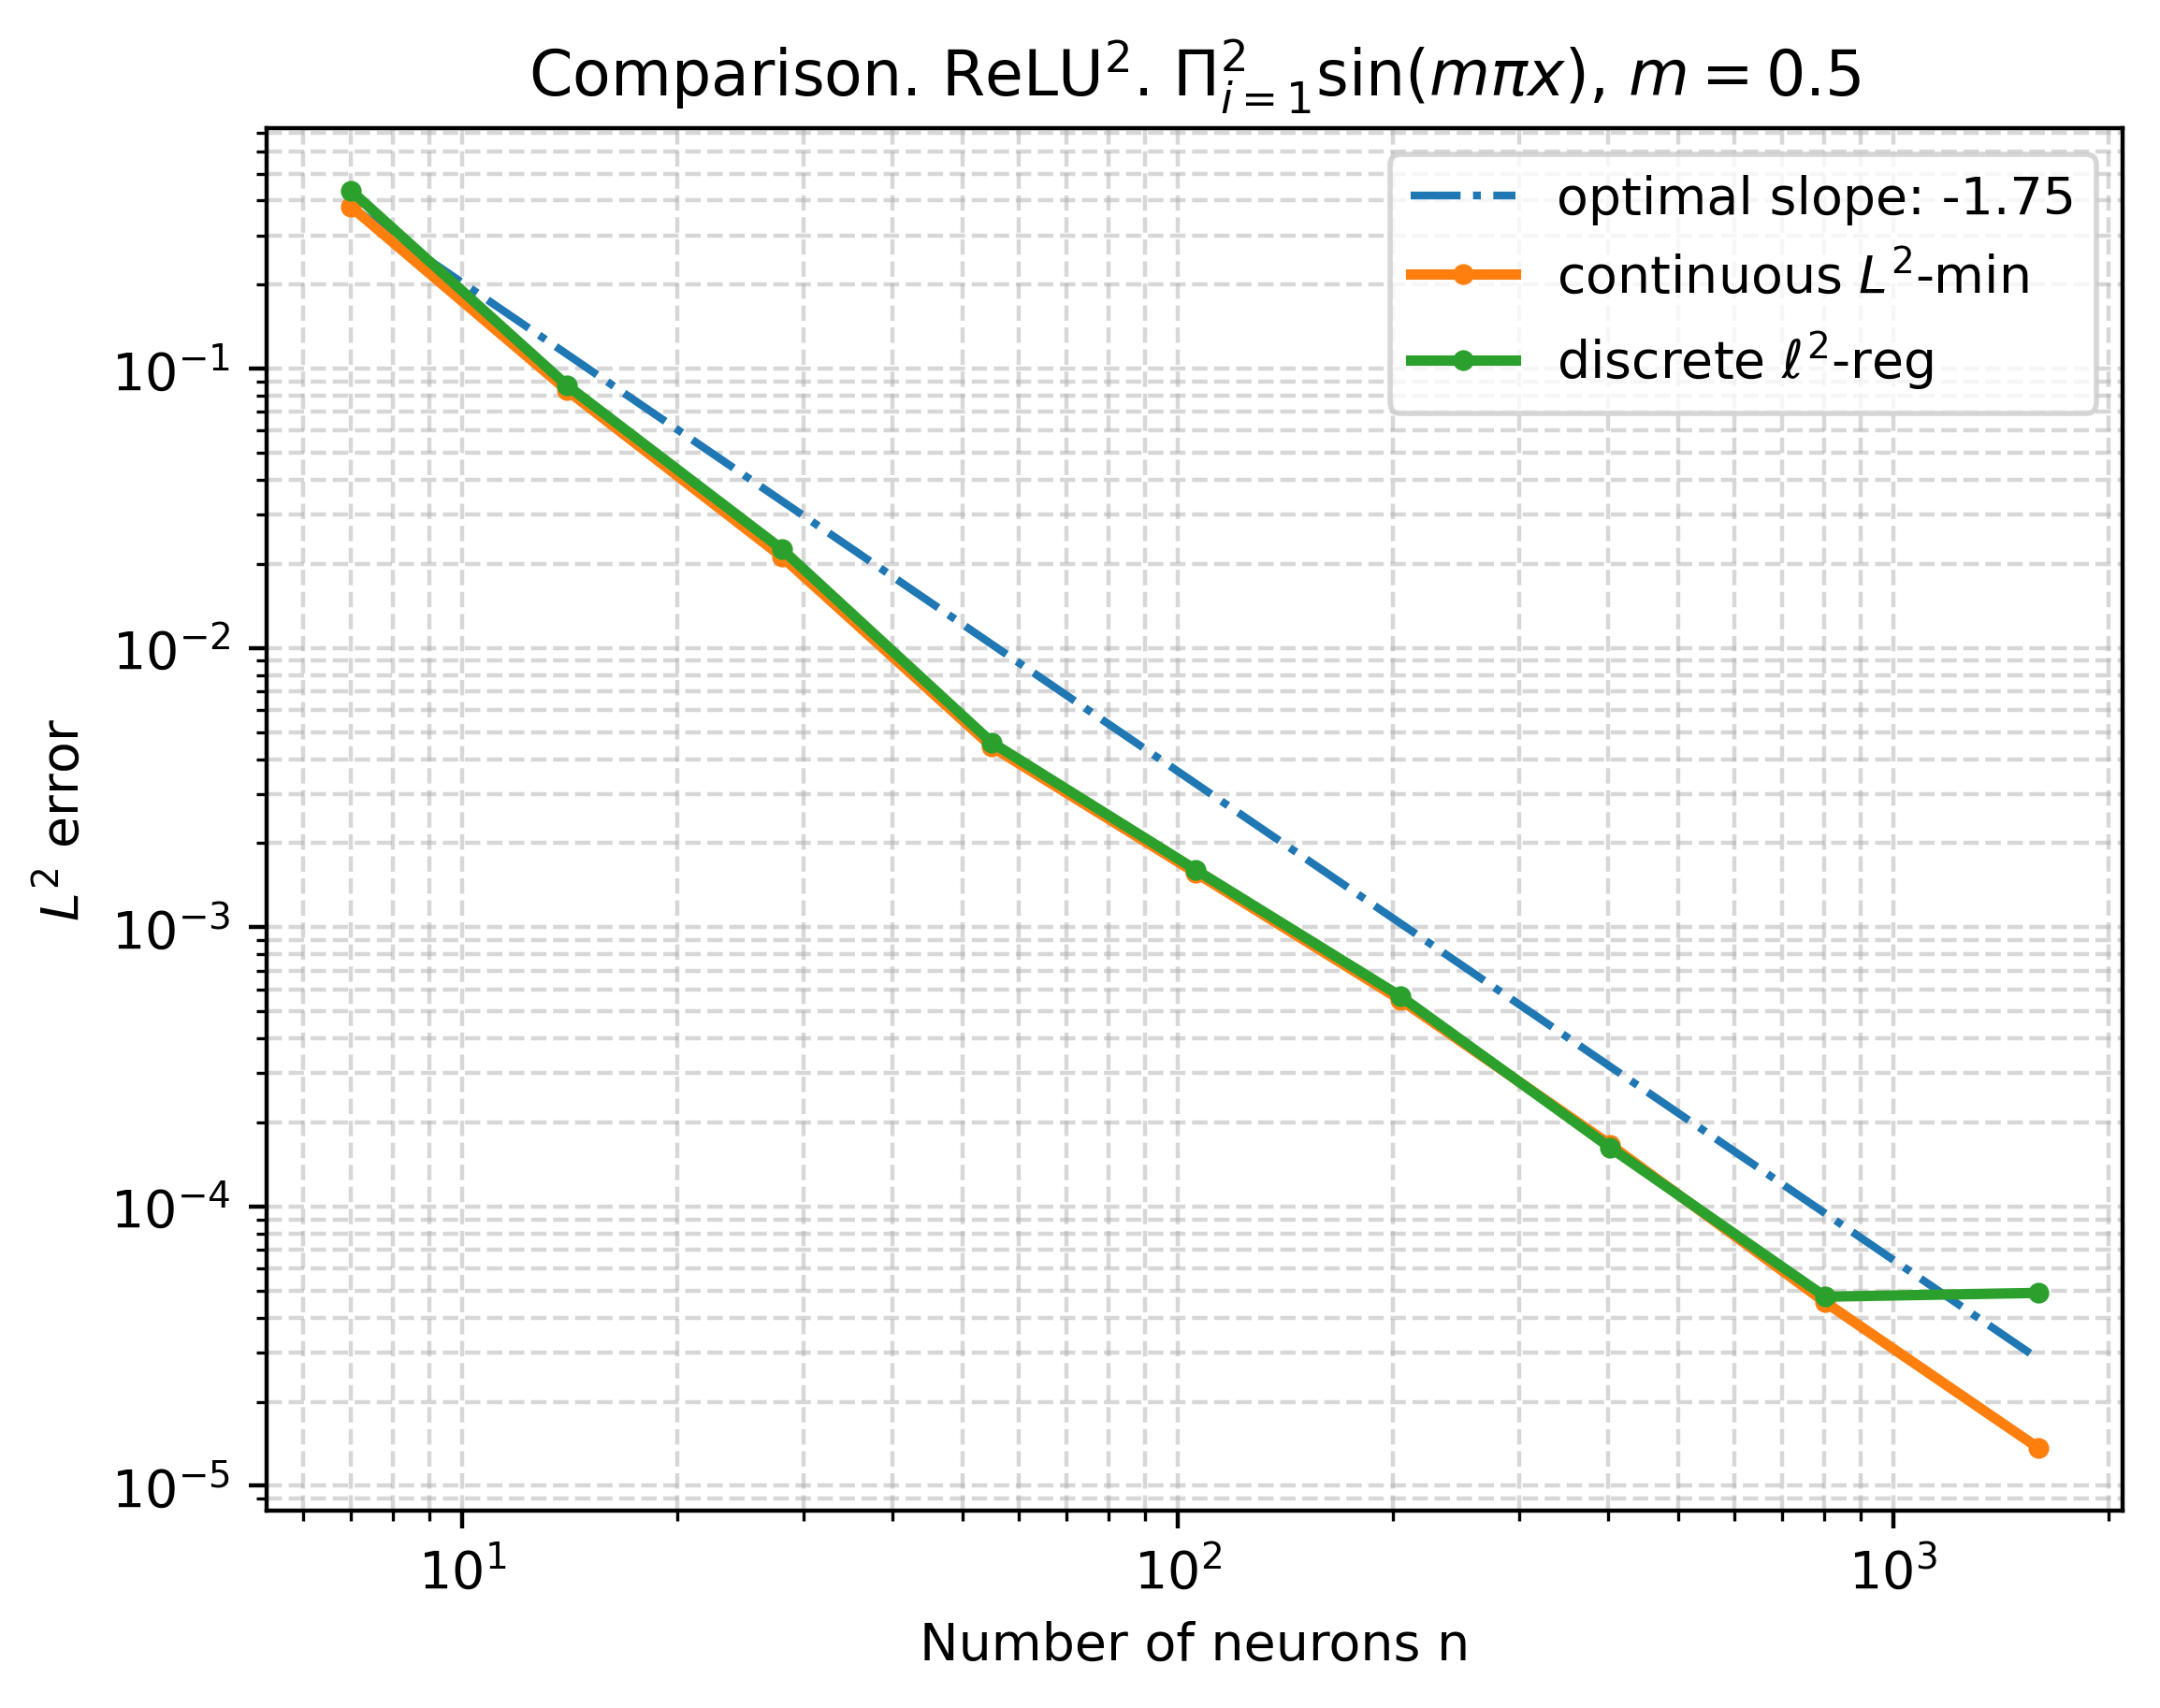

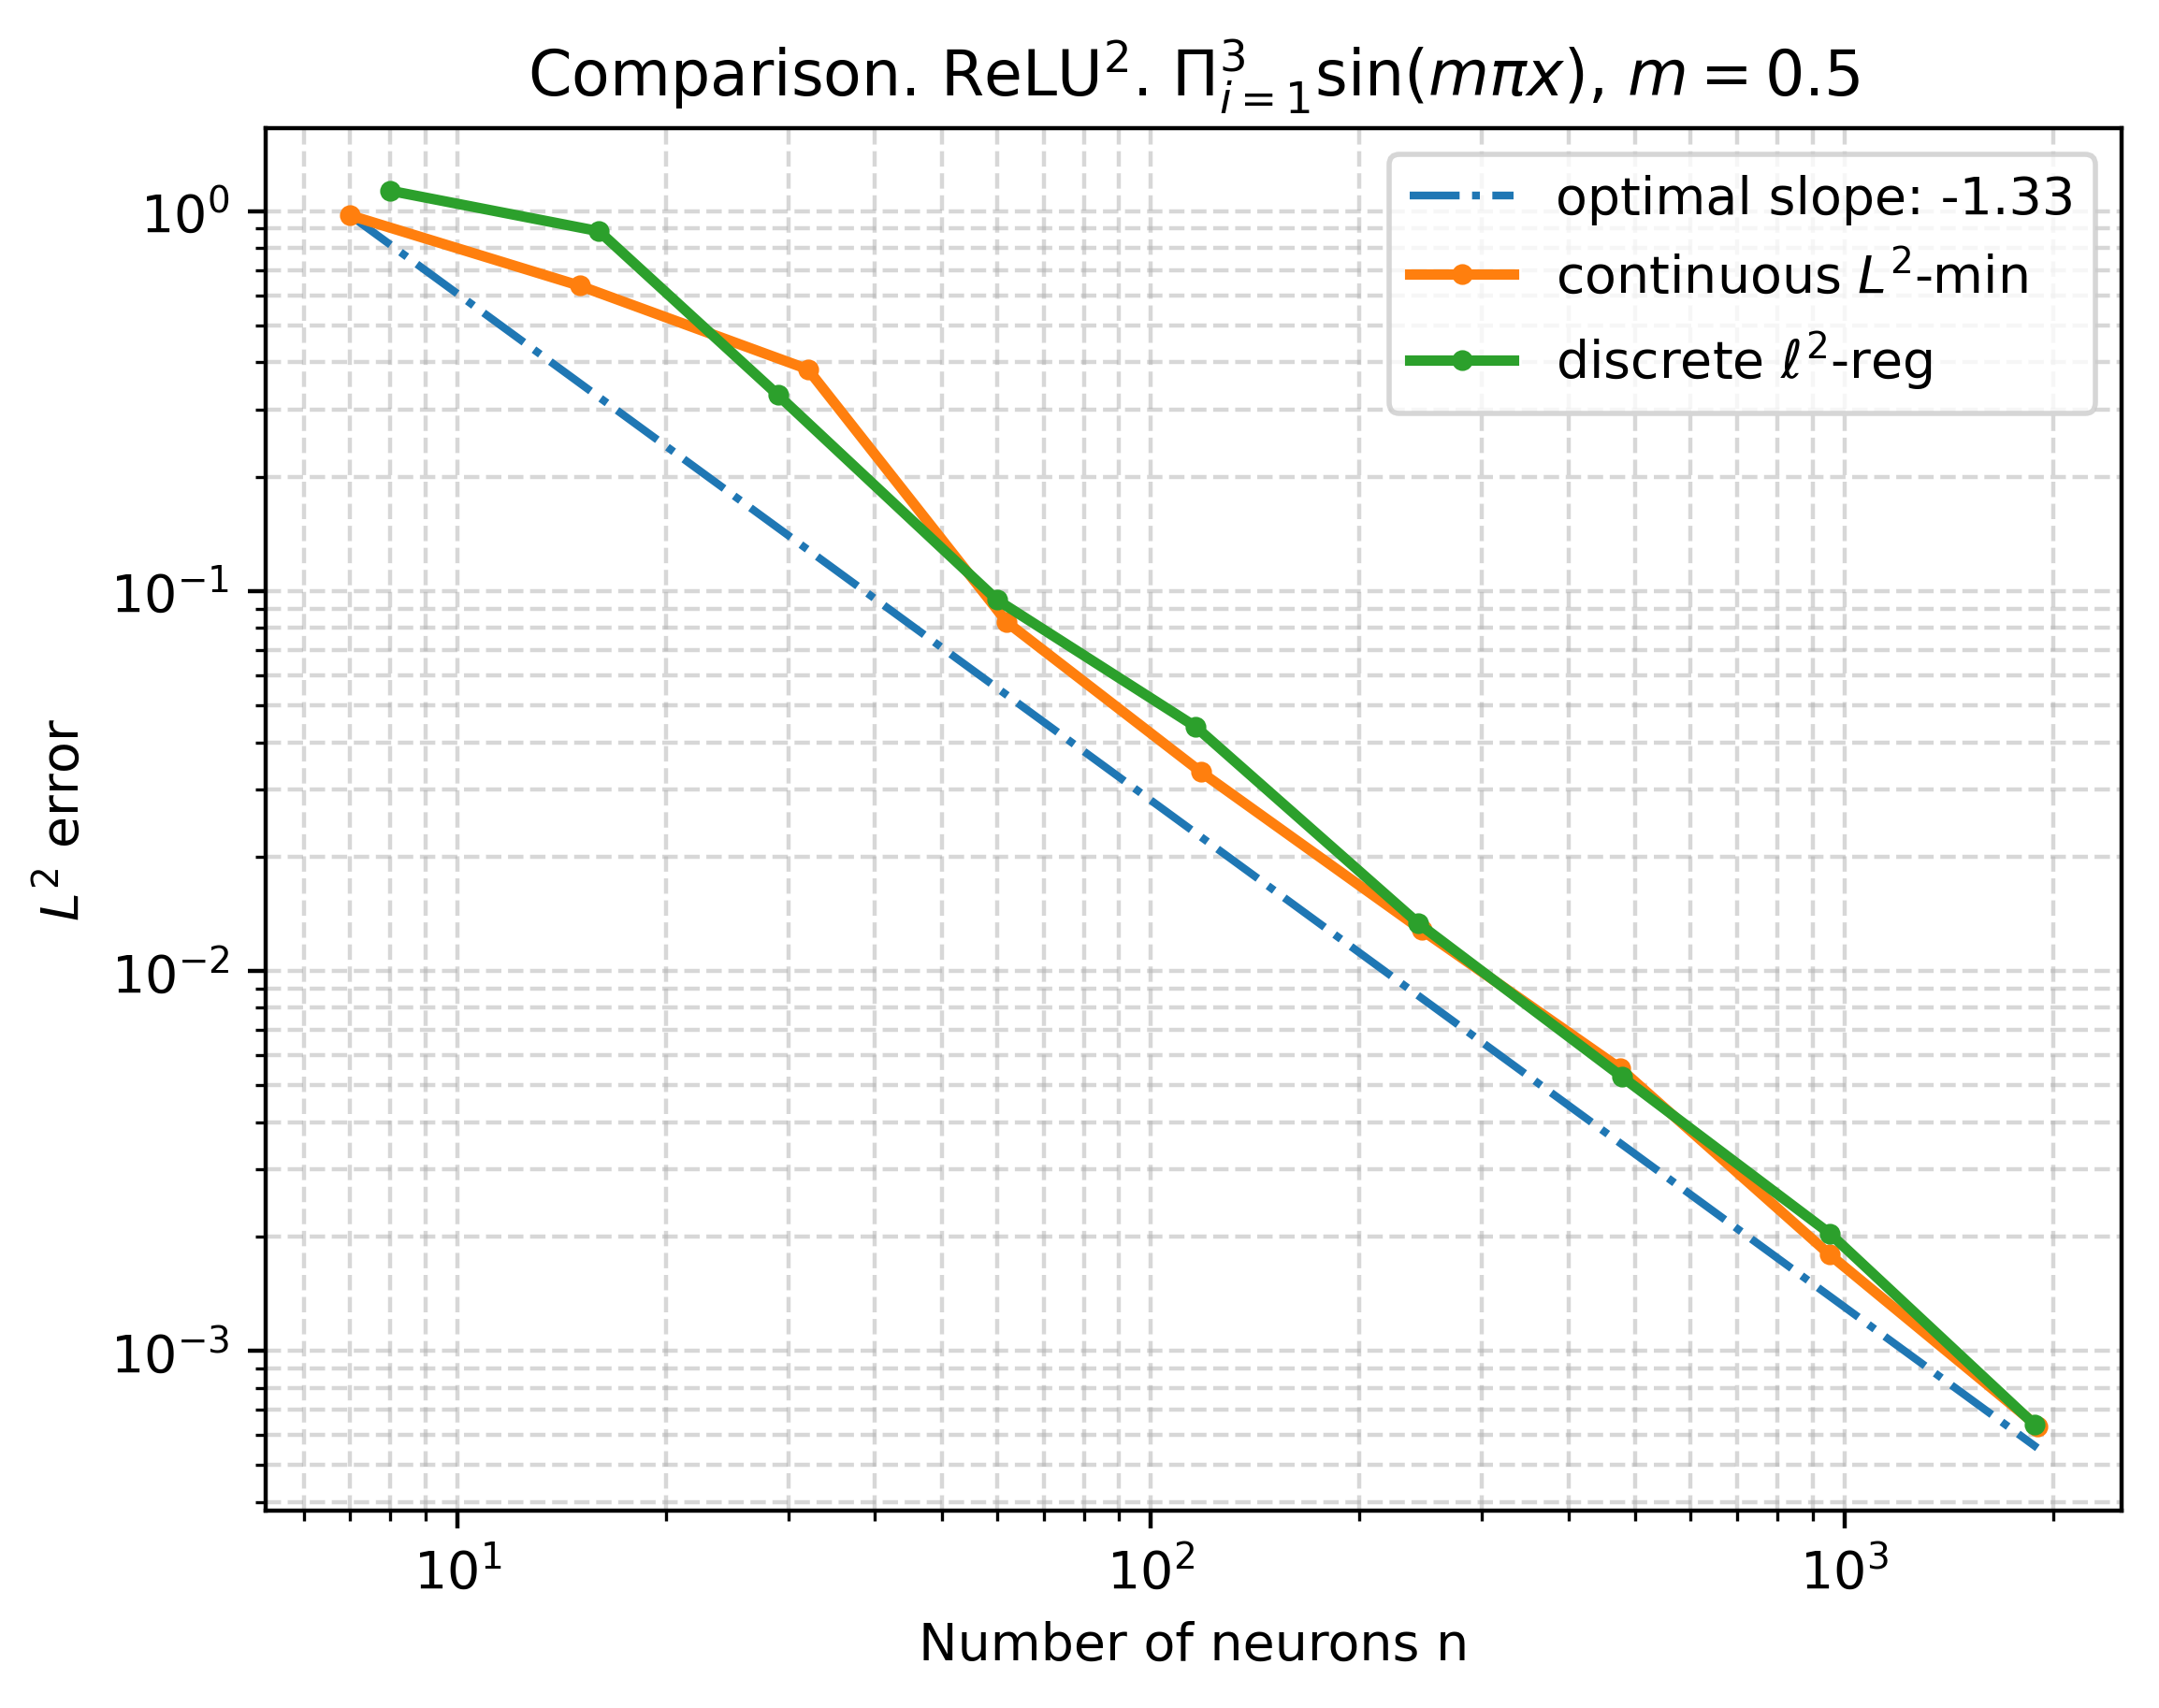

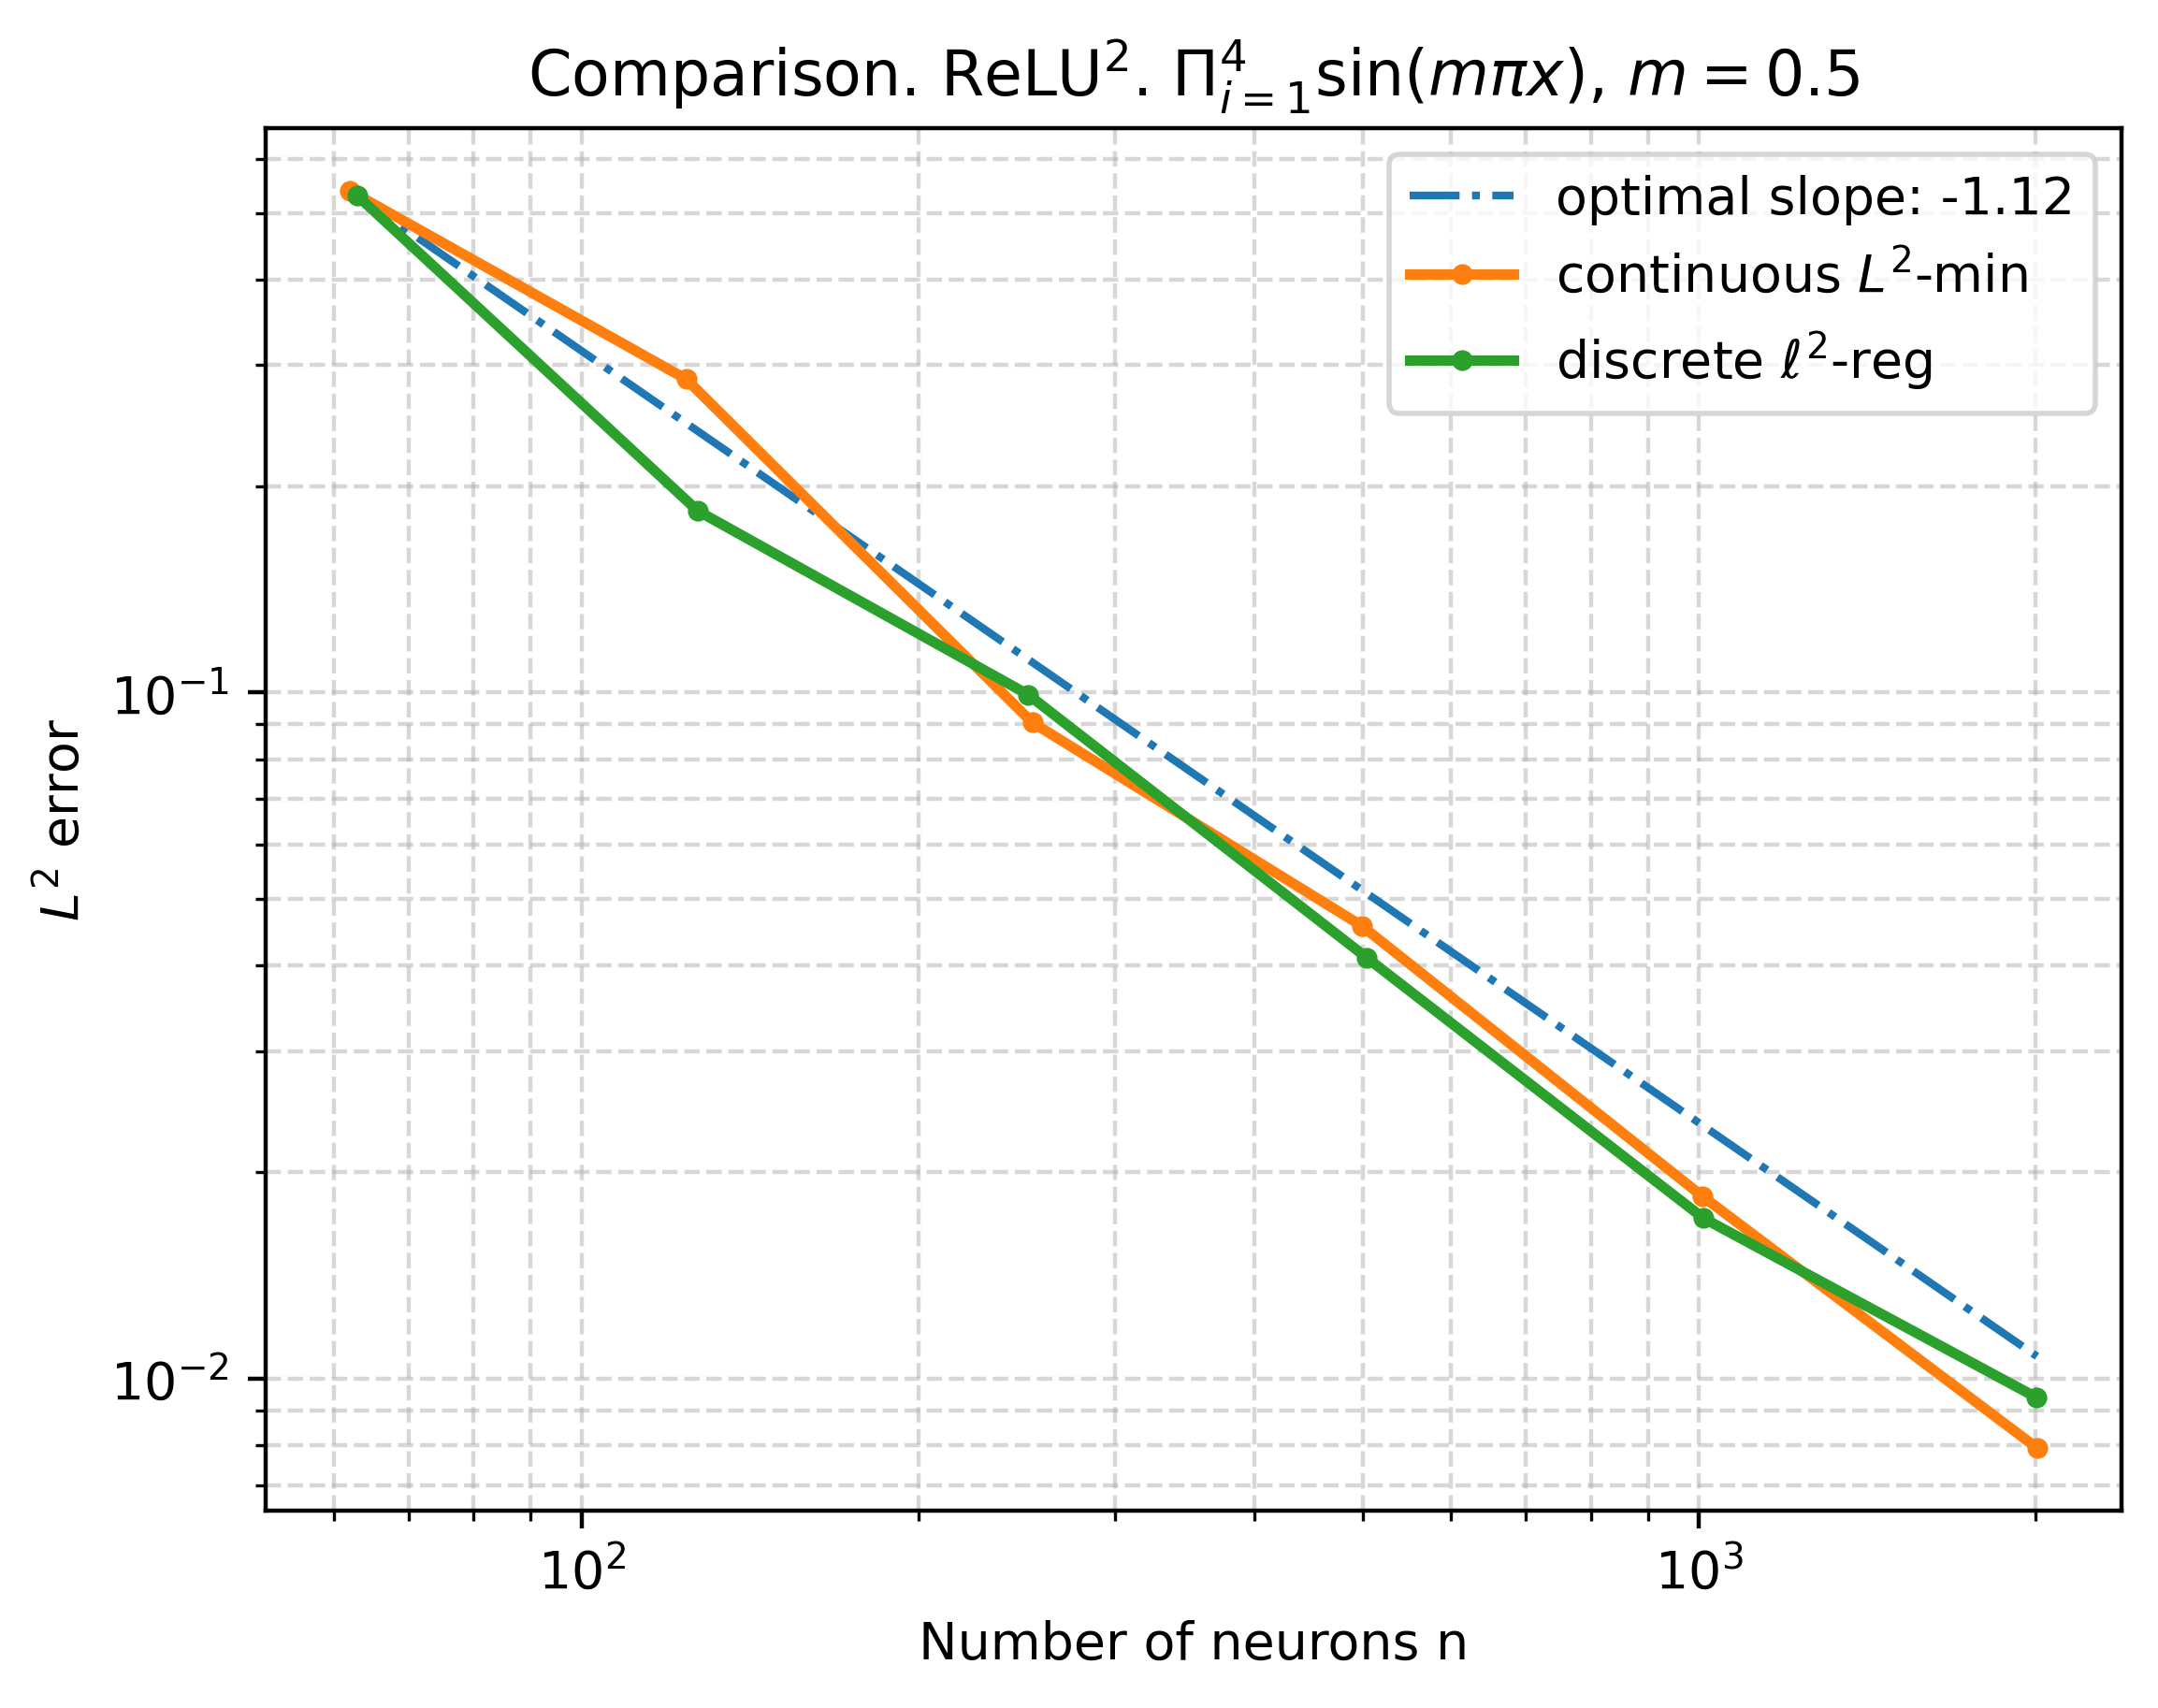

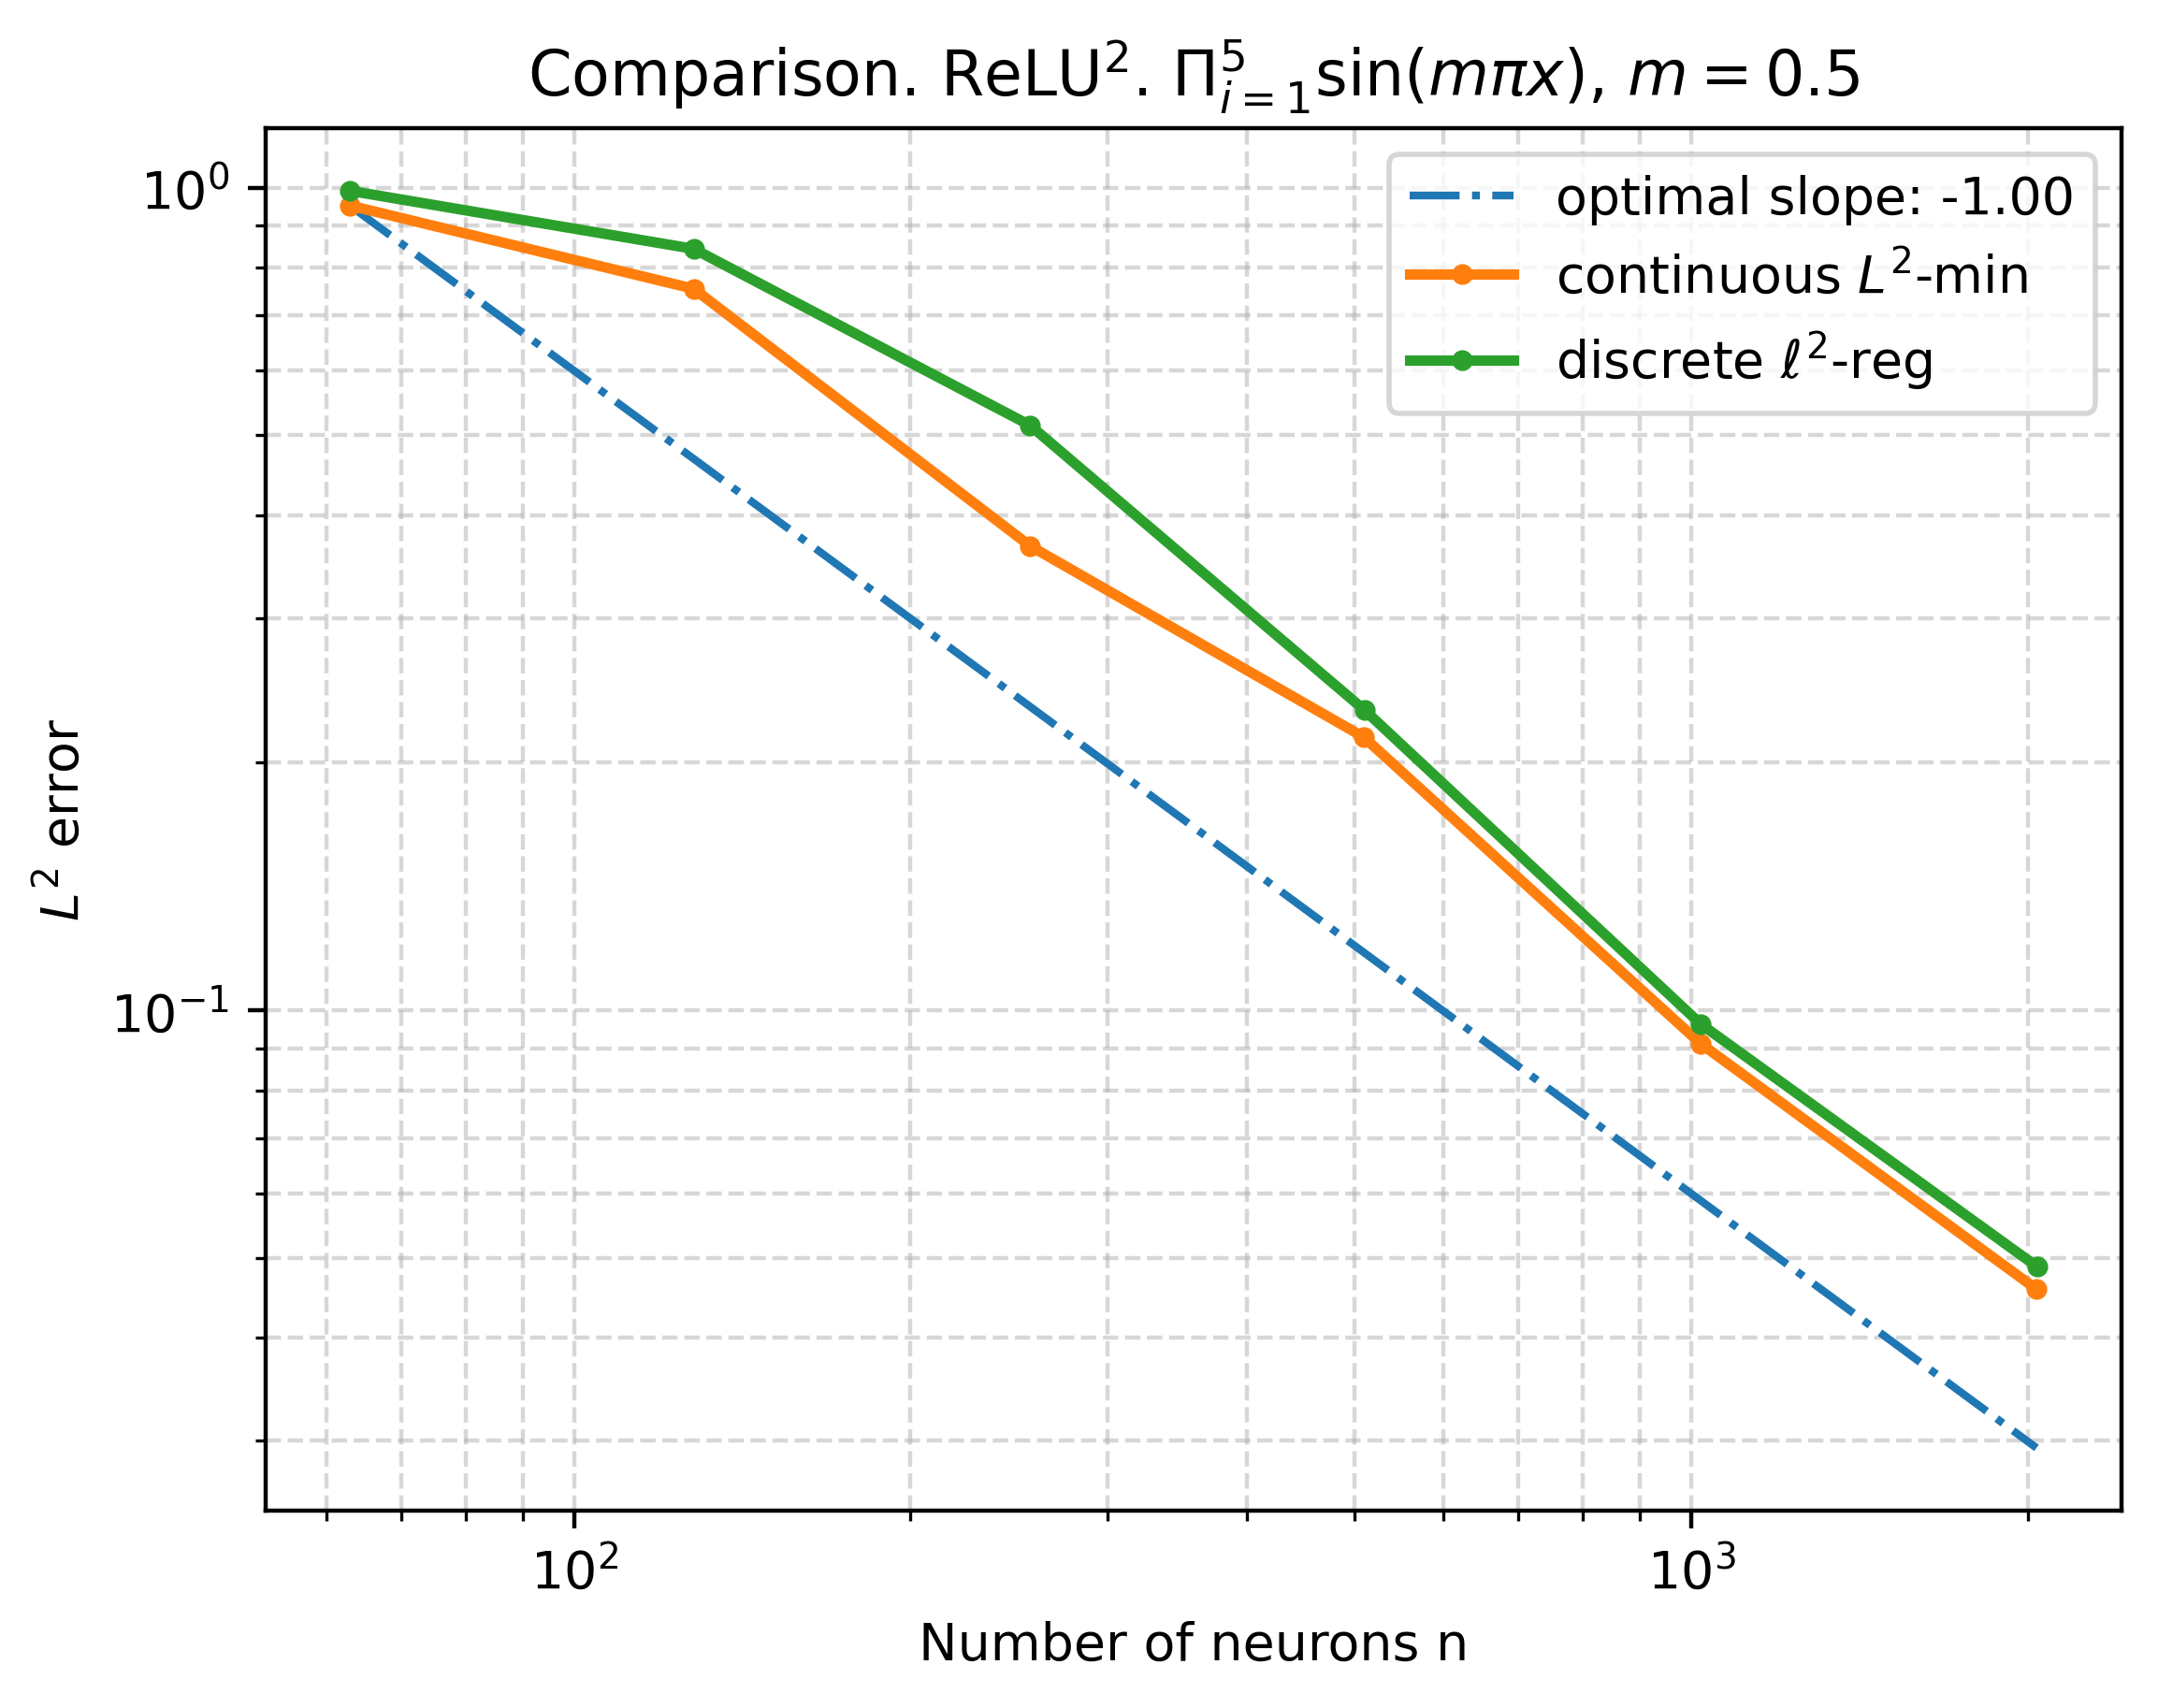

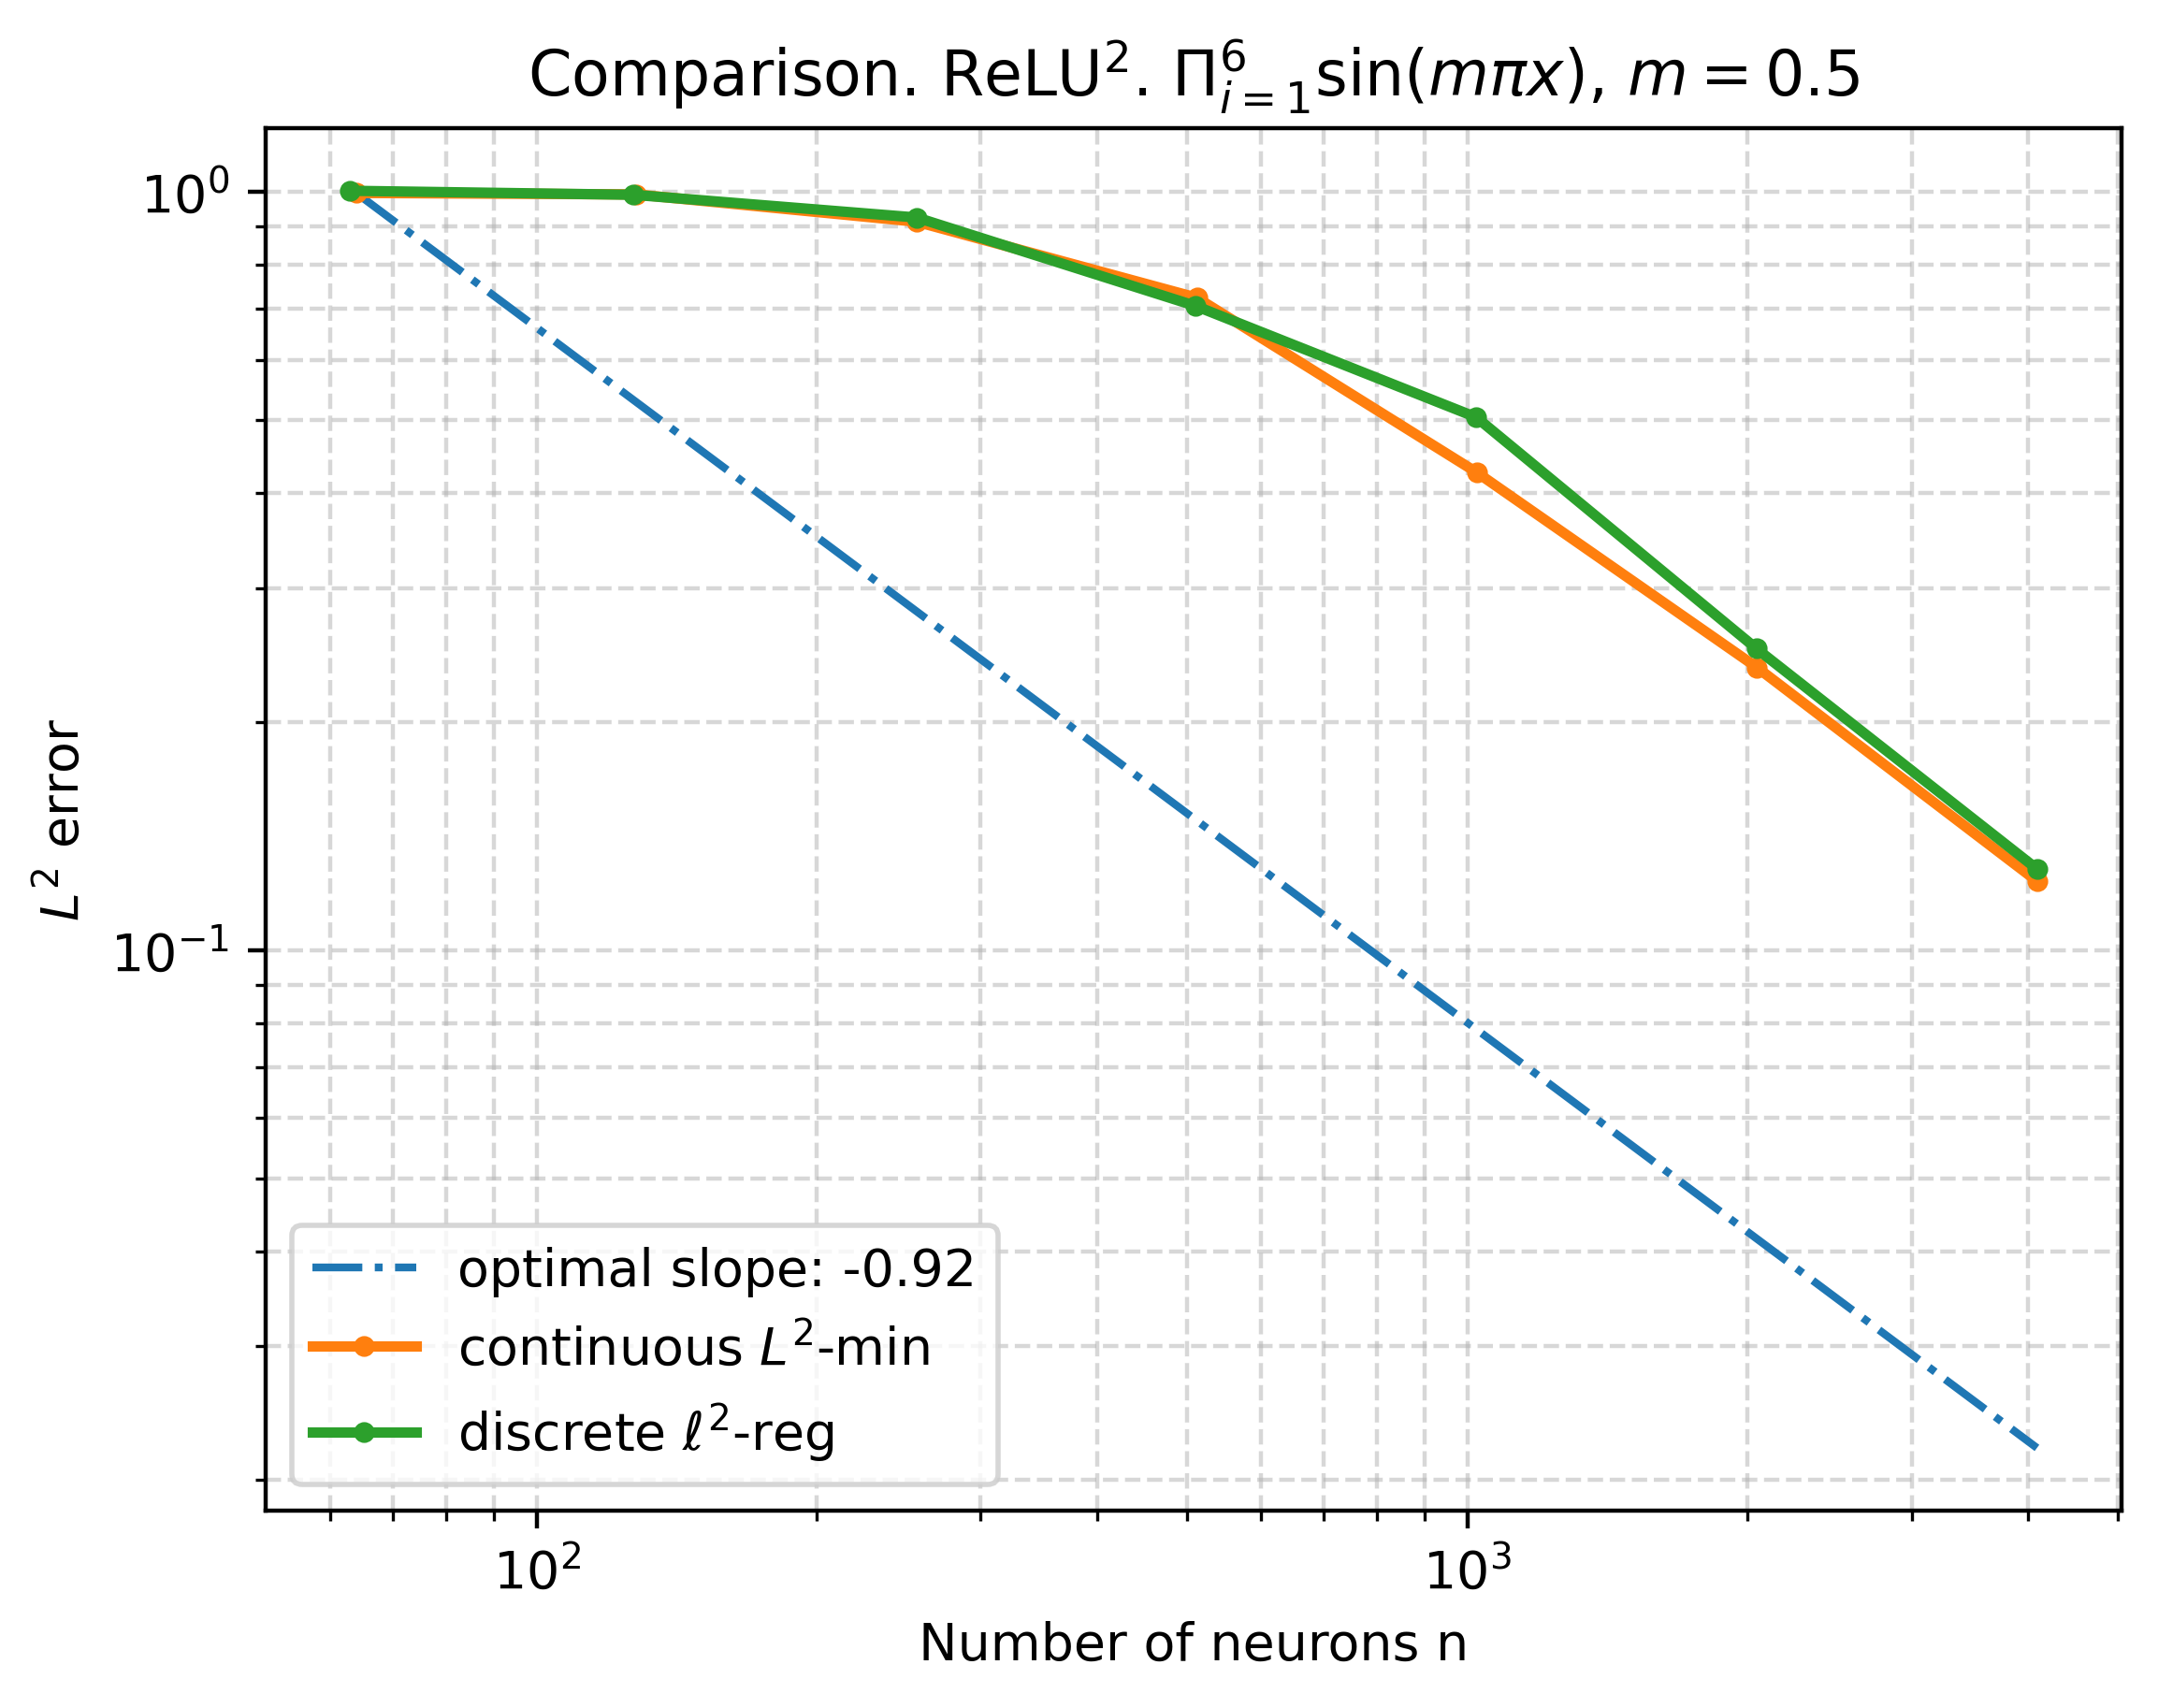

In [25]:
m = 1/2 
for d in range(1,7): 
    relu_k = 1 
    folder = './'
    data = np.load(f'{folder}L2minimization-{d}d-relu{relu_k}.npz')

    # access arrays by their keys
    actual_neuron_arr = data['actual_neuron_arr']
    mean_err_l2_arr_2 = data['mean_err_l2_arr_2']

    data = np.load(f'{folder}collocation-l2regression-{d}d-relu{relu_k}.npz')

    # access arrays by their keys
    actual_neuron_arr_co = data['actual_neuron_arr']
    mean_err_l2_arr_2_co = data['mean_err_l2_arr_2']

    if relu_k == 1:
        title =f"Comparison. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    else:
        title = f"Comparison. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    
    # plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
    optimal_rate = 1/2 + (2 * relu_k +1)/(2*d)
    ref = mean_err_l2_arr_2[0] *actual_neuron_arr[0]**optimal_rate * (actual_neuron_arr)**(-optimal_rate)
    plt.figure(dpi=400)
    plt.plot(actual_neuron_arr,ref,'-.',label = 'optimal slope: -{:.2f}'.format(optimal_rate))
    plt.plot(actual_neuron_arr, mean_err_l2_arr_2, '.-', label = 'continuous $L^2$-min', linewidth = 2)
    plt.plot(actual_neuron_arr_co, mean_err_l2_arr_2_co, '.-', label = 'discrete $\ell^2$-reg', linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show() 